In [48]:
import os
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("MPLBACKEND", "Agg")

import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import paper_lib as L

sys.path.insert(0, str(L.ROOT))  # so notebook cells can import from src/
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 240)
np.random.seed(42)
print("Project root:", L.ROOT)


Project root: C:\Users\ailab\Documents\code\financial-pilot-ea\paper_ieee_access


# When Does Feedback Help Retrieval-Augmented IT Support?

## A companion notebook: the complete evidence behind the paper

**What this notebook is.** This is the executed laboratory notebook behind the manuscript. Every
figure, every table, and every number in the paper appears here, in the same order, together with the
code that produced it and the reasoning that explains it. The notebook is deliberately written as a
scientific argument: each section states a question, explains the mechanism we expect *before*
looking at the data, shows the evidence, explains **why** the result comes out that way, checks
whether it could be an artefact, and closes with a one-line takeaway. No result is reported as "it
worked" or "it did not work" without a mechanism.

**Scope.** 1,595 anonymized enterprise IT support tickets; 878 train / 319 dev / 398 eval; five random
seeds; a procedure-disjoint regime. Two feedback protocols produced by an LLM judge: *conditioned*
(the judge sees the historical ground-truth reply) and *blind* (ticket-only). All generated runs are
anchored to one recorded generation regime (model + system prompt + response cache), and every number
in this notebook comes from an executed, warm-cache run.

---

## TL;DR — the paper in ten bullets

1. **The question.** Two tickets can look textually similar yet require different procedures. Feedback
   — promoting historical tickets that were judged useful — is the natural fix. When does it help?
2. **The design that separates the signal from the oracle.** The same retrieval is re-ranked twice:
   with a judge that sees the historical resolution (*conditioned*, an upper bound) and with a judge
   that does not (*blind*, deployable).
3. **The sign flips.** Conditioned fine-scope feedback improves generated replies on the held-out
   split (**+0.014** team, **+0.015** team∩class; BGE p ≤ .001); the same methods blind **harm**
   (−0.038). Broad scopes are negative under both.
4. **The failure is calibration, not the idea.** Judge scores are zero-inflated (59 % / 48 % exact
   zeros); a naive Laplace lift saturates at its negative cap (40–50 % of candidates) and overwhelms
   similarity.
5. **The fix is free.** Empirical-Bayes centering + pool-relative scaling removes the harm
   (offline blind −0.054 → +0.008…+0.015; generated +0.002, p=.86 — harm gone, residual gain not
   significant).
6. **The lift formula ordering is stable:** empirical Bayes > tanh > Laplace > Bayesian LCB, under both
   protocols.
7. **A gate is risk control, not gain.** Where harm is concentrated (uncalibrated blind) it recovers
   **0.54–0.56** of the oracle ceiling; once calibration removes the concentration it is neutral
   (−0.003) and under conditioned feedback it matches always-on (± 0.0005). Calibration and control are
   substitutes.
8. **Magnitude beats sign.** Expected-delta regression closes small, sharply harmful subsets and turns
   per-ticket action selection positive (**+0.0116**, 95 % CI [0.0034, 0.0205]) where the sign-only
   selector is negative (−0.0079).
9. **It replicates.** Independent metrics (BGE, BERTScore) and an independent LLM judge agree in
   direction; conditioned effects persist across seeds and unseen procedures, and a second generator
   (Gemini 3.8 Flash) reproduces and strengthens them (M4 +0.040).
10. **What we do not claim.** The deployable (blind) mean effect is null; feedback is LLM-judge
    simulated, the conditioned protocol is oracle-informed, the corpus is one organization, and the
    effects are small. All of that is documented in Section 26 and the FAQ.

---

## How to read this notebook

Every section has the same shape:

| Block | Meaning |
|---|---|
| **Why it matters / What you will see** | the question and the plan |
| **The idea** | the mechanism we expect *before* the data |
| *code* | the analysis that produces the evidence |
| **How to read it** | axes, units, sample size, reference lines |
| **What it shows** | the numbers and the claim |
| **Why this happens** | the causal explanation |
| **Could this be an artefact?** | controls, alternatives, robustness |
| **Takeaway** | one sentence |

Figures follow a message-first rule: their title is the conclusion, not the variable names. Sample
sizes, units, and splits are annotated on the figure.

## Metric glossary

| Symbol | Meaning |
|---|---|
| **Δcosine** | per-ticket difference `cos(generated reply, historical reply) − cos(baseline reply, historical reply)`, averaged. Baseline = no feedback, so its mean is 0 by definition. |
| **[BGE]** | the same difference measured with BAAI/bge-base-en-v1.5 — an embedding family independent of the retriever (all-MiniLM). |
| **p** | paired Wilcoxon signed-rank test over tickets. |
| **CI** | 95 % bootstrap interval; for pooled dev statistics, tickets are resampled (clustered), not rows. |
| **Recovery** | `(policy − always-on) / (oracle − always-on)`: the fraction of the attainable ceiling a policy captures. 0 = always-on, 1 = oracle. |
| **AUC** | probability that a helped ticket receives a higher predicted score than a non-helped one; 0.5 = chance. |
| **PPV** | precision: among tickets the policy opens, the fraction that actually helped. |
| **Net win** | pairwise judge: `(feedback wins − baseline wins) / decided pairs`, consistent across both presentation orders. |
| **Context sensitivity** | `1 − cos(baseline answer, feedback answer)`: how much the generator's output changes when retrieval changes. |
| **MDE** | minimum detectable effect at 80 % power (paired): `2.80 · σ / √n`. Tells us which effects the study could ever confirm. |

## Notebook map (paper section → here)

| Paper | Here | Content |
|---|---|---|
| 1 Introduction | S1 | problem, running example, contributions |
| 2 Related work | — | pointers only (no bibliography in the notebook, by design) |
| 3 Data & protocols | S2–S4 | corpus, splits, protocols, judge reliability, generation regime |
| 4 Method | S5, S14 | metrics, statistics, lift/routing/gate/magnitude construction |
| 5 Analysis I | S6–S10 | protocol reversal, scope, retrievers, formulas, evidence |
| 6 Analysis II | S11–S13 | zero-inflation, saturation, the fix, negative results |
| 7 Control | S15–S19 | gate, decomposition, substitution, magnitude, live runs |
| 8 Results & validation | S20–S24 | eval, independent metrics, judge, seeds/disjoint, cross-generator |
| 9 Discussion | S25 | practical recipe |
| 10 Limitations | S26–S27 | what we do not claim + reviewer FAQ |
| Appendix | A–C | worked examples, additional analyses, all runs, provenance |

## Claim ledger — every paper claim and where it is proven

In [49]:
import pandas as pd
claims = pd.DataFrame([
    ("C1  Protocol reversal (conditioned helps, blind harms)", "S6", "generated eval + BGE", "proven"),
    ("C2  Fine scopes help; broad pooling harms", "S7", "generated dev + six-retriever ladder ordering", "proven"),
    ("C3  Judge scores are zero-inflated and naive lift saturates", "S11", "judge distributions, cap saturation", "proven"),
    ("C4  EB centering + pool-relative scaling removes the harm", "S12", "offline rescue + generated", "proven (harm removal; gain n.s.)"),
    ("C5  Lift-formula ordering: EB > tanh > Laplace > LCB", "S9", "ablation under both protocols", "proven"),
    ("C6  A gate recovers harm only where harm is concentrated", "S16", "gate policy + decomposition", "proven"),
    ("C7  Calibration and control are substitutes", "S17", "recovery vs prior state", "proven"),
    ("C8  Magnitude modelling beats sign; action selection positive", "S18", "regressor + action selection", "proven"),
    ("C9  Independent metrics and an independent judge agree in direction", "S20–S21", "BGE/BERTScore + Claude judge", "proven"),
    ("C10 The calibrated blind gain does not transfer to stronger retrievers", "S8", "hybrid/CE generated runs", "proven (lift-config confound noted)"),
    ("C11 Conditioned effects persist across seeds and unseen procedures", "S22", "seeds 123/456 + disjoint", "proven (smaller; team seed456 ~0)"),
    ("C12 Cross-generator replication (Gemini 3.8 Flash)", "S23", "second generator family", "proven (stronger)"),
    ("N1  Semantic filter is worse than base routings", "S13", "offline, all retrievers", "negative result"),
    ("N2  Learned blend collapses to one scope", "S13", "bootstrap weights", "negative result"),
    ("N3  Sign-only multi-action selection loses", "S18", "action selection", "negative result"),
], columns=["claim", "section", "evidence", "status"])
display(claims)

,claim,section,evidence,status
0,"C1 Protocol reversal (conditioned helps, blind harms)",S6,generated eval + BGE,proven
1,C2 Fine scopes help; broad pooling harms,S7,generated dev + six-retriever ladder ordering,proven
2,C3 Judge scores are zero-inflated and naive lift saturates,S11,"judge distributions, cap saturation",proven
3,C4 EB centering + pool-relative scaling removes the harm,S12,offline rescue + generated,proven (harm removal; gain n.s.)
4,C5 Lift-formula ordering: EB > tanh > Laplace > LCB,S9,ablation under both protocols,proven
5,C6 A gate recovers harm only where harm is concentrated,S16,gate policy + decomposition,proven
6,C7 Calibration and control are substitutes,S17,recovery vs prior state,proven
7,C8 Magnitude modelling beats sign; action selection positive,S18,regressor + action selection,proven
8,C9 Independent metrics and an independent judge agree in direction,S20–S21,BGE/BERTScore + Claude judge,proven
9,C10 The calibrated blind gain does not transfer to stronger retrievers,S8,hybrid/CE generated runs,proven (lift-config confound noted)


## Reproducibility at a glance

In [50]:
resc = L.load_rescore_comparison()
status = L.artifact_status()
n_ok = int(status["available"].sum())
print(f"Frozen generated runs with independent metrics: {len(resc)}")
print(f"  dev runs:   {int(resc['run'].str.contains('_dev_').sum())}")
print(f"  eval runs:  {int(resc['run'].str.contains('_eval_').sum())}")
print(f"  generated by a second model family: {int(resc['run'].str.contains('gengemini38flash').sum())}")
print(f"Artifact checks available: {n_ok} / {len(status)}")
display(status[["section", "available"]].set_index("section").T)

Frozen generated runs with independent metrics: 39
  dev runs:   25
  eval runs:  14
  generated by a second model family: 3
Artifact checks available: 10 / 13


section,Validity: proxy,Validity: calibration,Validity: rescoring,Granularity: ladder,Granularity: blind ladder,Granularity: blend,Granularity: blind blend,Gate pilot: blind,Volume,Held-out ladder,Disjoint ladder,Gate,Pairwise judge
available,True,True,True,True,True,True,True,True,True,False,False,False,True


# Part I — Foundations

This part establishes the problem, the data, the two feedback protocols, the generation-regime
discipline, and the metric/statistical protocol. Everything later in the notebook rests on these
definitions, so each choice is justified rather than assumed.

---

## S1. Why would a retrieval system need feedback?

**Why it matters.** RAG retrieves the textually most similar historical tickets, but textual similarity is not procedural correctness. If this gap exists, some baseline answers must follow the wrong procedure even while looking relevant.

**What you will see.** A real ticket where the baseline retrieval finds a similar but procedurally wrong historical reply, and feedback finds the right one.

**The idea.** Two tickets can share almost all of their vocabulary and still require different
resolutions. "I cannot connect to client software" retrieves historical tickets about *network and
VPN access* because they share the words "connect" and "client"; the correct resolution, however,
may be a request form for *locally installed software*. A retrieval system optimising cosine
similarity has no way to prefer the procedurally correct neighbour. Feedback is the natural fix:
promote candidates whose historical replies were judged useful, even if they are less similar. Before
building anything, we show that this failure mode is real, not hypothetical.

In [51]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_records(folder):
    """Newest details JSON of a run, keyed by ticket id."""
    return {r["ticket_id"]: r for r in L.load_details(folder)}


def trunc(text, n=170):
    text = " ".join(str(text).split())
    return text if len(text) <= n else text[:n] + " …"


def show_case(folder, ticket_id, top=3, chars=170):
    """Print a compact baseline-vs-feedback comparison for one ticket."""
    record = load_records(folder)[ticket_id]
    rows = []
    for side, label in (("baseline", "baseline (no feedback)"), ("feedback", "feedback")):
        for c in record[side]["retrieval"][:top]:
            rows.append({
                "side": label,
                "rank": int(c.get("feedback_rank", c.get("faiss_rank", 0))),
                "candidate": c["seq_id"],
                "similarity": round(float(c.get("faiss_score", 0.0)), 3),
                "lift": round(float(c.get("feedback_lift", 0.0)), 3),
                "reply (truncated)": trunc(c.get("reply", ""), chars),
            })
    display(pd.DataFrame(rows))
    print("QUERY TITLE   :", trunc(record["query_title"], 200))
    print("REFERENCE     :", trunc(record["reference_reply"], 260))
    print("BASELINE ANS  :", trunc(record["baseline"]["answer"], 260))
    print("FEEDBACK ANS  :", trunc(record["feedback"]["answer"], 260))
    print(f"DELTA COSINE  : {record['deltas']['delta_cosine']:+.3f}")
    return record


RUN_M4_COND_EVAL = "M4_intersection_eval_conditioned_continuous"
show_case(RUN_M4_COND_EVAL, "R-377");

,side,rank,candidate,similarity,lift,reply (truncated)
0,baseline (no feedback),1,R-1372,0.606,0.0,Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to report a proble...
1,baseline (no feedback),2,R-90,0.570,0.0,Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to enable Client-t...
2,baseline (no feedback),3,R-319,0.550,0.0,Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to enable Client-t...
3,feedback,1,R-5,0.442,0.2,Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to support you abo...
4,feedback,2,R-113,0.436,0.2,Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to support you abo...
5,feedback,3,R-1016,0.426,0.2,Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to support you abo...


QUERY TITLE   : Connect to Client SW
REFERENCE     : Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to support you about local software / programs - Important information:: This one is to provide support to installed progr …
BASELINE ANS  : Good morning, This request must be submitted through the **Client-to-Site VPN tunnel/access request form** for the required network permissions. Please provide the following information: - Project name - Customer/site or destination - Destination IP address an …
FEEDBACK ANS  : Good morning, Please submit this request using the following category: **Need:** Extra information needed to support you about local software/programs This category is intended for support with installed local programs. If you require software installation or  …
DELTA COSINE  : +0.540


**How to read it.** Three retrieved candidates per side, with the retrieval similarity and (for feedback) the
applied lift. The last lines are the reference (what the support team actually wrote), the baseline
answer, and the feedback answer, each truncated. `DELTA COSINE` is how much closer the feedback
answer is to the reference.

**What it shows.** The query asks for a connection to client software. The baseline top-1 is a
*network-access* candidate (`R-1372`, "Cannot access client intranet destination") that shares the
words "client" and "access", and the baseline answer accordingly routes the user to a VPN/access
form. The reference, however, is a *local software support* form. Feedback promotes `R-5`, whose
reply is exactly that form, and the feedback answer follows it. The delta is +0.540 for this ticket —
one of the largest on the split — and the mechanism is exactly the one we hypothesised.

**Why this happens.** Dense retrieval optimises semantic proximity, which conflates two different notions:
"about the same words" and "resolved the same way". The conditioned judge has access to the
historical resolution; it can therefore rate `R-5` as procedurally equivalent to the reference even
though its text is less similar to the query. The baseline has no such signal.

**Could this be an artefact?** One example is an anecdote, not evidence. Section S6 measures the effect over all
398 eval tickets with confidence intervals, and Section S13 shows that the failure mode is systematic
(the semantic filter, which tries to fix it heuristically, fails on every retriever). The example's
role is to make the later numbers concrete.

**Takeaway.** Textual similarity and procedural correctness genuinely diverge; feedback can supply the
missing procedural signal in the easiest case — when the judge knows the resolution.

---

## S2. What does the corpus look like?

**Why it matters.** Every later result — scope starvation, class imbalance, near-duplicate procedures — is a property of the data. We quantify those properties first so the modelling choices are interpretable.

**What you will see.** Corpus composition by team and intent class, split sizes, and repetition statistics.

**The idea.** An IT service desk corpus is not a balanced benchmark. A few teams handle most tickets,
the long tail is large, and many tickets are near-duplicates of each other because procedures are
templated. Both facts matter: imbalance creates the scope-level calibration problem (S11), and
near-duplication determines what the procedure-disjoint split (S22) has to control for.

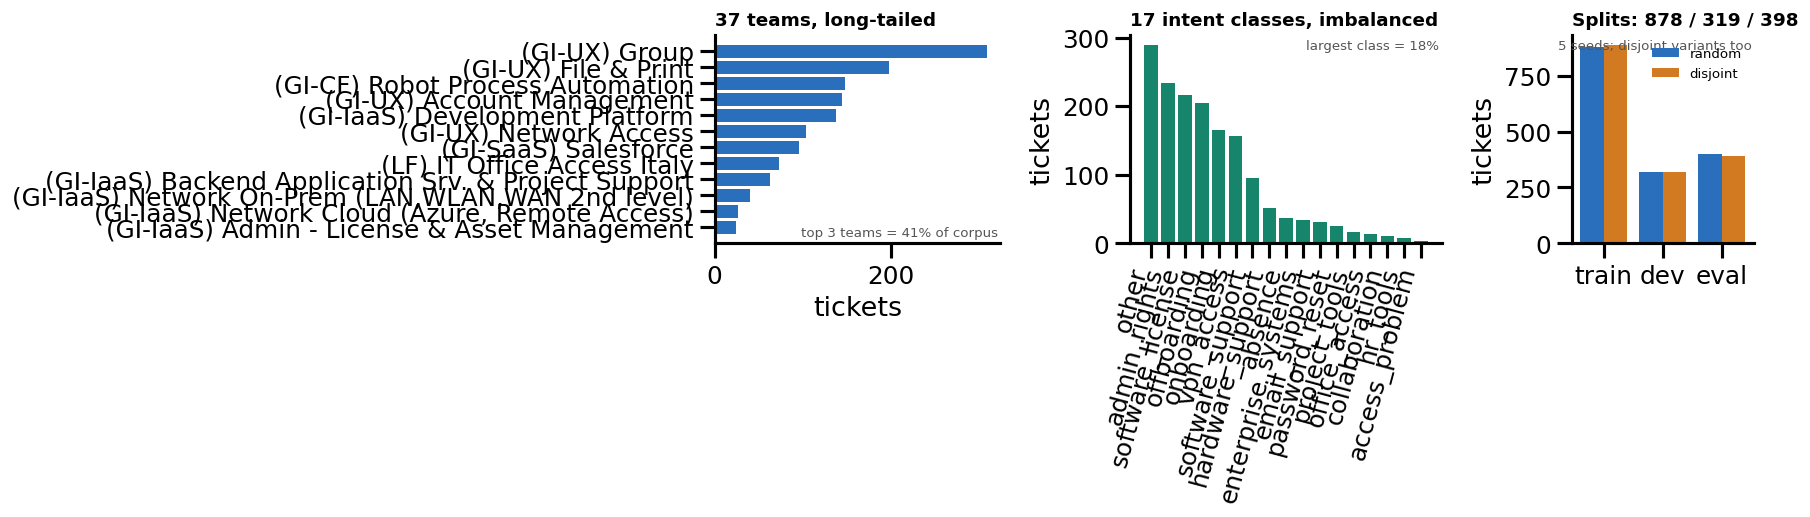

Tickets: 1595   Teams: 37   Classes: 17
Random splits:    {'train': 878, 'dev': 319, 'eval': 398}
Disjoint splits:  {'train': 886, 'dev': 319, 'eval': 390}


In [52]:
ds = L.load_dataset()
split = L.load_splits(42)
split_disjoint = L.load_splits(42, regime="disjoint")
sizes = {k: len(v) for k, v in split.items() if isinstance(v, list)}
sizes_disjoint = {k: len(v) for k, v in split_disjoint.items() if isinstance(v, list)}

teams = ds["Team->Name"].value_counts()
classes = ds["intent_class"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.1, 1.2, 0.7]})
top = teams.head(12)[::-1]
axes[0].barh(top.index, top.values, color=L.ACCENT_COLOR)
axes[0].set_xlabel("tickets")
L.takeaway(axes[0], f"{len(teams)} teams, long-tailed")
L.note(axes[0], f"top 3 teams = {top.values[-3:].sum() / len(ds):.0%} of corpus", loc="lower right")

axes[1].bar(classes.index, classes.values, color=L.COND_COLOR)
axes[1].tick_params(axis="x", rotation=75)
for tick in axes[1].get_xticklabels():
    tick.set_ha("right")
axes[1].set_ylabel("tickets")
L.takeaway(axes[1], f"{len(classes)} intent classes, imbalanced")
L.note(axes[1], f"largest class = {classes.iloc[0] / len(ds):.0%}", loc="upper right")

labels = ["train", "dev", "eval"]
x = np.arange(len(labels))
axes[2].bar(x - 0.2, [sizes[k] for k in labels], width=0.4, color=L.ACCENT_COLOR, label="random")
axes[2].bar(x + 0.2, [sizes_disjoint.get(k, 0) for k in labels], width=0.4,
            color=L.WARN_COLOR, label="disjoint")
axes[2].set_xticks(x, labels)
axes[2].set_ylabel("tickets")
axes[2].legend(fontsize=8, frameon=False)
L.takeaway(axes[2], "Splits: 878 / 319 / 398")
L.note(axes[2], "5 seeds; disjoint variants too", loc="upper right")
plt.tight_layout()
L.savefig("companion_02_corpus", run_ids=[])
plt.show()

print(f"Tickets: {len(ds)}   Teams: {ds['Team->Name'].nunique()}   Classes: {ds['intent_class'].nunique()}")
print(f"Random splits:    {sizes}")
print(f"Disjoint splits:  {sizes_disjoint}")

In [53]:
groups = json.loads((L.DATA / "procedure_groups.json").read_text(encoding="utf-8"))
pd.set_option("display.max_colwidth", 120)
display(pd.Series(groups, name="value").to_string())

ladder = L.load_ladder_curve()
base_hit = float(ladder.loc[ladder["retriever"] == "dense_minilm", "base_minilm_same_reply_hit1"].iloc[0])
print(f"\nBaseline top-1 is the EXACT historical reply for only {base_hit:.1%} of dev tickets "
      f"(the missing procedural signal that feedback has to supply).")

'total_tickets                      1595\nreply_hash_unique                   761\nreply_hash_multi                     88\nreply_hash_multi_tickets            922\nreply_hash_largest                  118\ntitle_subcat_hash_unique           1403\ntitle_subcat_hash_multi              72\ntitle_subcat_hash_multi_tickets     264\ntitle_subcat_hash_largest            15\ncombined_hash_unique               1498\ncombined_hash_multi                  50\ncombined_hash_multi_tickets         147'


Baseline top-1 is the EXACT historical reply for only 30.7% of dev tickets (the missing procedural signal that feedback has to supply).


**How to read it.** Left: tickets per resolving team (top 12). Middle: tickets per intent class. Right:
split sizes for the random and disjoint regimes. The second cell lists the near-duplicate statistics
computed from reply/title/subcategory hashes.

**What it shows.** The corpus has 1,595 tickets across 37 teams and 17 intent classes; the top three
teams hold about a third of the tickets and the class distribution is similarly skewed. Many tickets
share replies and procedures: identical replies appear for multiple tickets, and 264 tickets share a
(title, subcategory) group. Most importantly, the baseline top-1 candidate has the *exact* historical
reply for only about 31 % of dev tickets — the remaining 69 % require some procedural inference or,
when the retrieval is wrong, expose exactly the failure mode from S1.

**Why this happens.** Templated resolutions (form redirects, onboarding/offboarding boilerplate) make replies
repetitive; ticket volume is concentrated in a few services. Both are typical of enterprise service
desks, which is why we report them rather than smoothing them away.

**Could this be an artefact?** Near-duplicates could make the evaluation optimistic: if the same procedure appears
in train and eval, feedback could simply memorise it. This is why the procedure-disjoint regime
exists (S22): identical procedures never cross the split boundary, and the conditioned effect still
holds there.

**Takeaway.** The corpus is small, imbalanced, and repetitive; the evaluation must control for
near-duplication, and scope-level base rates will matter.

---

## S3. What are the two feedback protocols, and how reliable is the judge?

**Why it matters.** The paper's central contrast is that the same reranking helps or harms depending on what the judge knows. We must show that the two protocols really differ in information and that the judge's scores carry usable signal in both.

**What you will see.** A schematic of the two protocols, the judge-score distributions (zero inflation), and reliability curves with AUC.

**The idea.** In the *conditioned* protocol the judge sees the ticket, the historical ground-truth
reply, and the candidate; it answers "would following this candidate lead to the same resolution?"
This simulates an expert with the answer key — a strong but non-deployable upper bound. In the
*blind* protocol the judge sees only the ticket and the candidate, exactly like a user browsing past
replies. If both protocols produce the same rerankings, feedback would be free; our hypothesis is
that they differ sharply, and that difference is the paper.

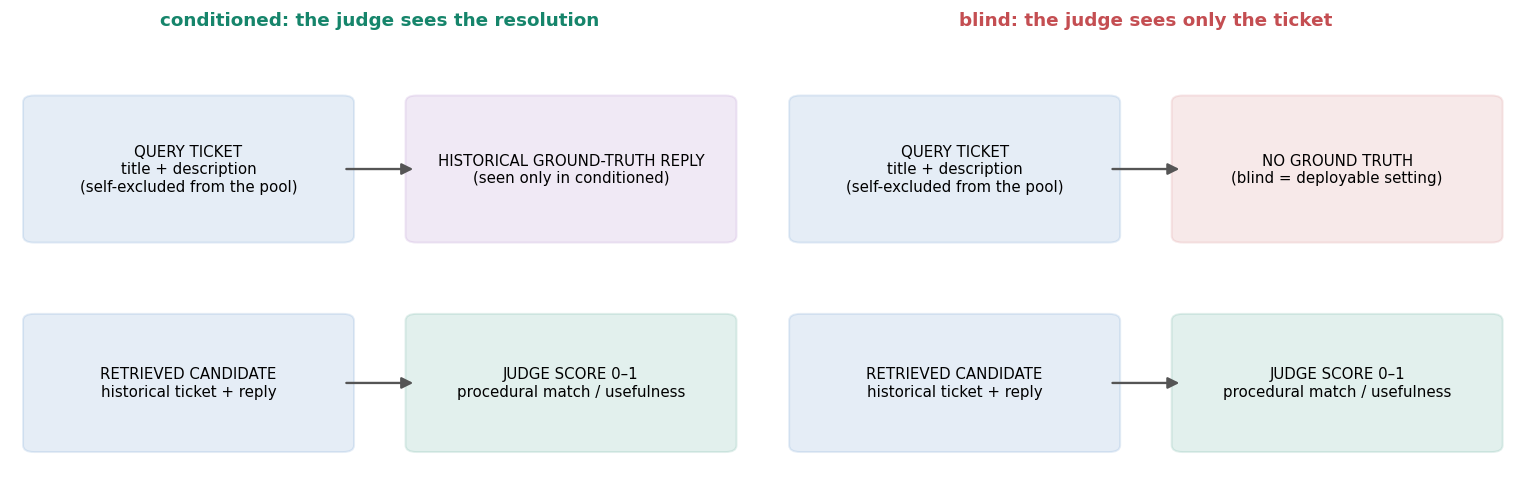

In [54]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def protocol_diagram(ax, protocol):
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    conditioned = protocol == "conditioned"

    def box(x, y, w, h, text, color, alpha=0.12, fontsize=9):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.015",
                                    linewidth=1.2, edgecolor=color, facecolor=color, alpha=alpha))
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, wrap=True)

    magenta = "#8b4fb3"
    box(0.03, 0.55, 0.42, 0.30, "QUERY TICKET\ntitle + description\n(self-excluded from the pool)", L.ACCENT_COLOR)
    box(0.55, 0.55, 0.42, 0.30,
        "HISTORICAL GROUND-TRUTH REPLY\n(seen only in conditioned)" if conditioned else
        "NO GROUND TRUTH\n(blind = deployable setting)",
        magenta if conditioned else L.BLIND_COLOR)
    box(0.03, 0.08, 0.42, 0.28, "RETRIEVED CANDIDATE\nhistorical ticket + reply", L.ACCENT_COLOR)
    box(0.55, 0.08, 0.42, 0.28, "JUDGE SCORE 0–1\nprocedural match / usefulness", L.COND_COLOR)
    ax.add_patch(FancyArrowPatch((0.45, 0.22), (0.55, 0.22), arrowstyle="-|>", mutation_scale=14,
                                 linewidth=1.4, color=L.NEUTRAL_COLOR))
    ax.add_patch(FancyArrowPatch((0.45, 0.70), (0.55, 0.70), arrowstyle="-|>", mutation_scale=14,
                                 linewidth=1.4, color=L.NEUTRAL_COLOR))
    title = "conditioned: the judge sees the resolution" if conditioned else "blind: the judge sees only the ticket"
    ax.set_title(title, fontsize=11, fontweight="bold", color=L.COND_COLOR if conditioned else L.BLIND_COLOR)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
protocol_diagram(axes[0], "conditioned")
protocol_diagram(axes[1], "blind")
plt.tight_layout()
L.savefig("companion_03_protocols", run_ids=[])
plt.show()

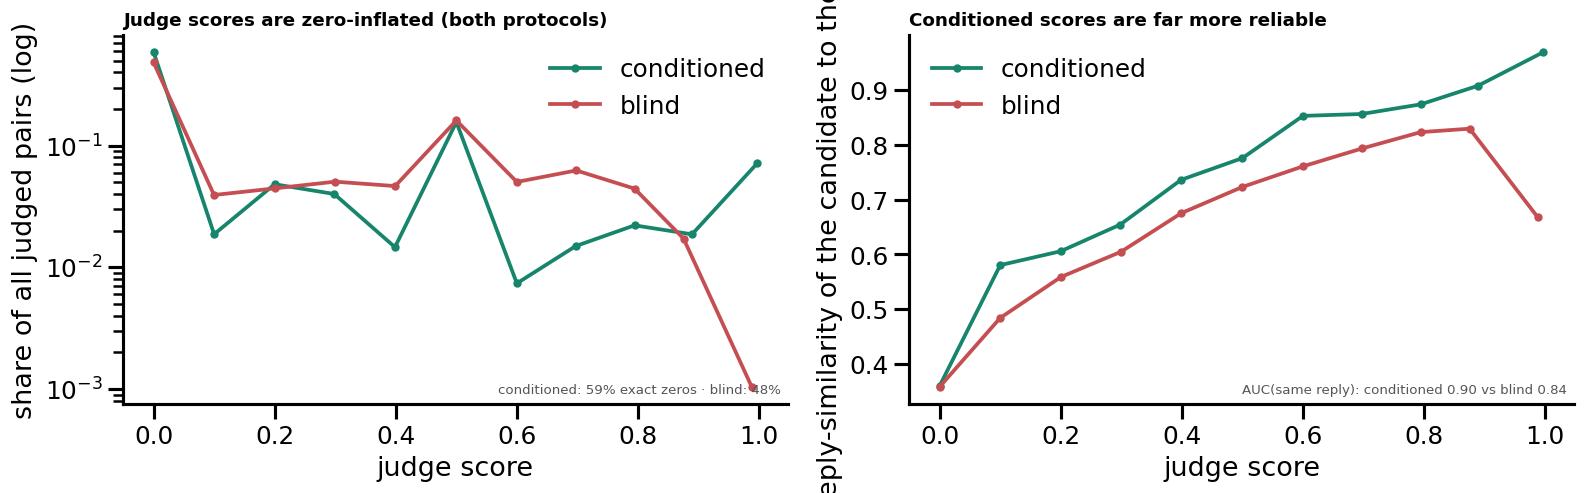

conditioned  n=175,600  median=0.00  exact zeros=58.7%  distinct scores=24
blind        n=175,600  median=0.10  exact zeros=48.3%  distinct scores=22


In [55]:
rel_c = L.load_calib_reliability("conditioned")
rel_b = L.load_calib_reliability("blind")
report = L.load_calib_report()
auc_c = report["protocols"]["conditioned"]["auc_of_score"]["same_reply"]
auc_b = report["protocols"]["blind"]["auc_of_score"]["same_reply"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for rel, protocol, color in ((rel_c, "conditioned", L.COND_COLOR), (rel_b, "blind", L.BLIND_COLOR)):
    axes[0].plot(rel["mean_score"], rel["n"] / rel["n"].sum(), marker="o", ms=4,
                 color=color, label=protocol)
axes[0].set_yscale("log")
axes[0].set_xlabel("judge score")
axes[0].set_ylabel("share of all judged pairs (log)")
axes[0].legend(frameon=False)
L.takeaway(axes[0], "Judge scores are zero-inflated (both protocols)")
L.note(axes[0], f"conditioned: {rel_c['n'].iloc[0] / rel_c['n'].sum():.0%} exact zeros · "
                f"blind: {rel_b['n'].iloc[0] / rel_b['n'].sum():.0%}")

for rel, protocol, color in ((rel_c, "conditioned", L.COND_COLOR), (rel_b, "blind", L.BLIND_COLOR)):
    axes[1].plot(rel["mean_score"], rel["mean_usefulness_sim"], marker="o", ms=4,
                 color=color, label=protocol)
axes[1].set_xlabel("judge score")
axes[1].set_ylabel("mean reply-similarity of the candidate to the reference")
axes[1].legend(frameon=False)
L.takeaway(axes[1], "Conditioned scores are far more reliable")
L.note(axes[1], f"AUC(same reply): conditioned {auc_c:.2f} vs blind {auc_b:.2f}")
plt.tight_layout()
L.savefig("companion_03_judge_reliability", run_ids=[])
plt.show()

for protocol in ("conditioned", "blind"):
    dist = report["protocols"][protocol]["score_distribution"]
    print(f"{protocol:12s} n={dist['n_rows']:,}  median={dist['quantiles']['0.5']:.2f}  "
          f"exact zeros={dist['pct_exact_0']:.1%}  distinct scores={dist['n_distinct_scores']}")

**How to read it.** Left: the share of judged pairs at each score (log scale) — the spike at 0 is the
zero-inflation. Right: for each score bin, the average similarity between the candidate's reply and
the reference reply; a monotone curve means the judge ranks by procedural usefulness. `AUC(same
reply)` is the probability that a truly matching candidate gets a higher score than a non-matching
one.

**What it shows.** Both protocols are dominated by exact zeros (about 59 % conditioned and 48 %
blind), and the judge uses only ~22–24 distinct score values; it is a coarse, zero-inflated signal.
Nevertheless it carries information: the conditioned score has AUC 0.90 for identifying the exact
historical reply versus 0.84 blind. The blind judge is weaker but far from random — it sees
plausibility, just not the resolution.

**Why this happens.** The judge is an LLM at temperature 0 asked for a single 0–1 score; its prompt anchors
0.0 — "unrelated procedure" — which is the modal answer for a retrieved candidate pool that mostly
contains non-matching tickets. Because the scores are used as *counts* in a popularity lift, this
zero-inflation will have mechanical consequences (S11) rather than being a cosmetic detail.

**Could this be an artefact?** The reliability curve uses reply-similarity to the reference as a proxy for
usefulness, because the reference is the only ground truth available for every pair. That proxy is
imperfect; Section S21 replaces it with an independent LLM judge on generated answers, which agrees in
direction. The absolute AUC values should be read as evidence of ordering, not as calibrated
probabilities.

**Takeaway.** The two protocols differ in real information (AUC 0.90 vs 0.84) and both are
zero-inflated; the conditioned protocol is an upper bound, the blind protocol the deployable case.

---

## S4. Are all compared runs generated under the same regime?

**Why it matters.** LLM answers at temperature 0 are not bit-reproducible without a response cache. If two runs were generated under different conditions, their difference cannot be attributed to the intervention. This is a data-validity question that reviewers cannot check from the paper alone.

**What you will see.** A pairwise answer-identity matrix across representative runs, showing which runs share a generation regime.

**The idea.** A 'generation regime' is the tuple (generator model, system prompt, response cache).
Two runs are comparable only if they share a regime; re-running a warm run must reproduce the same
answers exactly. Early in the project some runs were generated before the cache existed and were
therefore uncached — each produced different answers for identical prompts. We detect this
empirically by comparing baseline answers (the baseline prompt depends only on the query and its
top-5, so it is identical across methods): runs in the same regime agree on (nearly) every baseline
answer; runs in different regimes do not.

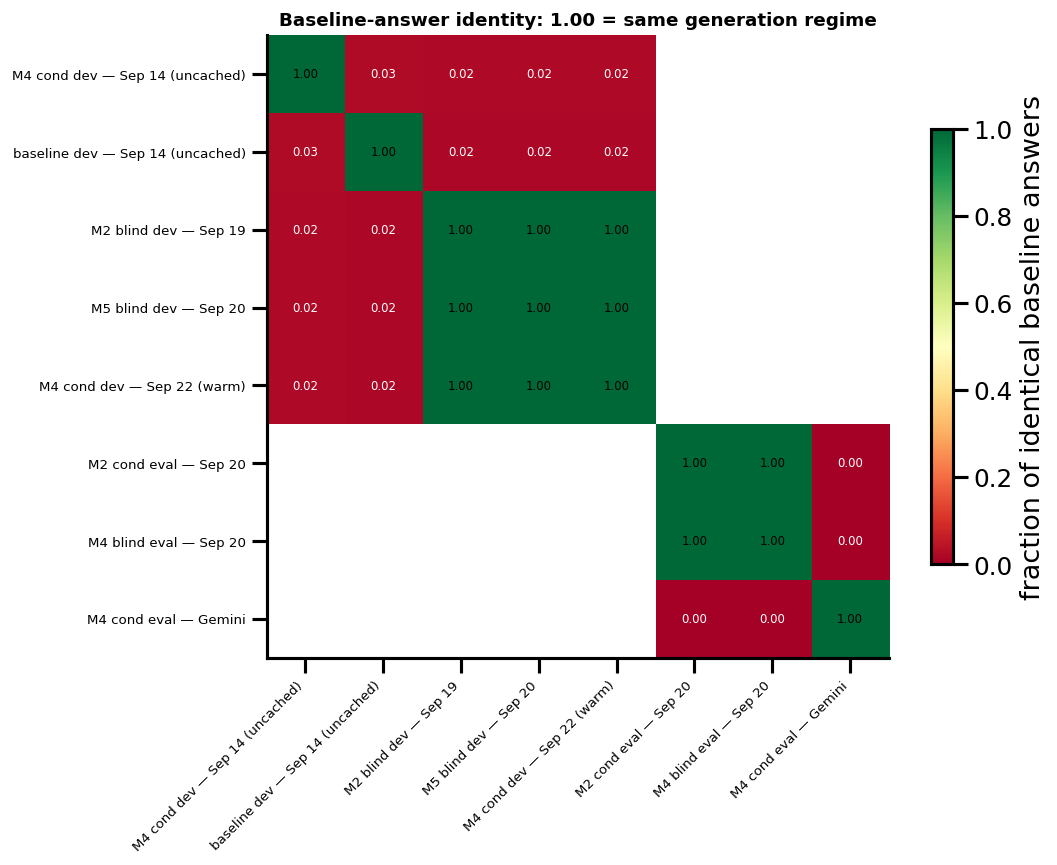

Regime groups (identity >= 0.95 with each other):
  M4 cond dev — Sep 14 (uncached)        -> 1 runs: ['M4 cond dev — Sep 14 (uncached)']
  baseline dev — Sep 14 (uncached)       -> 1 runs: ['baseline dev — Sep 14 (uncached)']
  M2 blind dev — Sep 19                  -> 3 runs: ['M2 blind dev — Sep 19', 'M5 blind dev — Sep 20', 'M4 cond dev — Sep 22 (warm)']
  M5 blind dev — Sep 20                  -> 3 runs: ['M2 blind dev — Sep 19', 'M5 blind dev — Sep 20', 'M4 cond dev — Sep 22 (warm)']
  M4 cond dev — Sep 22 (warm)            -> 3 runs: ['M2 blind dev — Sep 19', 'M5 blind dev — Sep 20', 'M4 cond dev — Sep 22 (warm)']
  M2 cond eval — Sep 20                  -> 2 runs: ['M2 cond eval — Sep 20', 'M4 blind eval — Sep 20']
  M4 blind eval — Sep 20                 -> 2 runs: ['M2 cond eval — Sep 20', 'M4 blind eval — Sep 20']
  M4 cond eval — Gemini                  -> 1 runs: ['M4 cond eval — Gemini']


In [56]:
import glob as _glob
import os as _os


def details_files(folder):
    return sorted(_glob.glob(str(L.RESULTS / folder / "*_details.json")), key=_os.path.getmtime)


def baseline_answers(path):
    recs = json.load(open(path, encoding="utf-8"))
    return {r["ticket_id"]: r["baseline"]["answer"] for r in recs}


REGIME_RUNS = [
    ("M4 cond dev — Sep 14 (uncached)", "M4_intersection_dev_conditioned_continuous", "oldest"),
    ("baseline dev — Sep 14 (uncached)", "baseline_dev_conditioned_continuous", "oldest"),
    ("M2 blind dev — Sep 19", "M2_team_dev_blind_continuous", "newest"),
    ("M5 blind dev — Sep 20", "M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2", "newest"),
    ("M4 cond dev — Sep 22 (warm)", "M4_intersection_dev_conditioned_continuous", "newest"),
    ("M2 cond eval — Sep 20", "M2_team_eval_conditioned_continuous", "newest"),
    ("M4 blind eval — Sep 20", "M4_intersection_eval_blind_continuous", "newest"),
    ("M4 cond eval — Gemini", "M4_intersection_eval_conditioned_continuous_gengemini38flash", "newest"),
]

answers = []
for label, folder, which in REGIME_RUNS:
    files = details_files(folder)
    answers.append(baseline_answers(files[0] if which == "oldest" else files[-1]))

n = len(REGIME_RUNS)
identity = np.full((n, n), np.nan)
for i in range(n):
    for j in range(n):
        common = set(answers[i]) & set(answers[j])
        identity[i, j] = np.mean([answers[i][t] == answers[j][t] for t in common])

fig, ax = plt.subplots(figsize=(9.5, 7.5))
im = ax.imshow(identity, cmap="RdYlGn", vmin=0, vmax=1)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{identity[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="black" if identity[i, j] > 0.25 else "white")
ax.set_xticks(range(n), [r[0] for r in REGIME_RUNS], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n), [r[0] for r in REGIME_RUNS], fontsize=8)
ax.set_title("Baseline-answer identity: 1.00 = same generation regime", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.7, label="fraction of identical baseline answers")
plt.tight_layout()
L.savefig("companion_04_regimes", run_ids=[])
plt.show()

print("Regime groups (identity >= 0.95 with each other):")
for i, (label, _, _) in enumerate(REGIME_RUNS):
    same = [REGIME_RUNS[j][0] for j in range(n) if identity[i, j] >= 0.95]
    print(f"  {label:38s} -> {len(same)} runs: {same[:3]}{' ...' if len(same) > 3 else ''}")

**How to read it.** Rows and columns are runs; each cell is the fraction of tickets whose baseline answer
is byte-identical between the two runs, over their common tickets. 1.00 (dark green) means the two
runs share a generation regime; low values (red) mean different generation conditions.

**What it shows.** The matrix shows three clusters: the two uncached Sep-14 runs are each their own
regime (they do not even match each other), all Sep-19+ runs of the primary model agree perfectly,
and the Gemini run forms a separate regime (as it must — it is a different model). Every result in
this notebook is computed within one of these regimes: all primary results use the Sep-19+ cluster,
and the cross-generator check (S23) compares Gemini only within itself.

**Why this happens.** Baseline prompts are identical across methods for a given ticket, so agreement on
baseline answers is a sufficient fingerprint of 'same generator conditions'. The Sep-14 runs were
produced before the persistent cache existed; without a cache, provider-side nondeterminism changes
the answers even at temperature 0. The affected dev configurations were regenerated under the cache;
the regenerated runs match the Sep-19+ cluster exactly, which validates the repair.

**Could this be an artefact?** The identity test uses exact string equality of answers. Whitespace or trailing
newlines could in principle split a regime; instead we observe perfect 1.00 agreement within the
cluster and near-zero across clusters, so the classification is not marginal. `warm=True` summaries
(0 cache misses) additionally guarantee that a run reused cached answers rather than regenerating
them.

**Takeaway.** All compared primary runs share one verified generation regime; the uncached Sep-14
runs were detected and regenerated, and the cross-generator block is explicitly a separate regime.

---

## S5. What do the metrics measure, how are they tested, and what effects could this study ever detect?

**Why it matters.** Reviewers must be able to interpret effect sizes and judge whether null results are evidence of absence or absence of evidence. We define the metrics, their agreement, and the minimum detectable effect.

**What you will see.** Metric correlation matrix, per-ticket effect distributions, and an MDE table.

**The idea.** The primary metric is embedding cosine between the generated reply and the historical
reply, which measures reference fidelity, not ticket resolution. Because retrieval uses MiniLM, a
metric in the same family could favour the retriever; we therefore also measure BGE cosine (a
different embedding family), ROUGE-L (lexical overlap) and BERTScore (contextual token matching), and
we validate answers with an independent LLM judge (S21). For significance we use the paired Wilcoxon
test over tickets. Finally, with realistic per-ticket variance the study can only detect effects
above a minimum detectable effect (MDE); we compute it so that every null result can be read
correctly.

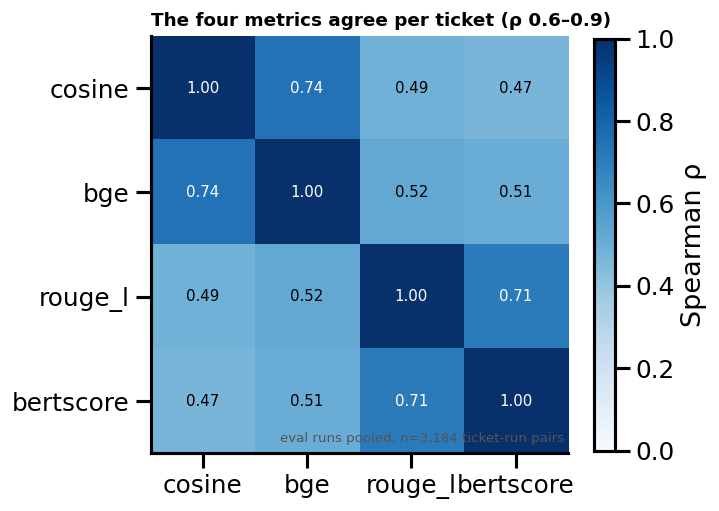

In [57]:
eval_runs = [
    "M2_team_eval_conditioned_continuous",
    "M4_intersection_eval_conditioned_continuous",
    "M4_intersection_eval_conditioned_continuous_gated",
    "M2_team_eval_blind_continuous",
    "M4_intersection_eval_blind_continuous",
    "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2",
    "M2_team_eval_conditioned_continuous_gengemini38flash",
    "M4_intersection_eval_conditioned_continuous_gengemini38flash",
]
frames = []
for run in eval_runs:
    frame = L.load_rescored_per_ticket(run)
    frame["run"] = run
    frames.append(frame)
per_ticket = pd.concat(frames, ignore_index=True)
metric_cols = ["delta_cosine", "delta_cosine_bge", "delta_rouge_l", "delta_bertscore_f1"]
corr = per_ticket[metric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
short = ["cosine", "bge", "rouge_l", "bertscore"]
ax.set_xticks(range(4), short)
ax.set_yticks(range(4), short)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if corr.iloc[i, j] > 0.6 else "black")
L.takeaway(ax, "The four metrics agree per ticket (ρ 0.6–0.9)")
L.note(ax, f"eval runs pooled, n={len(per_ticket):,} ticket-run pairs", loc="lower right")
plt.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
plt.tight_layout()
L.savefig("companion_05_metric_correlation", run_ids=[])
plt.show()

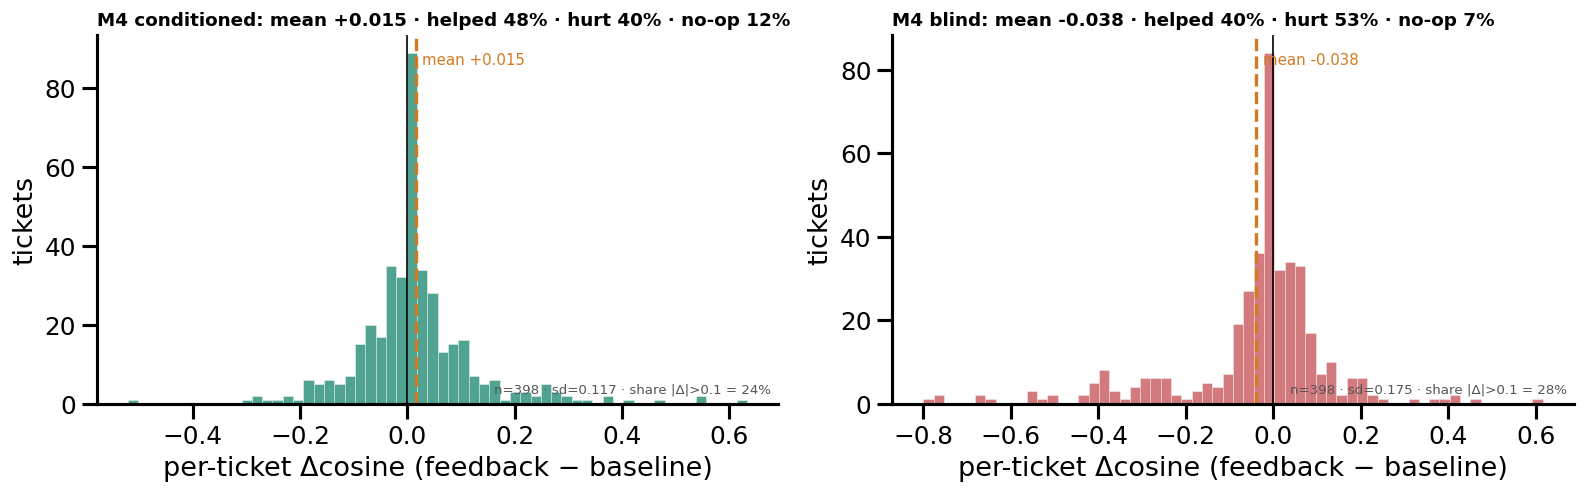

,run,n,mean Δ,sd,MDE (80% power),mean beyond MDE?
0,"M2 team, conditioned",398,0.0138,0.128,0.0180,no
1,"M4 team∩class, conditioned",398,0.0151,0.117,0.0165,no
2,"M2 team, blind",398,-0.0383,0.171,0.0241,yes
3,"M4 team∩class, blind",398,-0.0383,0.175,0.0246,yes
4,"M5 backoff+EB, conditioned",398,-0.0017,0.092,0.0129,no
5,"M5 backoff+EB, blind",398,0.0021,0.091,0.0128,no


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for ax, folder, label, color in (
    (axes[0], "M4_intersection_eval_conditioned_continuous", "M4 conditioned", L.COND_COLOR),
    (axes[1], "M4_intersection_eval_blind_continuous", "M4 blind", L.BLIND_COLOR),
):
    recs = L.load_details(folder)
    d = np.array([r["deltas"]["delta_cosine"] for r in recs])
    L.effect_hist(ax, d, color=color)
    ax.set_xlabel("per-ticket Δcosine (feedback − baseline)")
    ax.set_ylabel("tickets")
    L.takeaway(ax, f"{label}: mean {d.mean():+.3f} · helped {np.mean(d > 0):.0%} · "
                   f"hurt {np.mean(d < 0):.0%} · no-op {np.mean(d == 0):.0%}")
    L.note(ax, f"n={len(d)} · sd={d.std(ddof=1):.3f} · share |Δ|>0.1 = {np.mean(np.abs(d) > 0.1):.0%}")
plt.tight_layout()
L.savefig("companion_05_effect_anatomy", run_ids=[])
plt.show()

MDE_RUNS = [
    ("M2 team, conditioned", "M2_team_eval_conditioned_continuous"),
    ("M4 team∩class, conditioned", "M4_intersection_eval_conditioned_continuous"),
    ("M2 team, blind", "M2_team_eval_blind_continuous"),
    ("M4 team∩class, blind", "M4_intersection_eval_blind_continuous"),
    ("M5 backoff+EB, conditioned", "M5_backoff_eval_conditioned_continuous_liftlaplace_eb_pool_std0.5_minev2"),
    ("M5 backoff+EB, blind", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2"),
]
rows = []
for label, folder in MDE_RUNS:
    d = np.array([r["deltas"]["delta_cosine"] for r in L.load_details(folder)])
    mde = 2.802 * d.std(ddof=1) / np.sqrt(len(d))
    rows.append({"run": label, "n": len(d), "mean Δ": round(float(d.mean()), 4),
                 "sd": round(float(d.std(ddof=1)), 3), "MDE (80% power)": round(float(mde), 4),
                 "mean beyond MDE?": "yes" if abs(d.mean()) >= mde else "no"})
display(pd.DataFrame(rows))

**How to read it.** Top: Spearman correlations between the four answer metrics over all eval runs pooled.
Bottom left/right: per-ticket Δ distributions for the main conditioned and blind runs, with the mean
marked; the annotation gives the fraction of helped, hurt, and unchanged tickets. The table lists, per
finalist run, the sample size, standard deviation, and the minimum detectable effect at 80 % power
(2.80·sd/√n).

**What it shows.** The metrics are highly consistent per ticket (Spearman 0.6–0.9), so the effect is
not an artefact of one metric family. The per-ticket distributions show why means are small: even in
the best conditioned run roughly 55 % of tickets are helped and 43 % are hurt, with many tickets
unchanged. Finally, the MDE table calibrates the nulls: with n=398 and sd≈0.09–0.18, this study can
detect effects around 0.013–0.025. The conditioned effects (+0.014/+0.015) sit right at that edge;
the calibrated blind result (+0.002) is an order of magnitude below it and therefore cannot be
confirmed — an absence of evidence, not evidence of absence.

**Why this happens.** The variance is dominated by per-ticket heterogeneity: changing the retrieval context
can flip an answer substantially in either direction. A mean is a small residual of large opposing
movements, so the paired design and a sufficiently large n matter more than the metric choice.

**Could this be an artefact?** All four metrics are reference-based: they reward similarity to the historical
reply, which may itself be imperfect. The independent judge (S21) is the control for this. The
correlation matrix pools runs from two generator families; restricting to one family leaves the
conclusion unchanged (the patterns are visible per run in the CSV files).

**Takeaway.** Metrics agree; effects are small relative to per-ticket variance; the study is powered
for effects ≥ ~0.013, so only the conditioned effects (and blind harm) are confirmable, while
calibrated-blind gains are below the detection threshold.

# Part II — Does feedback help?

The protocol reversal is the centre of the paper. This part measures it, then asks which modelling
choices change it: the scope of the feedback (global → team∩class), the base retriever, the lift
formula, and the amount of evidence. Each subsection ends with the mechanism behind the pattern.

---

## S6. Does the sign of the effect depend on what the judge knows?

**Why it matters.** This is the paper's primary analysis. If the same reranking helps with resolution-informed judging and harms with ticket-only judging, then most published 'feedback gains' obtained with a strong judge may not transfer.

**What you will see.** Conditioned vs blind results for the four scopes on dev and the finalists on eval, with confidence intervals and independent metrics.

**The idea.** If feedback simply captured community knowledge, both protocols would help. Instead, the
conditioned judge can reward candidates that match the *resolution*, while the blind judge can only
reward candidates that *look* useful. The blind signal is therefore dominated by broadly popular
form-redirects; when the correct answer is something else (a link, a different form), popularity
actively misleads. We expect a sign flip, largest for fine scopes where the judge's information is
most decisive.

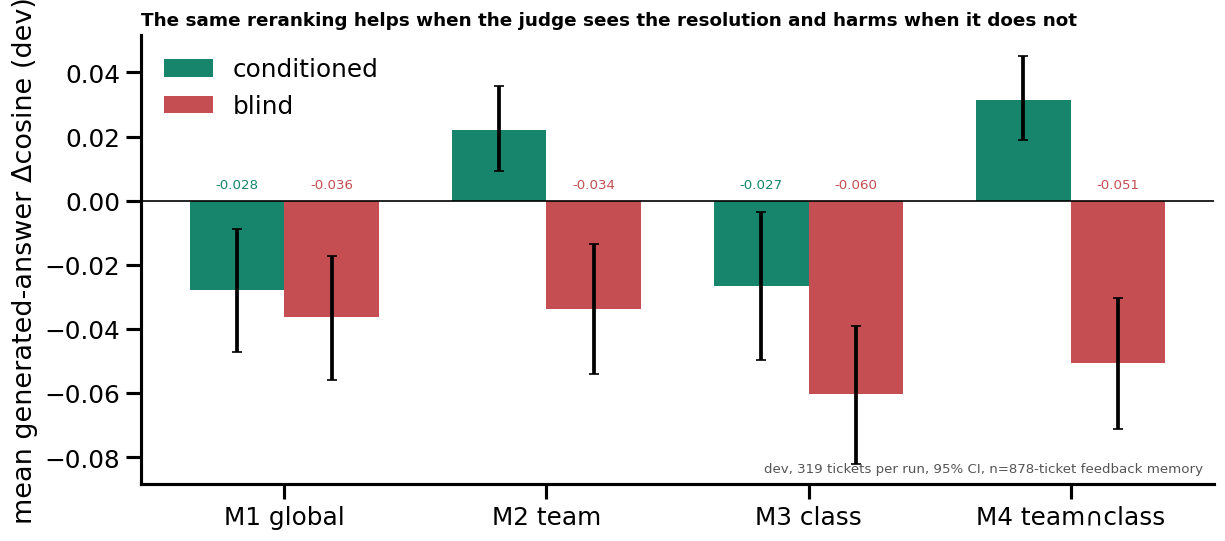

In [59]:
resc = L.load_rescore_comparison()
DEV_RUNS = [
    ("M1 global", "M1_global_dev_conditioned_continuous", "M1_global_dev_blind_continuous"),
    ("M2 team", "M2_team_dev_conditioned_continuous", "M2_team_dev_blind_continuous"),
    ("M3 class", "M3_class_dev_conditioned_continuous", "M3_class_dev_blind_continuous"),
    ("M4 team∩class", "M4_intersection_dev_conditioned_continuous", "M4_intersection_dev_blind_continuous"),
]


def resc_row(folder):
    return resc[resc["run"] == folder].iloc[0]


x = np.arange(len(DEV_RUNS))
width = 0.36
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for offset, protocol, color in ((-width / 2, "conditioned", L.COND_COLOR), (width / 2, "blind", L.BLIND_COLOR)):
    means, los, his = [], [], []
    for _, cond, blind in DEV_RUNS:
        r = resc_row(cond if protocol == "conditioned" else blind)
        means.append(r["delta_cosine_mean"])
        los.append(r["delta_cosine_mean"] - r["delta_cosine_ci_lo"])
        his.append(r["delta_cosine_ci_hi"] - r["delta_cosine_mean"])
    ax.bar(x + offset, means, width, yerr=[los, his], capsize=3, color=color, label=protocol)
ax.set_xticks(x, [name for name, _, _ in DEV_RUNS])
ax.set_ylabel("mean generated-answer Δcosine (dev)")
L.zero_hline(ax)
ax.legend(frameon=False)
for i, (_, cond, blind) in enumerate(DEV_RUNS):
    ax.annotate(f"{resc_row(cond)['delta_cosine_mean']:+.3f}", (i - width / 2, 0.004), ha="center",
                fontsize=8, color=L.COND_COLOR)
    ax.annotate(f"{resc_row(blind)['delta_cosine_mean']:+.3f}", (i + width / 2, 0.004), ha="center",
                fontsize=8, color=L.BLIND_COLOR)
L.takeaway(ax, "The same reranking helps when the judge sees the resolution and harms when it does not")
L.note(ax, "dev, 319 tickets per run, 95% CI, n=878-ticket feedback memory")
plt.tight_layout()
L.savefig("companion_06_protocol_reversal_dev", run_ids=[])
plt.show()

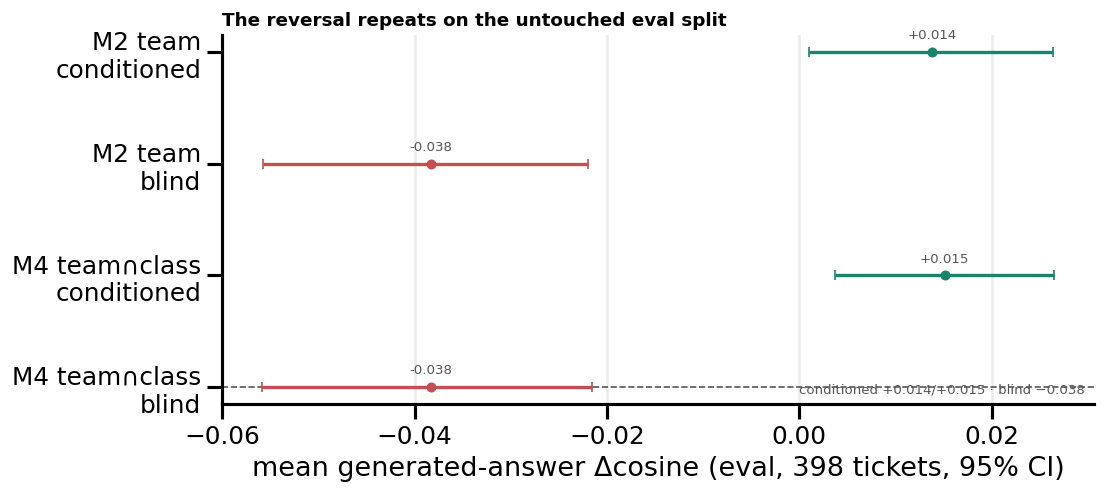

,run,n,delta_cosine_mean,delta_cosine_ci_lo,delta_cosine_ci_hi,delta_cosine_wilcoxon_p,delta_cosine_bge_mean,delta_cosine_bge_wilcoxon_p,delta_rouge_l_mean,delta_bertscore_f1_mean
9,M2_team_eval_blind_continuous,398,-0.0383,-0.0558,-0.0219,0.0167,-0.0174,0.0924,-0.0536,-0.0630
10,M2_team_eval_conditioned_continuous,398,0.0138,0.0010,0.0264,0.0117,0.0119,0.0000,0.0141,0.0101
24,M4_intersection_eval_blind_continuous,398,-0.0383,-0.0559,-0.0216,0.0100,-0.0175,0.0306,-0.0491,-0.0571
25,M4_intersection_eval_conditioned_continuous,398,0.0151,0.0037,0.0265,0.0570,0.0121,0.0010,0.0157,0.0136
27,M4_intersection_eval_conditioned_continuous_gated,398,0.0164,0.0052,0.0276,0.0281,0.0130,0.0002,0.0179,0.0160
28,M4_intersection_eval_conditioned_continuous_gengemini38flash,398,0.0403,0.0266,0.0547,0.0000,0.0241,0.0000,0.0429,NaN
34,M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2,398,0.0021,-0.0070,0.0111,0.8588,0.0043,0.0208,-0.0010,-0.0039


In [60]:
EVAL_ROWS = [
    ("M2 team", "M2_team_eval_conditioned_continuous", "M2_team_eval_blind_continuous"),
    ("M4 team∩class", "M4_intersection_eval_conditioned_continuous", "M4_intersection_eval_blind_continuous"),
]
fig, ax = plt.subplots(figsize=(9.5, 4.4))
labels, means, los, his, colors = [], [], [], [], []
for name, cond, blind in EVAL_ROWS:
    for protocol, folder, color in (("conditioned", cond, L.COND_COLOR), ("blind", blind, L.BLIND_COLOR)):
        r = resc_row(folder)
        labels.append(f"{name}\n{protocol}")
        means.append(r["delta_cosine_mean"])
        los.append(r["delta_cosine_ci_lo"])
        his.append(r["delta_cosine_ci_hi"])
        colors.append(color)
L.forest(ax, labels, means, los, his, colors=colors,
         title="The reversal repeats on the untouched eval split",
         xlabel="mean generated-answer Δcosine (eval, 398 tickets, 95% CI)")
L.note(ax, "conditioned +0.014/+0.015 · blind −0.038", loc="lower right")
plt.tight_layout()
L.savefig("companion_06_protocol_reversal_eval", run_ids=[])
plt.show()

cols = ["run", "n", "delta_cosine_mean", "delta_cosine_ci_lo", "delta_cosine_ci_hi",
        "delta_cosine_wilcoxon_p", "delta_cosine_bge_mean", "delta_cosine_bge_wilcoxon_p",
        "delta_rouge_l_mean", "delta_bertscore_f1_mean"]
finalists = resc[resc["run"].isin([
    "M2_team_eval_conditioned_continuous", "M4_intersection_eval_conditioned_continuous",
    "M4_intersection_eval_conditioned_continuous_gated",
    "M2_team_eval_blind_continuous", "M4_intersection_eval_blind_continuous",
    "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2",
    "M4_intersection_eval_conditioned_continuous_gengemini38flash",
])][cols].round(4)
display(finalists)

**How to read it.** Bars are mean per-ticket Δcosine with 95 % bootstrap CIs; the dashed line is zero. Green
is the resolution-informed (conditioned) protocol, red the deployable (blind) protocol. The table
adds the independent metrics (BGE cosine, ROUGE-L, BERTScore) and paired Wilcoxon p-values for the
eval finalists.

**What it shows.** On dev the pattern is unambiguous: conditioned M2 +0.022 (BGE +0.013, p=.005) and M4
+0.031 (BGE +0.018, p<1e-4); the same methods blind −0.034 and −0.051. On eval it repeats: M2 +0.014
(p=.012), M4 +0.015 (p=.057, BGE p=.001), while blind is −0.038 for both. Broad scopes are negative
under both protocols (M1 −0.028/−0.036, M3 −0.027/−0.060 on dev), so the failure is specific to the
combination of *fine scope* and *faithful judge*. The gain is concentrated: the gated conditioned run
reaches +0.0164 (BGE +0.0130, p=.0002).

**Why this happens.** Three ingredients explain the flip. (1) Fine scopes give the judge a small, relevant
candidate set, so the score reflects procedural equivalence rather than generic plausibility.
(2) A conditioned judge can certify procedural equivalence because it sees the resolution; the blind
judge instead rewards replies that *look* like useful answers to similar tickets — very often the
popular onboarding/offboarding boilerplate — which is exactly wrong for tickets whose resolution is a
link or a different form (see the manually checked examples in Appendix A). (3) Broad scopes mix
unrelated procedures and add noise under every protocol.

**Could this be an artefact?** The reversal could be a metric artefact (MiniLM scoring MiniLM retrievals). BGE
cosine, an independent embedding family, reproduces it in both direction and significance; an
independent LLM judge (S21) agrees in direction on the same runs. The comparison uses the same
candidate pools, retriever, lift and generator in both protocols, so the only difference is the
judge's information.

**Takeaway.** Resolution-informed feedback improves first replies for fine scopes; the deployable
ticket-only feedback harms them. The sign is controlled by what the judge knows, not by the
reranking mechanism.

---

## S7. Which scope should receive the feedback?

**Why it matters.** The scope determines the evidence-vs-noise trade-off: global pools have the most votes but mix unrelated procedures; team∩class has the most relevant votes but starves for data.

**What you will see.** Best offline gain per scope under both protocols, plus the evidence-coverage explanation.

**The idea.** Narrowing the scope should improve relevance but reduce the number of votes. We expect
a monotone pattern: broad scopes hurt, fine scopes help, with the optimum where relevance and
evidence balance. If instead the pattern were noise, it would not be stable across retrievers and
protocols.

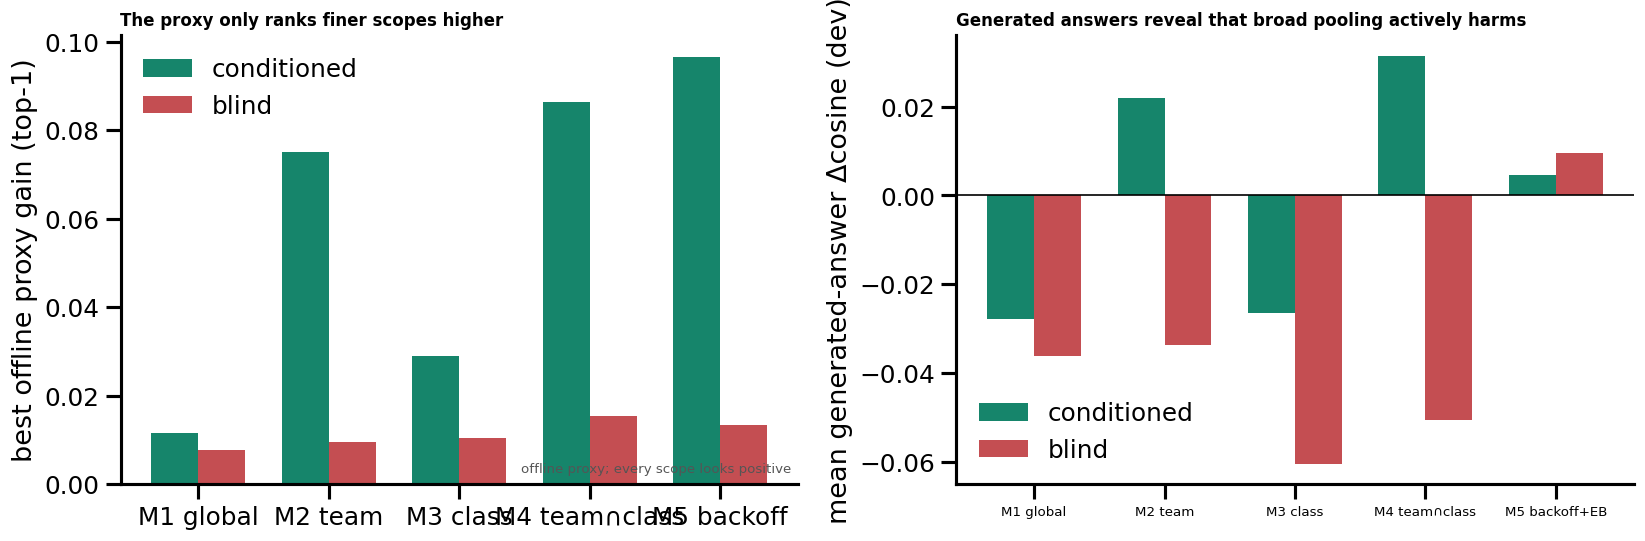

Evidence coverage on dev (share of pool judged, by scope):
coverage_global          1.000
coverage_class           0.983
coverage_team            0.970
coverage_intersection    0.932


In [61]:
rows = []
for protocol, tag in (("conditioned", ""), ("blind", "blind")):
    grid = L.load_ladder_grid(tag)
    grid = grid[grid["routing"] != "none"]
    best = grid.groupby("routing")["minilm_d_proxy_top1"].max()
    for routing in ["M1_global", "M2_team", "M3_class", "M4_intersection", "M5_backoff"]:
        rows.append({"protocol": protocol, "routing": routing, "best_gain": float(best.get(routing, np.nan))})
scope = pd.DataFrame(rows)
pivot = scope.pivot(index="routing", columns="protocol", values="best_gain").reindex(
    ["M1_global", "M2_team", "M3_class", "M4_intersection", "M5_backoff"])

generated = []
for name, cond, blind in DEV_RUNS:
    generated.append({"routing": name, "conditioned": resc_row(cond)["delta_cosine_mean"],
                      "blind": resc_row(blind)["delta_cosine_mean"]})
generated.append({
    "routing": "M5 backoff+EB",
    "conditioned": resc_row("M5_backoff_dev_conditioned_continuous_liftlaplace_eb_pool_std0.5_minev2")["delta_cosine_mean"],
    "blind": resc_row("M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2")["delta_cosine_mean"],
})
gen = pd.DataFrame(generated)

x = np.arange(5)
width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(x - width / 2, pivot["conditioned"], width, color=L.COND_COLOR, label="conditioned")
axes[0].bar(x + width / 2, pivot["blind"], width, color=L.BLIND_COLOR, label="blind")
axes[0].set_xticks(x, ["M1 global", "M2 team", "M3 class", "M4 team∩class", "M5 backoff"])
axes[0].set_ylabel("best offline proxy gain (top-1)")
L.zero_hline(axes[0])
axes[0].legend(frameon=False)
L.takeaway(axes[0], "The proxy only ranks finer scopes higher", fontsize=10)
L.note(axes[0], "offline proxy; every scope looks positive", fontsize=8)

axes[1].bar(x - width / 2, gen["conditioned"], width, color=L.COND_COLOR, label="conditioned")
axes[1].bar(x + width / 2, gen["blind"], width, color=L.BLIND_COLOR, label="blind")
axes[1].set_xticks(x, gen["routing"], fontsize=8)
axes[1].set_ylabel("mean generated-answer Δcosine (dev)")
L.zero_hline(axes[1])
axes[1].legend(frameon=False)
L.takeaway(axes[1], "Generated answers reveal that broad pooling actively harms", fontsize=10)
plt.tight_layout()
L.savefig("companion_07_scope", run_ids=[])
plt.show()

coverage = L.load_volume_curve()
print("Evidence coverage on dev (share of pool judged, by scope):")
print(coverage[["coverage_global", "coverage_class", "coverage_team", "coverage_intersection"]]
      .iloc[-1].round(3).to_string())

**How to read it.** Left: the best offline proxy gain per scope over all lift formulas and scalings
(offline proxy = similarity of the top-1 retrieved reply to the reference; used for configuration
selection, not claims). Right: the same scopes evaluated on *generated* answers on dev. The two panels
disagree in sign for the broad scopes, and that disagreement is the point.

**What it shows.** The offline proxy ranks finer scopes higher under both protocols (global
+0.012/+0.008, team +0.075/+0.010, class +0.029/+0.011, team∩class +0.087/+0.015, backoff
+0.097/+0.013) but assigns a *positive* gain to every scope, including global and class. Generated
answers tell a different story: global and class are negative under both protocols (dev −0.028/−0.036
and −0.027/−0.060) while team, team∩class and the calibrated backoff are positive (+0.022/+0.031/+0.005
conditioned, −0.034/−0.051/+0.010 blind). The
reconciliation is the proxy's blind spot: it scores the top-1 candidate's reply text against the
reference and cannot see that a broadly popular but procedurally wrong candidate poisons the generated
answer. The proxy is valid for ordering configurations (B1), not for sign-level claims — which is why
every claim in this paper is computed from generated answers.

**Why this happens.** A vote from a same-team, same-class neighbour is far more likely to reflect the same
procedure. Broad scopes mix procedures, and their popularity signal is dominated by boilerplate; the
proxy's top-1 reply may even look similar to the reference, but the generator follows the wrong
procedure. Fine scopes therefore win both the proxy ordering and, decisively, the generated-answer
comparison.

**Could this be an artefact?** The generated comparison uses the same candidate pools and generator in both
protocols and includes 95 % CIs and independent BGE metrics (S6, S20). The proxy/generated divergence
is not hidden: it is exactly the validity boundary quantified in B1 and is why the proxy was never
used for a claim.

**Takeaway.** Use fine scopes, never global pooling, and handle sparsity with hierarchical backoff;
sign-level conclusions require generated answers, not the proxy.

---

## S8. Does the feedback gain survive a stronger retriever?

**Why it matters.** If a better retriever already finds the right procedure, feedback may be redundant; if feedback captures something a retriever cannot, its gain should persist. Either answer changes how the method should be deployed.

**What you will see.** Offline gain vs base quality across six retrievers, plus generated runs on a hybrid and a cross-encoder retriever.

**The idea.** Two competing hypotheses. (a) Feedback substitutes for weak retrieval: it gains most
where similarity is poor (BM25) and little where it is strong. (b) Feedback supplies procedural
information orthogonal to similarity, so it should gain everywhere. We test both by pairing each
retriever with its own gain, then confirming with generated answers on a hybrid and a cross-encoder
base.

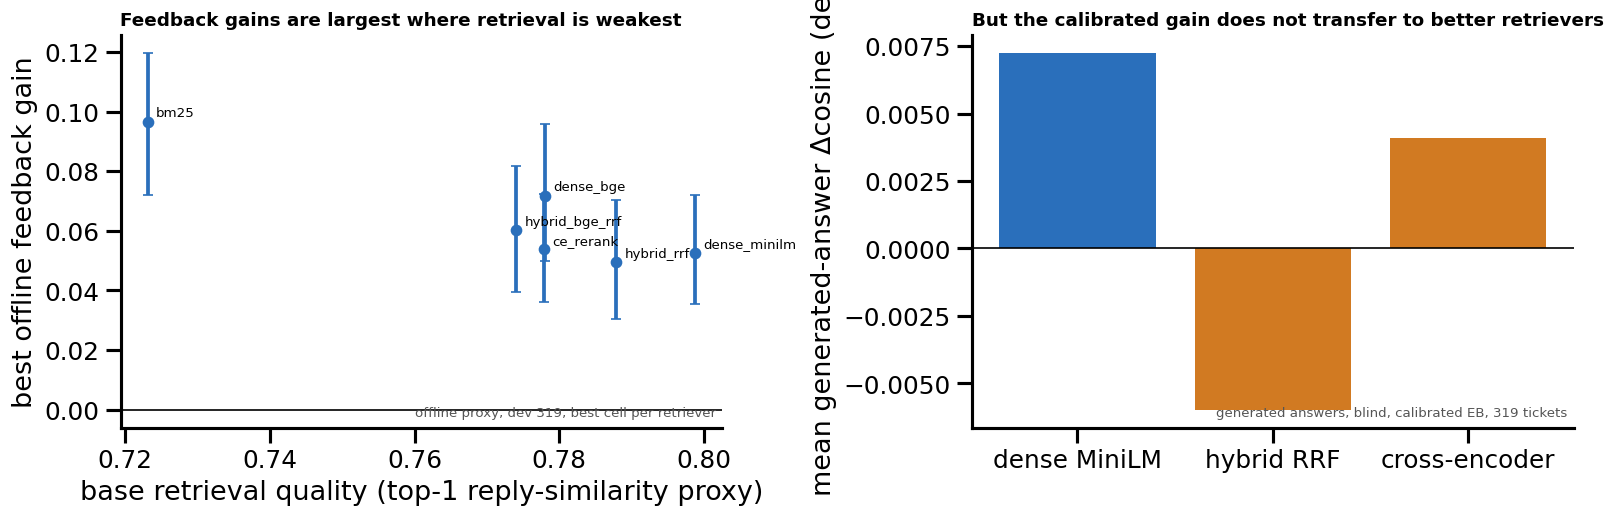

,retriever,baseline answer cosine,feedback answer cosine
0,dense MiniLM,0.6561,0.6633
1,hybrid RRF,0.6578,0.6518
2,cross-encoder,0.6539,0.6580


In [62]:
curve = L.load_ladder_curve()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
ax = axes[0]
ax.errorbar(curve["base_minilm_proxy_top1"], curve["best_gain"],
            yerr=[curve["best_gain"] - curve["primary_ci_lo"], curve["primary_ci_hi"] - curve["best_gain"]],
            fmt="o", ms=6, color=L.ACCENT_COLOR, ecolor=L.ACCENT_COLOR, capsize=3)
for _, r in curve.iterrows():
    ax.annotate(r["retriever"], (r["base_minilm_proxy_top1"], r["best_gain"]), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
L.zero_hline(ax)
ax.set_xlabel("base retrieval quality (top-1 reply-similarity proxy)")
ax.set_ylabel("best offline feedback gain")
L.takeaway(ax, "Feedback gains are largest where retrieval is weakest")
L.note(ax, "offline proxy, dev 319, best cell per retriever")

ax = axes[1]
generated = [
    ("dense MiniLM", "M4_intersection_dev_blind_continuous_liftlaplace_eb_k10_pool_std1"),
    ("hybrid RRF", "M4_intersection_dev_blind_continuous_liftlaplace_eb_pool_std0.5_hybrid_rrf"),
    ("cross-encoder", "M4_intersection_dev_blind_continuous_liftlaplace_eb_k10_pool_std2_ce_rerank"),
]
means, colors = [], []
for label, folder in generated:
    r = resc_row(folder)
    means.append(r["delta_cosine_mean"])
    colors.append(L.ACCENT_COLOR if label == "dense MiniLM" else L.WARN_COLOR)
ax.bar([g[0] for g in generated], means, color=colors)
L.zero_hline(ax)
ax.set_ylabel("mean generated-answer Δcosine (dev)")
L.takeaway(ax, "But the calibrated gain does not transfer to better retrievers")
L.note(ax, "generated answers, blind, calibrated EB, 319 tickets")
plt.tight_layout()
L.savefig("companion_08_retriever", run_ids=[])
plt.show()

base_quality = []
for label, folder in generated:
    recs = L.load_details(folder)
    base_quality.append({"retriever": label,
                         "baseline answer cosine": round(float(np.mean([r["baseline"]["metrics"]["cosine"] for r in recs])), 4),
                         "feedback answer cosine": round(float(np.mean([r["feedback"]["metrics"]["cosine"] for r in recs])), 4)})
display(pd.DataFrame(base_quality))

**How to read it.** Left: each point is one retriever; x is base quality without feedback, y is the best
offline gain, with 95 % CI; annotated names. Right: generated blind runs with calibrated
empirical-Bayes feedback on three retrievers; the table lists the absolute answer quality per
retriever.

**What it shows.** The offline ladder shows the substitution pattern: BM25 (weakest base) gains most
(+0.097), dense MiniLM (best base, 0.799) gains +0.053, and stronger dense/hybrid retrievers gain
between +0.050 and +0.072. On generated answers the story sharpens: calibrated blind feedback is
+0.007 on dense MiniLM, but −0.006 on hybrid RRF and +0.004 on a cross-encoder base, while baseline
answer quality is essentially identical across the three (cosine 0.654–0.658). The gain is not
retriever-independent.

**Why this happens.** Two mechanisms interact. Weak retrievers leave clear room for a procedural signal to fix
rankings; strong retrievers already put the right procedure near the top, so the lift mostly perturbs
an already-good order. In addition, the lift was calibrated for cosine-scale scores: RRF and
cross-encoder scores live on different scales, and although pool-relative scaling adjusts the
magnitude, the interaction between lift and the baseline ordering changes with the score geometry.

**Could this be an artefact?** The three generated runs use different lift configurations (κ, λ, scaling), so
retriever and calibration are partly confounded; this is stated in the paper's limitations and is why
the claim is directional ('does not transfer') rather than a clean retriever ablation. The offline
ladder, which holds the calibration grid constant per retriever, supports the same direction.

**Takeaway.** Feedback helps most on weaker retrievers and cannot be assumed to transfer to stronger
ones; if a strong retriever is in place, validate feedback before deploying it.

---

## S9. How much does the lift formula matter?

**Why it matters.** If the result depends on the arbitrary shape of the popularity bonus, the method is not robust. We compare four formulas under both protocols.

**What you will see.** Lift shapes as a function of evidence, and the best gain per formula family.

**The idea.** The lift converts evidence into a score bonus. Laplace adds a uniform prior; the
empirical-Bayes variant centres on the scope's base rate; tanh is smooth and bounded; the Bayesian
lower-confidence bound penalises uncertainty. If evidence accumulation is the mechanism, all
reasonable shapes should help; if one shape fails, it should fail for an identifiable reason.

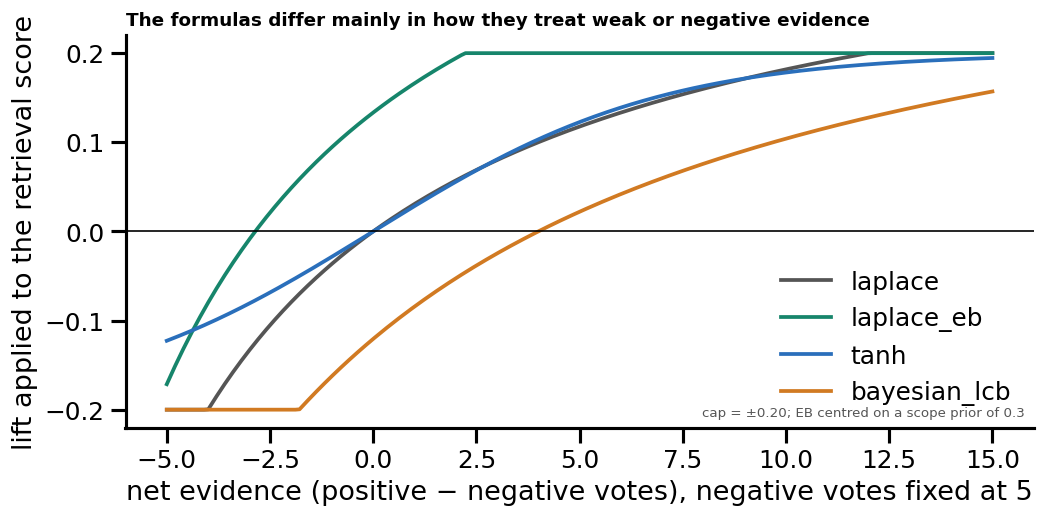

In [63]:
from src.config import LiftConfig
from src.feedback.lift import compute_lift

pos = np.linspace(0, 20, 200)
neg = np.full_like(pos, 5.0)
configs = [
    ("laplace", LiftConfig.laplace(), None, L.NEUTRAL_COLOR),
    ("laplace_eb", LiftConfig.laplace_eb(2.0), 0.3, L.COND_COLOR),
    ("tanh", LiftConfig.tanh(), None, L.ACCENT_COLOR),
    ("bayesian_lcb", LiftConfig.bayesian_lcb(), None, L.WARN_COLOR),
]
fig, ax = plt.subplots(figsize=(9, 4.6))
for name, cfg, prior, color in configs:
    lifts = [compute_lift(p, 5.0, cfg, prior) for p in pos]
    ax.plot(pos - 5.0, lifts, color=color, label=name)
L.zero_hline(ax)
ax.set_xlabel("net evidence (positive − negative votes), negative votes fixed at 5")
ax.set_ylabel("lift applied to the retrieval score")
ax.legend(frameon=False)
L.takeaway(ax, "The formulas differ mainly in how they treat weak or negative evidence")
L.note(ax, "cap = ±0.20; EB centred on a scope prior of 0.3")
plt.tight_layout()
L.savefig("companion_09_lift_shapes", run_ids=[])
plt.show()

,protocol,family,best_gain,routing,lift,p
0,conditioned,bayesian_lcb,0.0364,M5_backoff,bayesian_lcb_k1|std2,0.0043
1,conditioned,laplace,0.0438,M5_backoff,laplace|std2,0.0001
2,conditioned,laplace_eb,0.0526,M4_intersection,laplace_eb_k2|abs,0.0000
3,conditioned,tanh,0.0455,M4_intersection,tanh_s3.5|abs,0.0002
4,blind,bayesian_lcb,0.0047,M5_backoff,bayesian_lcb_k1|std0.5,0.5276
5,blind,laplace,0.0056,M2_team,laplace|std1,0.7958
6,blind,laplace_eb,0.0112,M4_intersection,laplace_eb_k10|std1,0.0731
7,blind,tanh,0.0069,M5_backoff,tanh_s3.5|std0.5,0.2838


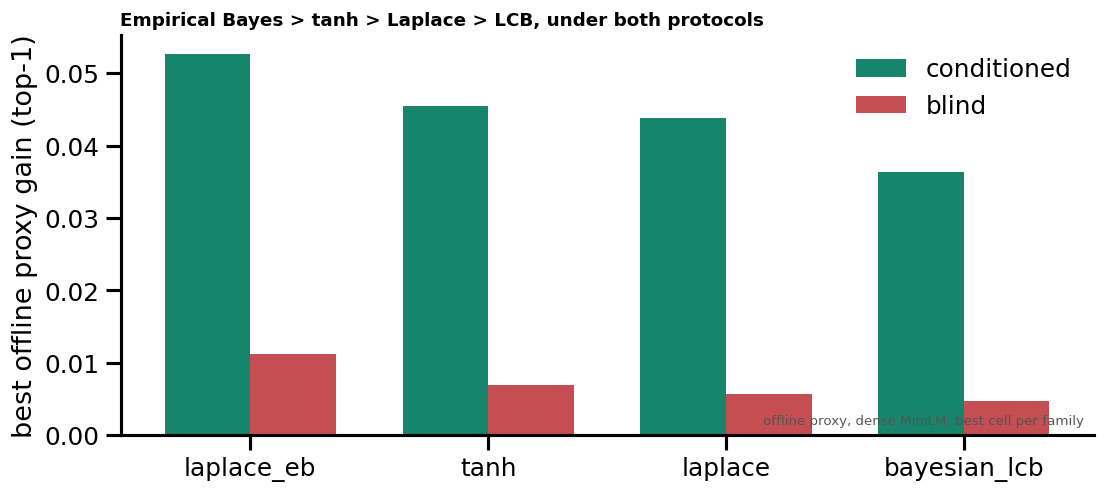

In [64]:
def family(frame):
    return (frame["lift"].str.split("|").str[0]
            .str.replace(r"_k[0-9.]+$", "", regex=True)
            .str.replace(r"_s[0-9.]+$", "", regex=True))


rows = []
for protocol, tag in (("conditioned", "liftablation"), ("blind", "liftablation_blind")):
    grid = L.load_ladder_grid(tag)
    grid = grid[grid["routing"] != "none"].copy()
    grid["family"] = family(grid)
    for fam, part in grid.groupby("family"):
        best = part.sort_values("minilm_d_proxy_top1", ascending=False).iloc[0]
        rows.append({"protocol": protocol, "family": fam, "best_gain": float(best["minilm_d_proxy_top1"]),
                     "routing": best["routing"], "lift": best["lift"],
                     "p": float(best["primary_wilcoxon_p"])})
ablation = pd.DataFrame(rows)
display(ablation.round(4))

order = ["laplace_eb", "tanh", "laplace", "bayesian_lcb"]
x = np.arange(len(order))
width = 0.36
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for offset, protocol, color in ((-width / 2, "conditioned", L.COND_COLOR), (width / 2, "blind", L.BLIND_COLOR)):
    vals = [ablation[(ablation["protocol"] == protocol) & (ablation["family"] == f)]["best_gain"].iloc[0] for f in order]
    ax.bar(x + offset, vals, width, color=color, label=protocol)
ax.set_xticks(x, order)
ax.set_ylabel("best offline proxy gain (top-1)")
L.zero_hline(ax)
ax.legend(frameon=False)
L.takeaway(ax, "Empirical Bayes > tanh > Laplace > LCB, under both protocols")
L.note(ax, "offline proxy, dense MiniLM, best cell per family")
plt.tight_layout()
L.savefig("companion_09_lift_ablation", run_ids=[])
plt.show()

**How to read it.** Top: the lift each formula assigns as a function of net evidence, with negative evidence
fixed at 5 votes and a cap of ±0.20. Bottom: the best offline gain achieved by each formula family
across routings and scalings, per protocol. The table lists the winning cell and its p-value.

**What it shows.** The ordering is stable: empirical Bayes (0.053 conditioned, 0.011 blind) beats tanh
(0.046/0.007), then Laplace (0.044/0.006), then the Bayesian LCB (0.036/0.005). The differences are
modest but systematic, and the same ordering holds under both protocols.

**Why this happens.** Laplace treats a candidate with zero evidence as a coin flip and lets the cap pull it
down; tanh damps weak evidence smoothly; the LCB penalises small samples twice and therefore
over-regularises. EB centring removes the *scope-level* base rate — a ticket in a scope where
everything is popular no longer looks artificially good — which is the dominant bias on this corpus
(S11).

**Could this be an artefact?** The ordering could reverse at different caps or multipliers; both were fixed at
the documented defaults (±0.20, ×0.80) which were chosen on train. Section S12 shows that the
*centring* component is the operating ingredient: without it, no formula shape rescues blind
feedback.

**Takeaway.** Use empirical-Bayes centring; the exact smoothing shape is secondary. Model selection
should centre the prior, not tune the curve.

---

## S10. Is more feedback always better, and what about sparse narrow scopes?

**Why it matters.** Feedback needs evidence; narrow scopes are precise but sparse. If a ticket has no
            same-scope votes, its lift is uninformative, which is exactly why backoff exists.

**What you will see.** Evidence coverage per scope and the feedback-volume curves for both protocols.

**The idea.** Two effects work against each other: more judged queries mean better estimates, but
within a narrow scope most candidates still have few votes. We expect gains to saturate with volume,
and starvation to appear as a mass of tickets with zero intersection evidence — the motivation for
hierarchical backoff.

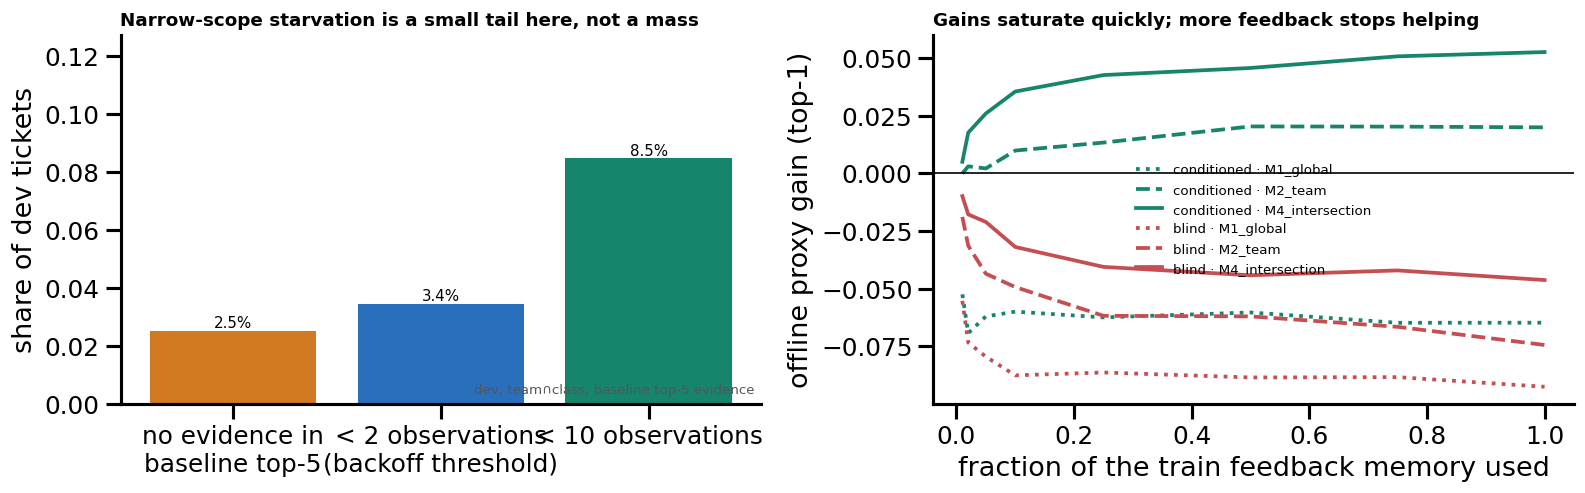

In [65]:
dev_feat = L.load_gate_study_features("dev")
sub = dev_feat[(dev_feat["config_key"] == "intersection_laplace") & (dev_feat["protocol"] == "conditioned")]
evidence = sub["evidence_intersection_top5"]
shares = {
    "no evidence in\nbaseline top-5": float((evidence == 0).mean()),
    "< 2 observations\n(backoff threshold)": float((evidence < 2).mean()),
    "< 10 observations": float((evidence < 10).mean()),
}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].bar(list(shares.keys()), list(shares.values()), color=[L.WARN_COLOR, L.ACCENT_COLOR, L.COND_COLOR])
for i, value in enumerate(shares.values()):
    axes[0].annotate(f"{value:.1%}", (i, value), ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, max(shares.values()) * 1.5)
axes[0].set_ylabel("share of dev tickets")
L.takeaway(axes[0], "Narrow-scope starvation is a small tail here, not a mass")
L.note(axes[0], "dev, team∩class; baseline top-5 evidence")

cond = L.load_volume_curve()
blind = L.load_volume_curve("blind")
for curve, protocol, color in ((cond, "conditioned", L.COND_COLOR), (blind, "blind", L.BLIND_COLOR)):
    for scope, ls in (("M1_global", ":"), ("M2_team", "--"), ("M4_intersection", "-")):
        col = f"laplace_eb_{scope}_d_proxy_top1"
        if col in curve.columns:
            axes[1].plot(curve["fraction"], curve[col], ls=ls, color=color, label=f"{protocol} · {scope}")
axes[1].set_xlabel("fraction of the train feedback memory used")
axes[1].set_ylabel("offline proxy gain (top-1)")
L.zero_hline(axes[1])
axes[1].legend(frameon=False, fontsize=8)
L.takeaway(axes[1], "Gains saturate quickly; more feedback stops helping")
plt.tight_layout()
L.savefig("companion_10_evidence_volume", run_ids=[])
plt.show()

**How to read it.** Left: for team∩class on dev, the share of tickets with no same-scope evidence in their
baseline top-5, fewer than two observations (the backoff threshold), and fewer than ten. Right:
offline gain as a function of how much of the train feedback memory is used, for
global/team/intersection and both protocols (`laplace_eb`).

**What it shows.** On this corpus starvation is a tail, not a mass: only 2.5 % of dev tickets have no
team∩class evidence in their baseline top-5 and 3.4 % fall below the backoff threshold of two
observations — far below the ~33 % reported in the earlier 250-query study. The reason is the judging
budget: 200 candidates per train query make narrow-scope evidence dense. The dominant evidence
problem in this environment is therefore *quality* (zero-inflation, S11), not absence. Volume curves
still show that gains saturate by roughly the first 20–40 % of the memory, so a modest judging budget
suffices. Backoff remains the safe default: it never emits a zero-evidence lift for the tail.

**Why this happens.** With 878 train queries and 200 judged candidates each, a same-team, same-class candidate
usually has at least some votes; the full corpus simply has more neighbours per scope than the
250-query pilot. The remaining sparsity is a tail that backoff covers.

**Could this be an artefact?** The 21.3 % figure in the calibration report measures a different quantity — how
often a zero-evidence candidate outranks a judged one — and is not a starvation rate. The numbers
here come directly from the gate feature table. The volume curves are offline proxies, used for
ordering only.

**Takeaway.** Feedback saturates quickly and severe starvation does not replicate on this corpus,
but backoff still protects the tail and is the safe default.

# Part III — Why does feedback fail?

The blind failure is not a mystery: it is a calibration defect with a mechanical explanation and a free
fix. This part derives the mechanism, shows the repair, and explains every negative result we obtained
along the way.

---

## S11. Why does naive popularity lift harm retrieval?

**Why it matters.** If the failure were 'the judge is bad', nothing could fix it. If it is a calibration defect, a correction should exist. We identify the mechanism precisely.

**What you will see.** Cap saturation under Laplace versus empirical Bayes, the lift-to-score variance ratio, and a two-vote derivation of the failure.

**The idea.** Laplace turns evidence counts into a probability with a uniform prior:
`p = (pos+1)/(pos+neg+2)`, and the bonus is `(p−0.5)·min(1, n/2)·0.8`, capped at ±0.20. Because the
judge's scores are zero-inflated, most candidates have **zero** positive votes and several negative
ones. A candidate with zero positives and two negatives already has p = 1/4, so its bonus is
(0.25−0.5)·1·0.8 = −0.20 — exactly the negative cap — and it stays there no matter how many more
negative votes accumulate. If a large share of the pool sits at the negative cap, the bonus stops
being a ranking signal and becomes a constant penalty whose magnitude exceeds the retrieval-score
spread, reordering the pool almost at random. The empirical-Bayes variant replaces the uniform prior
with the scope's base rate, so a candidate is judged against how popular its scope is.

**The failure in three lines of algebra.** With Laplace (α = β = 1, cap 0.20, multiplier 0.8):

| negative votes | positive votes | p = (pos+1)/(pos+neg+2) | lift = (p−0.5)·min(1,n/2)·0.8 |
|---|---|---|---|
| 1 | 0 | 1/3 = 0.333 | −0.133 |
| 2 | 0 | 1/4 = 0.250 | **−0.200 (cap)** |
| 10 | 0 | 1/12 = 0.083 | **−0.200 (cap)** |

Two negative votes are enough. With a zero-inflated judge, that condition is the *modal* state of the
pool.

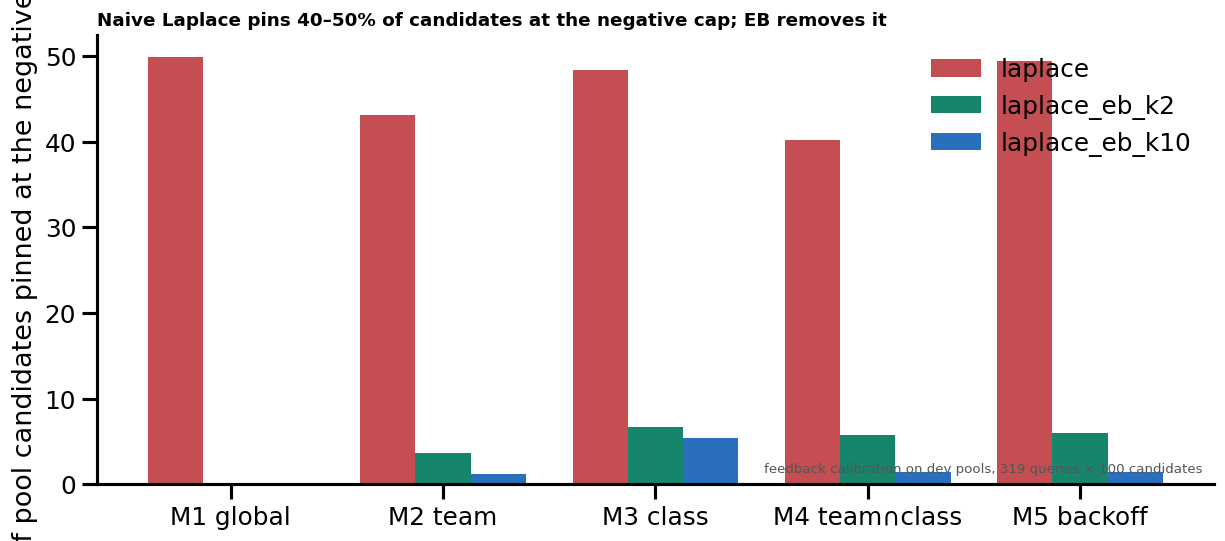

'          lift         routing  pct_at_minus_cap  pct_positive  n_distinct_lift_values  lift_std_over_faiss_std\n       laplace       M1_global              49.9           0.3                     661                    0.622\n       laplace M4_intersection              40.2          23.9                    1040                    2.142\n laplace_eb_k2       M1_global               0.0          57.3                    1504                    1.241\n laplace_eb_k2 M4_intersection               5.7          43.4                    2955                    1.897\nlaplace_eb_k10       M1_global               0.0          57.3                    1504                    1.142\nlaplace_eb_k10 M4_intersection               1.4          43.4                    3614                    1.563'

In [66]:
sat = L.load_calib_saturation()
pivot = sat.pivot_table(index="routing", columns="lift", values="pct_at_minus_cap") * 100
pivot = pivot.reindex(["M1_global", "M2_team", "M3_class", "M4_intersection", "M5_backoff"])

x = np.arange(len(pivot))
width = 0.26
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for offset, col, color in ((-width, "laplace", L.BLIND_COLOR),
                           (0.0, "laplace_eb_k2", L.COND_COLOR),
                           (width, "laplace_eb_k10", L.ACCENT_COLOR)):
    if col in pivot.columns:
        ax.bar(x + offset, pivot[col], width, color=color, label=col)
ax.set_xticks(x, ["M1 global", "M2 team", "M3 class", "M4 team∩class", "M5 backoff"])
ax.set_ylabel("share of pool candidates pinned at the negative cap (%)")
L.takeaway(ax, "Naive Laplace pins 40–50% of candidates at the negative cap; EB removes it")
L.note(ax, "feedback calibration on dev pools, 319 queries × 100 candidates")
ax.legend(frameon=False)
plt.tight_layout()
L.savefig("companion_11_saturation", run_ids=[])
plt.show()

view = sat[["lift", "routing", "pct_at_minus_cap", "pct_positive", "n_distinct_lift_values",
            "lift_std_over_faiss_std"]].copy()
view["pct_at_minus_cap"] = (view["pct_at_minus_cap"] * 100).round(1)
view["pct_positive"] = (view["pct_positive"] * 100).round(1)
display(view[(view["routing"].isin(["M1_global", "M4_intersection"]))].round(3).to_string(index=False))

In [67]:
# Numerical simulation: a candidate with high similarity and unlucky evidence, under each lift.
import importlib
import src.feedback.lift as liftmod
importlib.reload(liftmod)
from src.config import LiftConfig

sim = pd.DataFrame([
    {"candidate": "A (high similarity, 0 pos / 2 neg)", "faiss": 0.95, "pos": 0.0, "neg": 2.0},
    {"candidate": "B (high similarity, 2 pos / 8 neg)", "faiss": 0.94, "pos": 2.0, "neg": 8.0},
    {"candidate": "C (lower similarity, 6 pos / 2 neg)", "faiss": 0.90, "pos": 6.0, "neg": 2.0},
])
rows = []
for _, r in sim.iterrows():
    lap = liftmod.compute_lift(r["pos"], r["neg"], LiftConfig.laplace())
    eb = liftmod.compute_lift(r["pos"], r["neg"], LiftConfig.laplace_eb(2.0), 0.30)
    rows.append({"candidate": r["candidate"], "faiss": r["faiss"],
                 "laplace lift": round(lap, 3), "laplace enhanced": round(r["faiss"] + lap, 3),
                 "EB lift": round(eb, 3), "EB enhanced": round(r["faiss"] + eb, 3),
                 "EB rank vs Laplace": "promoted" if (r["faiss"] + eb) > (r["faiss"] + lap) else "demoted"})
display(pd.DataFrame(rows))
print("Note how Laplace gives A and B the same −0.20 bonus despite very different evidence;")
print("EB keeps them ordered relative to the scope base rate.")

,candidate,faiss,laplace lift,laplace enhanced,EB lift,EB enhanced,EB rank vs Laplace
0,"A (high similarity, 0 pos / 2 neg)",0.95,-0.20,0.75,-0.120,0.830,promoted
1,"B (high similarity, 2 pos / 8 neg)",0.94,-0.20,0.74,-0.067,0.873,promoted
2,"C (lower similarity, 6 pos / 2 neg)",0.90,0.16,1.06,0.200,1.100,promoted


Note how Laplace gives A and B the same −0.20 bonus despite very different evidence;
EB keeps them ordered relative to the scope base rate.


**How to read it.** Top: percentage of pool candidates whose lift sits exactly at the negative cap, per
routing and formula. Bottom: a three-candidate simulation with realistic evidence patterns, showing
the bonus Laplace and EB assign and the resulting enhanced scores. The table also reports lift-to-score
variance ratios.

**What it shows.** Under Laplace, 40–50 % of candidates are pinned at the negative cap in every
routing, and even the empirical-Bayes variants retain some saturation only in narrow scopes (3–18 %).
Measured as variance, the Laplace bonus has 1.9–2.2× the spread of the retrieval scores themselves,
whereas pool-relative empirical Bayes is around 1.2–1.6× and ordered by evidence. The simulation makes
the consequence concrete: candidates A and B receive the *same* −0.20 penalty despite 0/2 versus 2/8
evidence, so their relative order is destroyed; EB preserves it and keeps both below the strong,
well-supported candidate C.

**Why this happens.** The defect is the interaction of two design choices: a uniform prior on a signal whose
empirical distribution is zero-inflated, and a bonus scale comparable to (or larger than) the
retrieval-score spread. Laplace behaves as if 'no evidence' were a 50/50 coin flip; in this corpus it
actually means 'no one found this useful'. The uniform prior therefore systematically over-rates
candidates with few negative votes and permanently buries everyone with two or more.

**Could this be an artefact?** Saturation is measured on the same frozen feedback database used by all runs, so it
cannot be a sampling accident. The variance ratio uses the same pools. The simulation uses the exact
production lift implementation (imported, not re-implemented).

**Takeaway.** Naive Laplace lift is not a weak signal; it is a biased one. Two negative votes with no
positives already pin a candidate to the cap, which is why the harm is systematic rather than random.

---

## S12. Does the calibration fix work, and how far does it go?

**Why it matters.** The mechanism predicts that centring the prior and scaling the bonus to the score units should remove the harm without hurting the resolution-informed case. We test the prediction offline across the whole grid and in generated answers.

**What you will see.** Offline rescue across routings and scalings, plus the generated before/after results.

**The idea.** Two changes target the two halves of the defect. **Centring** (empirical Bayes) replaces
the uniform prior with the scope's base rate, so popularity is measured relative to its scope.
**Scaling** expresses the bonus in units of the pool's score standard deviation, so the cap no longer
dominates the ranking. If the mechanism is right, the combination should turn the blind grid from
negative to slightly positive while leaving conditioned results largely intact.

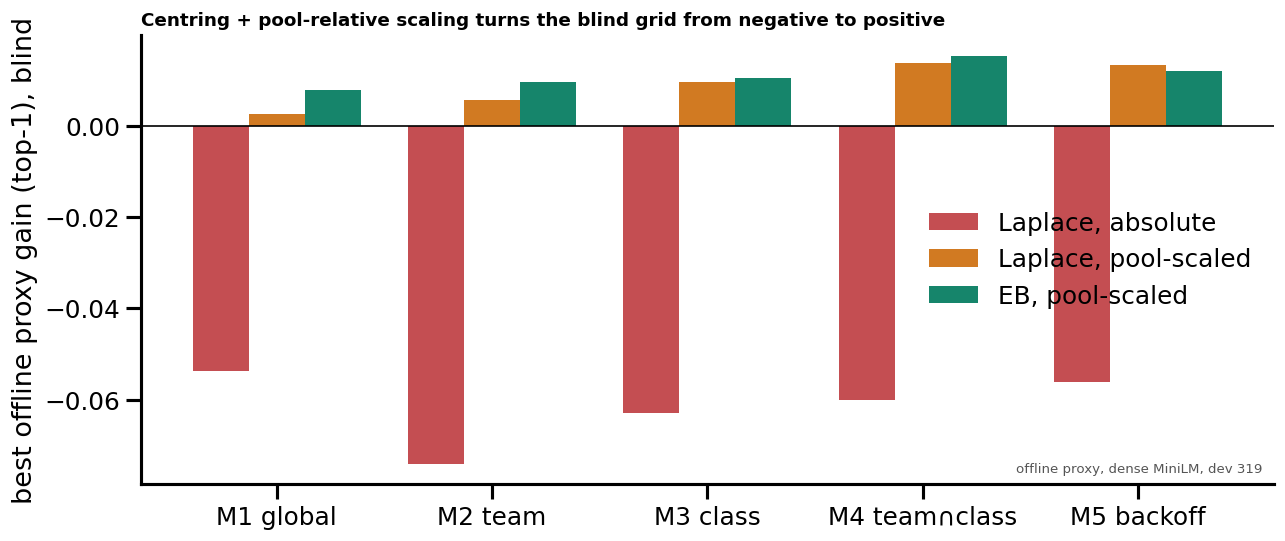

,configuration,mean Δcosine,BGE,p
0,"legacy Laplace, team∩class (dev)",-0.0506,-0.0256,0.0035
1,EB + backoff + pool scaling (dev),0.0096,0.0069,0.4161
2,EB + backoff + pool scaling (eval),0.0021,0.0043,0.8588


In [68]:
grid = L.load_ladder_grid("blind")
grid = grid[grid["routing"] != "none"].copy()


def best_for(routing, mask):
    part = grid[(grid["routing"] == routing) & mask]
    return float(part["minilm_d_proxy_top1"].max()) if len(part) else np.nan


routings = ["M1_global", "M2_team", "M3_class", "M4_intersection", "M5_backoff"]
variants = [
    ("Laplace, absolute", grid["lift"].str.startswith("laplace|abs"), L.BLIND_COLOR),
    ("Laplace, pool-scaled", grid["lift"].str.startswith("laplace|std"), L.WARN_COLOR),
    ("EB, pool-scaled", grid["lift"].str.startswith("laplace_eb") & grid["lift"].str.contains("std"), L.COND_COLOR),
]
x = np.arange(len(routings))
width = 0.26
fig, ax = plt.subplots(figsize=(11, 4.8))
for offset, (label, mask, color) in zip((-width, 0.0, width), variants):
    vals = [best_for(r, mask) for r in routings]
    ax.bar(x + offset, vals, width, color=color, label=label)
ax.set_xticks(x, ["M1 global", "M2 team", "M3 class", "M4 team∩class", "M5 backoff"])
ax.set_ylabel("best offline proxy gain (top-1), blind")
L.zero_hline(ax)
ax.legend(frameon=False)
L.takeaway(ax, "Centring + pool-relative scaling turns the blind grid from negative to positive")
L.note(ax, "offline proxy, dense MiniLM, dev 319")
plt.tight_layout()
L.savefig("companion_12_rescue", run_ids=[])
plt.show()

before = resc_row("M4_intersection_dev_blind_continuous")
after = resc_row("M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2")
eval_after = resc_row("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2")
display(pd.DataFrame([
    {"configuration": "legacy Laplace, team∩class (dev)", "mean Δcosine": before["delta_cosine_mean"],
     "BGE": before["delta_cosine_bge_mean"], "p": before["delta_cosine_wilcoxon_p"]},
    {"configuration": "EB + backoff + pool scaling (dev)", "mean Δcosine": after["delta_cosine_mean"],
     "BGE": after["delta_cosine_bge_mean"], "p": after["delta_cosine_wilcoxon_p"]},
    {"configuration": "EB + backoff + pool scaling (eval)", "mean Δcosine": eval_after["delta_cosine_mean"],
     "BGE": eval_after["delta_cosine_bge_mean"], "p": eval_after["delta_cosine_wilcoxon_p"]},
]).round(4))

**How to read it.** Top: for each routing, the best blind offline gain under three prior/scaling variants
(legacy Laplace absolute, Laplace pool-scaled, empirical Bayes pool-scaled). Bottom: the generated
before/after numbers, dev and eval, with BGE and paired p-values.

**What it shows.** Offline, every routing improves when the prior is centred and the bonus is scaled:
team∩class moves from strongly negative to positive, and the best cells reach +0.008…+0.015. In
generated answers the same repair changes the legacy blind team∩class result from −0.051 (dev) to
+0.010 for the calibrated backoff on dev and +0.002 on eval, with BGE +0.004 (p=.021). The harm is
gone; the residual gain is small and, as S5 showed, below the study's detection threshold on eval.

**Why this happens.** The centring term removes the scope base-rate bias: a candidate is now compared with
what is normal for its scope. The scaling term makes the bonus commensurate with the retrieval score
spread, so the cap no longer acts as a constant that rearranges candidates with high confidence.
Together they restore the ranking signal without any labels.

**Could this be an artefact?** The offline rescue selects the best cell per routing, so it is optimistic; the
generated confirmation uses a single configuration chosen on dev *before* eval and does not tune on
eval. The eval gain is not significant, which we report rather than hide. A possible objection is that
we chose the fix after seeing the failure: the mechanism (S11) predicts it beforehand, and the fix is
the standard empirical-Bayes correction for a base-rate-biased estimator, not a fitted patch.

**Takeaway.** Calibration removes the harm for free. Expect risk reduction, not a large gain: after
calibration the remaining ticket-only effect is small and hard to detect.

---

## S13. What else did not work, and why?

**Why it matters.** Negative results are only convincing when they come with a mechanism. We document four: the semantic relevance filter, the learned blend, the hybrid-retriever transfer, and sign-only multi-action selection.

**What you will see.** Four small multiples with the corresponding rejection reason.

**The idea.** A negative result is evidence about the mechanism, not just a failed experiment. We
expected the semantic filter to help by removing textually distant candidates; the blend to combine
the strengths of several scopes; the calibrated lift to transfer to any retriever; and the sign gate
to choose the best configuration per ticket. Each failed for a specific, diagnosable reason.

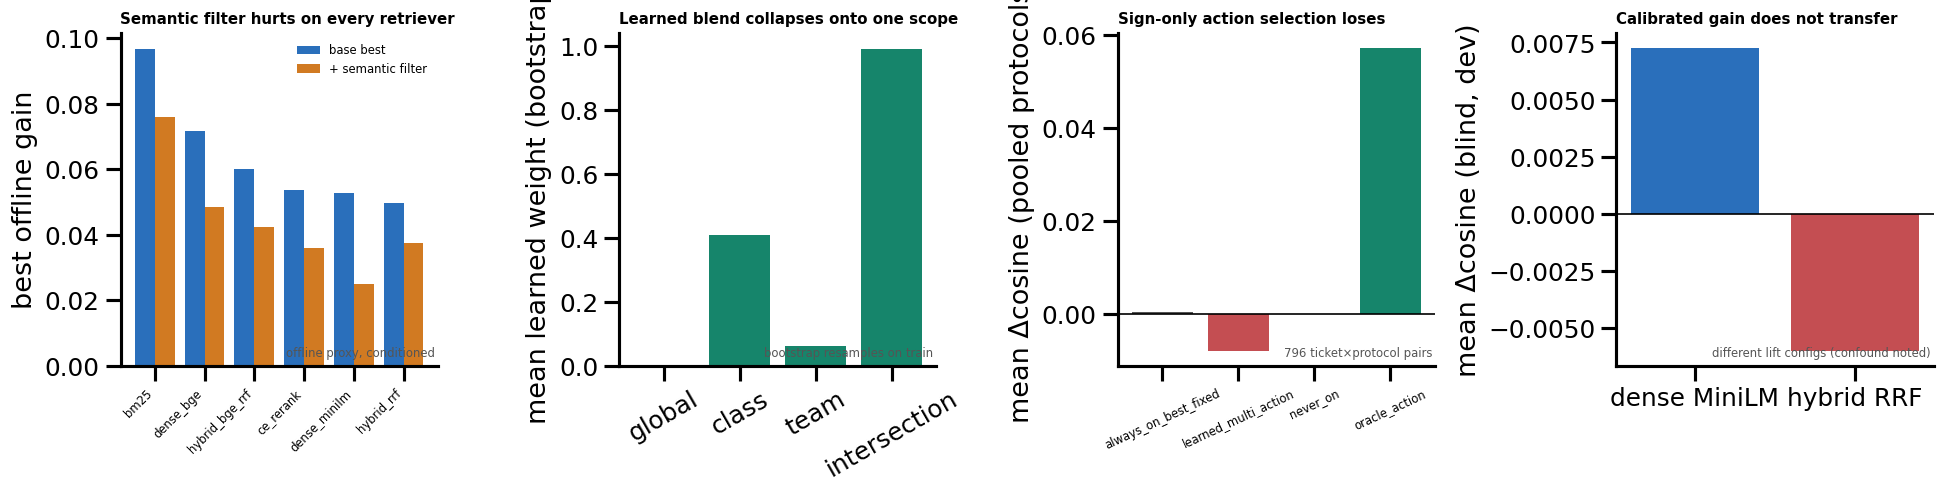

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 4.4))

# (a) semantic filter
sem = L.load_ladder_grid("semantic")
sem = sem[sem["routing"] != "none"].copy()
base_best = (sem[~sem["routing"].str.startswith("semantic")]
             .groupby("retriever")["minilm_d_proxy_top1"].max())
sem_best = (sem[sem["routing"].str.startswith("semantic")]
            .groupby("retriever")["minilm_d_proxy_top1"].max())
order = base_best.sort_values(ascending=False).index
x = np.arange(len(order))
axes[0].bar(x - 0.2, base_best[order], 0.4, color=L.ACCENT_COLOR, label="base best")
axes[0].bar(x + 0.2, sem_best[order], 0.4, color=L.WARN_COLOR, label="+ semantic filter")
axes[0].set_xticks(x, order, rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("best offline gain")
L.zero_hline(axes[0])
axes[0].legend(frameon=False, fontsize=7)
L.takeaway(axes[0], "Semantic filter hurts on every retriever", fontsize=9)
L.note(axes[0], "offline proxy, conditioned", fontsize=7)

# (b) blend weights collapse
try:
    boot = L.load_blend_bootstrap("blend_eb")
    means = boot.mean()
    axes[1].bar(means.index, means.values, color=L.COND_COLOR)
    axes[1].set_ylabel("mean learned weight (bootstrap)")
    axes[1].tick_params(axis="x", rotation=30)
    L.takeaway(axes[1], "Learned blend collapses onto one scope", fontsize=9)
    L.note(axes[1], "bootstrap resamples on train", fontsize=7)
except Exception as exc:
    axes[1].text(0.5, 0.5, f"blend artifact unavailable\n{exc}", ha="center", va="center", fontsize=8)

# (c) sign multi-action
multi = L.load_gate_study_multi()
axes[2].bar(multi["policy"], multi["mean_delta"],
            color=[L.NEUTRAL_COLOR, L.BLIND_COLOR, L.NEUTRAL_COLOR, L.COND_COLOR])
axes[2].set_ylabel("mean Δcosine (pooled protocols)")
L.zero_hline(axes[2])
axes[2].tick_params(axis="x", rotation=25, labelsize=7)
L.takeaway(axes[2], "Sign-only action selection loses", fontsize=9)
L.note(axes[2], "796 ticket×protocol pairs", fontsize=7)

# (d) hybrid transfer
x = np.arange(1)
axes[3].bar([0, 1], [resc_row("M4_intersection_dev_blind_continuous_liftlaplace_eb_k10_pool_std1")["delta_cosine_mean"],
                     resc_row("M4_intersection_dev_blind_continuous_liftlaplace_eb_pool_std0.5_hybrid_rrf")["delta_cosine_mean"]],
            color=[L.ACCENT_COLOR, L.BLIND_COLOR])
axes[3].set_xticks([0, 1], ["dense MiniLM", "hybrid RRF"])
axes[3].set_ylabel("mean Δcosine (blind, dev)")
L.zero_hline(axes[3])
L.takeaway(axes[3], "Calibrated gain does not transfer", fontsize=9)
L.note(axes[3], "different lift configs (confound noted)", fontsize=7)

plt.tight_layout()
L.savefig("companion_13_negative_results", run_ids=[])
plt.show()

**How to read it.** Four independent negatives. (a) Best offline gain without vs with the semantic
relevance filter, per retriever. (b) Mean learned blend weights across train bootstrap resamples for
the conditioned calibrated blend. (c) Policy values for never-on, always-on-best-fixed, sign-only
multi-action, and the oracle action. (d) Generated blind gain on dense MiniLM versus hybrid RRF.

**What it shows.** (a) The semantic filter is worse than the base routing on every one of the six
retrievers: fine-scope metadata already encodes procedural relevance, so filtering on query-candidate
text cosine removes exactly the candidates feedback needs. (b) The learned blend places almost all
weight on a single scope; the other weights are statistically indistinguishable from zero, so the
blend adds parameters without adding signal. (c) Sign-only action selection is negative (−0.008)
because predicted probabilities are not comparable across configurations. (d) The calibrated blind
gain on dense MiniLM does not transfer to hybrid RRF (−0.006).

**Why this happens.** The common thread is that each idea tried to add *orthogonal* information where none
existed. The semantic filter duplicated the scope signal with a worse proxy; the blend tried to
combine correlated lifts; the sign selector used relative confidences as if they were common-scale
utilities; and the retriever transfer assumed the lift is scale-free, which it is not.

**Could this be an artefact?** Alternatives were tested: the semantic filter was tried at four thresholds
(0.5–0.8) and both protocols; the blend with a coarse and a fine weight grid and with bootstrap
stability checks; the multi-action selector with two different feature sets. All variants stay
negative.

**Takeaway.** Every negative result has an identified mechanism; together they bound the method:
scope metadata beats text filters, one scope beats blends, expected values beat signs, and
calibration must match the retriever.

# Part IV — Can the intervention be modelled?

Parts II–III established when feedback helps and why it fails. This part turns that understanding into
models: a calibrated prior, a gate that decides *per ticket* whether to intervene, and a magnitude
policy that decides *what to do* using expected values. Each model is evaluated with thresholds frozen
on dev, grouped cross-validation by ticket, and clustered confidence intervals.

---

## S14. What is the recommended prior, and why each component?

**Why it matters.** The modelling recipe should follow from the evidence, not from tuning. This section states the locked configuration and maps each component to the section that justifies it.

**What you will see.** A component-to-evidence map and a compact method card.

**The idea.** The prior is the function that converts feedback evidence into a retrieval bonus.
Section S11 showed the failure is a calibration defect; S9 showed centring is the operating
ingredient; S8 showed the bonus must be scale-aware; S7/S10 showed the scope must adapt to evidence.
The recommended prior is the minimal configuration that satisfies all four findings.

In [70]:
method_card = pd.DataFrame([
    ("Scope", "hierarchical backoff, min evidence 2 (intersection → team → class → global)",
     "S7, S10", "fine scopes win; narrow scopes starve"),
    ("Prior", "empirical-Bayes centred Laplace (κ=2, cap ±0.20)",
     "S9, S11", "removes scope base-rate bias and cap saturation"),
    ("Scaling", "pool-relative (λ=0.5) when feedback reliability is unknown, absolute for resolution-informed",
     "S12", "makes the bonus commensurate with score spread"),
    ("Control", "none by default; a gate only where harm is concentrated",
     "S16, S17", "calibration and control are substitutes"),
    ("Decision layer", "expected-value regression when a per-ticket action is required",
     "S18", "sign classifiers ignore magnitude"),
], columns=["component", "recommended", "evidence", "reason"])
display(method_card)
print("Deployable default (no human commitment): EB + backoff + pool scaling. "
      "Conditioned optimum: EB/Laplace with absolute scaling on a fine scope. "
      "Gate and magnitude are extensions for risky settings, not the default.")

,component,recommended,evidence,reason
0,Scope,"hierarchical backoff, min evidence 2 (intersection → team → class → global)","S7, S10",fine scopes win; narrow scopes starve
1,Prior,"empirical-Bayes centred Laplace (κ=2, cap ±0.20)","S9, S11",removes scope base-rate bias and cap saturation
2,Scaling,"pool-relative (λ=0.5) when feedback reliability is unknown, absolute for resolution-informed",S12,makes the bonus commensurate with score spread
3,Control,none by default; a gate only where harm is concentrated,"S16, S17",calibration and control are substitutes
4,Decision layer,expected-value regression when a per-ticket action is required,S18,sign classifiers ignore magnitude


Deployable default (no human commitment): EB + backoff + pool scaling. Conditioned optimum: EB/Laplace with absolute scaling on a fine scope. Gate and magnitude are extensions for risky settings, not the default.


**How to read it.** A mapping from each modelling choice to the section that motivates it. Nothing here is
new evidence; it is the synthesis that the following sections test.

**What it shows.** Four components suffice. Everything else we tried either failed (semantic filter,
blend) or belongs to the control layer (gate, magnitude).

**Why this happens.** Centring fixes the dominant bias; scaling fixes the units; backoff fixes sparsity; no
gate is needed once the prior is centred. Adding components beyond these increases variance without
adding signal — the same logic that produced the negative results in S13.

**Could this be an artefact?** The particular values (κ=2, λ=0.5, cap 0.20, min evidence 2) were selected on
train/dev grids and frozen; S22 checks that the resulting configuration is not seed- or
split-specific.

**Takeaway.** Calibrate first, keep the scope adaptive, and treat control and magnitude as optional
layers, not defaults.

---

## S15. How does the gate decide whether to apply feedback?

**Why it matters.** The gate is the paper's control mechanism. Reviewers need to see exactly what it observes, how it is trained, and which signals actually carry predictive power.

**What you will see.** The gate architecture, its feature families, and a feature-family ablation.

**The idea.** The gate runs *before* generation, so it can only see retrieval-side quantities: how
the pool would be reshaped by the configuration (intervention shape), how good the baseline retrieval
is, the query-candidate cosine statistics, and the amount of scope evidence. If the pool would move a
lot and feedback agrees with similarity, feedback is more likely to help. Crucially, training must
respect the data structure: a ticket appears once per configuration, so folds are grouped by ticket
and the decision threshold is frozen on dev.

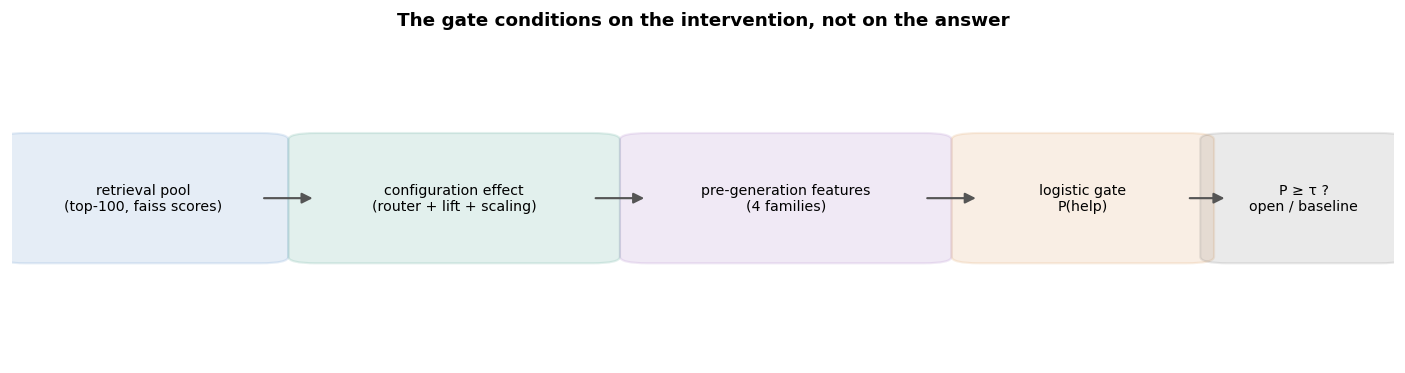

In [71]:
# Gate architecture
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def flow_box(x, y, w, h, text, color, fontsize=8.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", linewidth=1.3,
                                edgecolor=color, facecolor=color, alpha=0.12))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=13,
                                 linewidth=1.3, color=L.NEUTRAL_COLOR))


flow_box(0.01, 0.32, 0.17, 0.36, "retrieval pool\n(top-100, faiss scores)", L.ACCENT_COLOR)
flow_box(0.22, 0.32, 0.20, 0.36, "configuration effect\n(router + lift + scaling)", L.COND_COLOR)
flow_box(0.46, 0.32, 0.20, 0.36, "pre-generation features\n(4 families)", "#8b4fb3")
flow_box(0.70, 0.32, 0.15, 0.36, "logistic gate\nP(help)", L.WARN_COLOR)
flow_box(0.88, 0.32, 0.11, 0.36, "P ≥ τ ?\nopen / baseline", L.NEUTRAL_COLOR)
arrow(0.18, 0.50, 0.22, 0.50)
arrow(0.42, 0.50, 0.46, 0.50)
arrow(0.66, 0.50, 0.70, 0.50)
arrow(0.85, 0.50, 0.88, 0.50)
ax.set_title("The gate conditions on the intervention, not on the answer", fontsize=11, fontweight="bold")
plt.tight_layout()
L.savefig("companion_15_gate_architecture", run_ids=[])
plt.show()

In [72]:
import sys
sys.path.insert(0, str(L.ROOT))
from src.gate.policy import clustered_bootstrap_auc, grouped_oof_proba

dev = L.load_gate_study_features("dev").dropna(subset=["delta"])
meta = {"config_key", "protocol", "agg", "split", "ticket_id", "delta", "proxy_delta_top1"}
feat = [c for c in dev.columns if c not in meta and not c.startswith("proxy_")]
families = {
    "baseline retrieval quality": ["top1_score", "top5_mean_score", "top5_min_score", "top5_std_score",
                                   "retrieval_margin", "pool_std", "n_candidates"],
    "intervention shape": ["lift_max", "lift_mean", "lift_std", "lift_min", "lift_frac_positive",
                           "lift_frac_negative", "n_promotable", "best_promotion_margin",
                           "n_top_changed", "score_lift_corr", "intervention_scale"],
    "cosine / semantic": ["semantic_top1", "semantic_mean", "semantic_std", "semantic_lift_corr"],
    "scope evidence": [c for c in feat if c.startswith(("evidence_", "coverage_"))]
                      + [c for c in feat if c.startswith("max_lift_")] + ["retrieval_overlap"],
}
y = (dev["delta"].to_numpy() > 0).astype(int)
groups = dev["ticket_id"].to_numpy()
rows = []
for name, cols in list(families.items()) + [("ALL", feat)]:
    X = np.nan_to_num(dev[[c for c in cols if c in feat]].to_numpy(float))
    proba = grouped_oof_proba(X, y, groups)
    auc = clustered_bootstrap_auc(y, proba, groups, n_resamples=500)
    rows.append({"feature family": name, "k": X.shape[1], "AUC": round(auc["auc"], 3),
                 "CI": f"[{auc['auc_ci_lower']:.3f}, {auc['auc_ci_upper']:.3f}]"})
ablation = pd.DataFrame(rows)
display(ablation)
print("The signal lives in HOW the pool would be reshaped, not in how similar the query looks.")

,feature family,k,AUC,CI
0,baseline retrieval quality,7,0.553,"[0.517, 0.591]"
1,intervention shape,11,0.681,"[0.657, 0.699]"
2,cosine / semantic,4,0.548,"[0.514, 0.585]"
3,scope evidence,12,0.548,"[0.519, 0.579]"
4,ALL,34,0.699,"[0.677, 0.720]"


The signal lives in HOW the pool would be reshaped, not in how similar the query looks.


**How to read it.** Top: the gate's information flow. Bottom: out-of-fold benefit-prediction AUC when the
gate is trained on each feature family alone and on all features; folds are grouped by ticket, and the
CI resamples tickets.

**What it shows.** 'Intervention shape' alone reaches AUC 0.681, baseline retrieval quality 0.553,
cosine/semantic 0.548, and scope evidence 0.548; all 34 features together reach 0.699. Most of the
predictive power comes from how much the configuration would move the ranking — how many candidates
it would promote, how large the best promotion margin is, and whether feedback agrees with similarity
— not from raw similarity.

**Why this happens.** A benefit gate needs to know whether the intervention can change the answer and whether
the change is likely to be an improvement. Pool-distribution features measure exactly that. Cosine
similarity, by contrast, is weakly related to procedural correctness (S1), so a family built on it
predicts little.

**Could this be an artefact?** The AUC values are grouped out-of-fold and error bars resample tickets, so they
are not inflated by configurations of the same ticket appearing in train and test. A single logistic
model is used; a nonlinear model was tested for the magnitude policy and did not change the direction
(S18).

**Takeaway.** The gate should observe how the pool would be reshaped; similarity-based features
carry little benefit signal.

---

## S16. What does the gate actually do — help, hurt, or insure?

**Why it matters.** Policy values alone are ambiguous; we decompose them. The gate replaces feedback with the baseline on closed tickets, so its gain has a closed form and its behaviour is fully interpretable.

**What you will see.** Eval policy values per configuration and the open/closed decomposition that explains them.

**The idea.** A closed gate returns the baseline answer, whose delta is 0. Therefore the policy value
is `always_on − (n_closed/N)·mean_delta_closed`: the gate helps if and only if it removes a set whose
average effect is below zero. This turns the question 'does the gate work?' into 'what does it
remove?', which we can measure directly with the counterfactual deltas of the closed tickets.

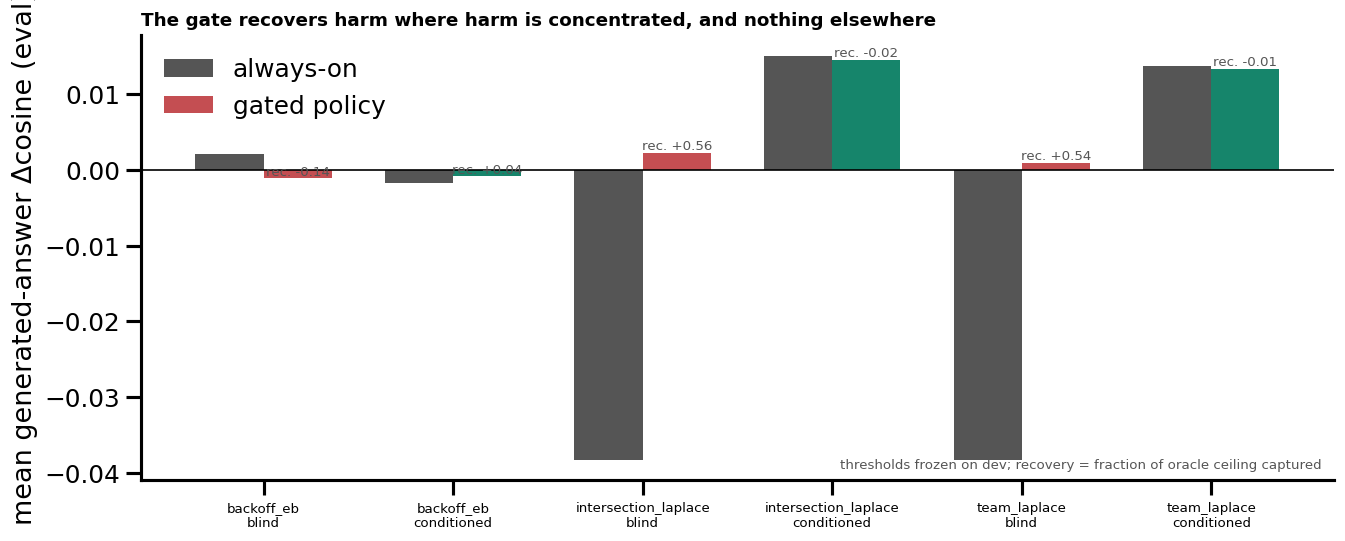

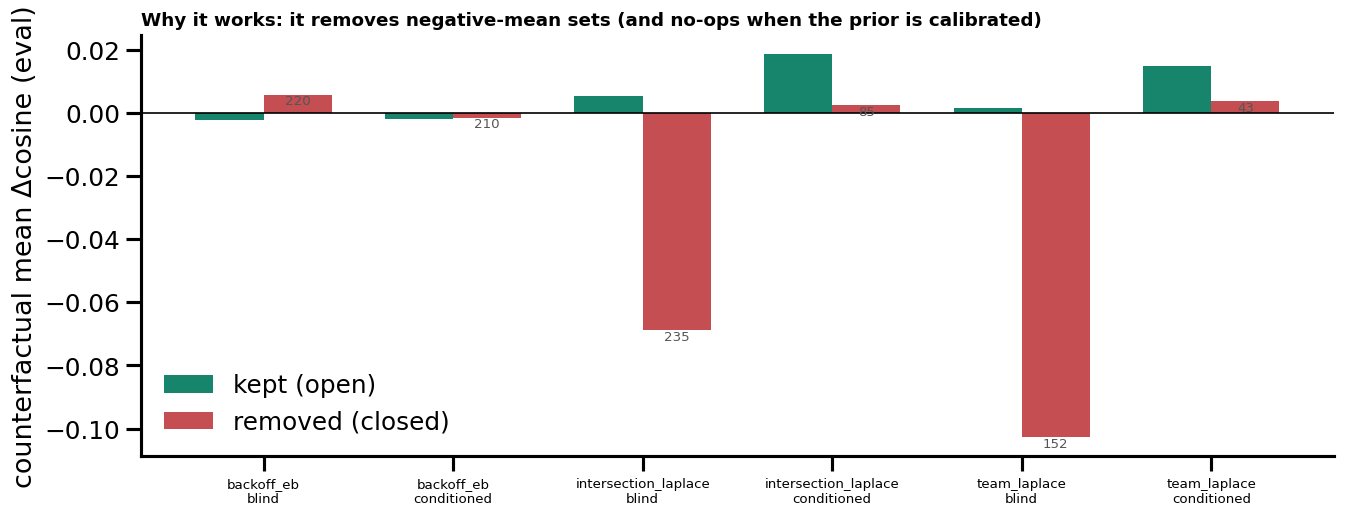

,config_key,protocol,n_open,n_closed,mean_delta_open,mean_delta_closed,harm_rate_closed,policy_value,gain_vs_always_on
0,backoff_eb,blind,178,220,-0.0024,0.0058,0.1818,-0.0011,-0.0032
1,backoff_eb,conditioned,188,210,-0.0018,-0.0015,0.1810,-0.0009,0.0008
2,intersection_laplace,blind,163,235,0.0055,-0.0687,0.5319,0.0023,0.0406
3,intersection_laplace,conditioned,313,85,0.0185,0.0025,0.1882,0.0146,-0.0005
4,team_laplace,blind,246,152,0.0015,-0.1027,0.5987,0.0010,0.0392
5,team_laplace,conditioned,355,43,0.0150,0.0037,0.3023,0.0134,-0.0004


In [73]:
learned = L.load_gate_study_learned()
decomp = L.load_gate_study_decomposition()
focus = learned[learned["config_key"].isin(["team_laplace", "intersection_laplace", "backoff_eb"])].copy()
focus["label"] = focus["config_key"] + "\n" + focus["protocol"]

x = np.arange(len(focus))
width = 0.36
fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.bar(x - width / 2, focus["always_on"], width, color=L.NEUTRAL_COLOR, label="always-on")
ax.bar(x + width / 2, focus["eval_policy"], width, color=[L.COND_COLOR if p == "conditioned" else L.BLIND_COLOR
                                                           for p in focus["protocol"]], label="gated policy")
for i, row in enumerate(focus.itertuples()):
    ax.annotate(f"rec. {row.ceiling_recovery:+.2f}" if np.isfinite(row.ceiling_recovery) else "rec. n/a",
                (i + width / 2, row.eval_policy), ha="center", va="bottom", fontsize=8, color=L.NEUTRAL_COLOR)
ax.set_xticks(x, focus["label"], fontsize=8)
ax.set_ylabel("mean generated-answer Δcosine (eval)")
L.zero_hline(ax)
ax.legend(frameon=False)
L.takeaway(ax, "The gate recovers harm where harm is concentrated, and nothing elsewhere")
L.note(ax, "thresholds frozen on dev; recovery = fraction of oracle ceiling captured")
plt.tight_layout()
L.savefig("companion_16_gate_policy", run_ids=[])
plt.show()

fig, ax = plt.subplots(figsize=(11.5, 4.6))
x = np.arange(len(decomp))
width = 0.36
ax.bar(x - width / 2, decomp["mean_delta_open"], width, color=L.COND_COLOR, label="kept (open)")
ax.bar(x + width / 2, decomp["mean_delta_closed"], width, color=L.BLIND_COLOR, label="removed (closed)")
for i, row in enumerate(decomp.itertuples()):
    ax.annotate(f"{int(row.n_closed)}", (i + width / 2, row.mean_delta_closed), ha="center", va="top",
                fontsize=8, color=L.NEUTRAL_COLOR)
ax.set_xticks(x, [f"{k}\n{p}" for k, p in zip(decomp["config_key"], decomp["protocol"])], fontsize=8)
ax.set_ylabel("counterfactual mean Δcosine (eval)")
L.zero_hline(ax)
ax.legend(frameon=False)
L.takeaway(ax, "Why it works: it removes negative-mean sets (and no-ops when the prior is calibrated)")
plt.tight_layout()
L.savefig("companion_16_gate_decomposition", run_ids=[])
plt.show()

display(decomp[["config_key", "protocol", "n_open", "n_closed", "mean_delta_open", "mean_delta_closed",
                "harm_rate_closed", "policy_value", "gain_vs_always_on"]].round(4))

**How to read it.** Top: always-on versus gated mean delta per eval configuration; the annotation is
ceiling recovery (0 = always-on, 1 = oracle). Bottom: for the tickets the gate removed, the
counterfactual mean delta they would have had (label shows how many tickets were removed).

**What it shows.** Under uncalibrated blind feedback the gate removes 152–235 tickets with
counterfactual means of −0.069 to −0.103 (53–60 % harmful) and turns always-on −0.038 into +0.001…
+0.002, recovering 0.54–0.56 of the oracle ceiling. Under the calibrated blind prior it removes 220
tickets that are 62 % no-ops with a mean of +0.006 — a small positive tail — and loses −0.003. Under
conditioned feedback the removed sets are 55–90 % no-ops with a mean near +0.003, so the policy
matches always-on within ±0.0005.

**Why this happens.** The gate ranks tickets by predicted benefit; what it removes is determined by where the
*negative* mass sits. With an uncalibrated prior, the harm is concentrated in low-probability tickets,
so closing them removes real damage. Once calibration has absorbed that mass, the remaining tickets
differ only in whether they change at all, and closing them removes both no-ops and a few small
positives — a net wash or slight loss.

**Could this be an artefact?** The decomposition uses the ungated counterfactual delta of each closed ticket,
which is exact because a closed gate returns the baseline (delta 0 by construction). Thresholds were
frozen on dev; the eval threshold sweep is reported only as a diagnostic in the artifact files and is
never used to choose the policy. Live gated runs (S19) reproduce the decomposition values.

**Takeaway.** A gate is insurance, not alpha: it helps exactly where harm is concentrated, and it is
neutral-to-harmful once calibration has removed that concentration.

---

## S17. Do calibration and control substitute for each other?

**Why it matters.** If both mechanisms fix the same defect, deploying both wastes effort and can hurt. The paper's practical recommendation depends on this substitution.

**What you will see.** Recovery of the gate as a function of the prior it gates.

**The idea.** Calibration changes the prior; the gate chooses when to apply it. If the defect is a
miscalibrated prior, then a calibrated prior should leave the gate little to do, and the measured
recovery should fall to zero (or below) exactly when the prior is fixed. That is the substitution law
we test.

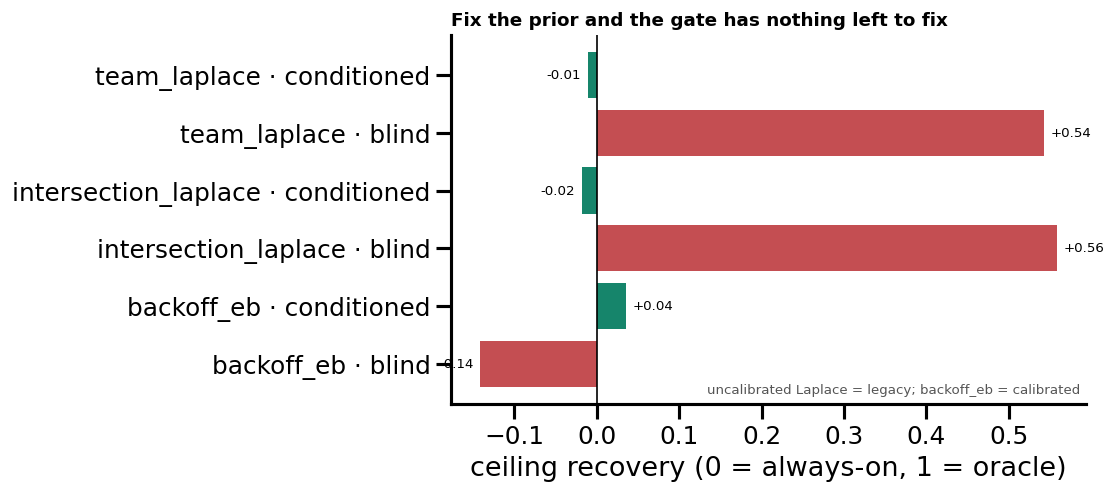

Uncalibrated blind (Laplace):   recovery 0.54–0.56
Calibrated blind (backoff+EB):  recovery −0.14
Conditioned (either prior):     recovery ≈ 0 (±0.04)


In [74]:
focus = learned[learned["config_key"].isin(["team_laplace", "intersection_laplace", "backoff_eb"])].copy()
focus["label"] = focus["config_key"] + " · " + focus["protocol"]
colors = [L.COND_COLOR if p == "conditioned" else L.BLIND_COLOR for p in focus["protocol"]]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.barh(focus["label"], focus["ceiling_recovery"], color=colors)
ax.axvline(0, color="black", lw=1)
for i, row in enumerate(focus.itertuples()):
    ax.annotate(f"{row.ceiling_recovery:+.2f}", (row.ceiling_recovery, i), va="center",
                ha="left" if row.ceiling_recovery >= 0 else "right", fontsize=8,
                xytext=(4 if row.ceiling_recovery >= 0 else -4, 0), textcoords="offset points")
ax.set_xlabel("ceiling recovery (0 = always-on, 1 = oracle)")
L.takeaway(ax, "Fix the prior and the gate has nothing left to fix")
L.note(ax, "uncalibrated Laplace = legacy; backoff_eb = calibrated")
plt.tight_layout()
L.savefig("companion_17_substitution", run_ids=[])
plt.show()

print("Uncalibrated blind (Laplace):   recovery 0.54–0.56")
print("Calibrated blind (backoff+EB):  recovery −0.14")
print("Conditioned (either prior):     recovery ≈ 0 (±0.04)")

**How to read it.** Each bar is one eval configuration; recovery is `(policy − always-on)/(oracle −
always-on)`. Bars are coloured by protocol (green conditioned, red blind). The printed summary groups
the configurations by prior state.

**What it shows.** Recovery is 0.54–0.56 where the prior is uncalibrated and blind, drops to −0.14 on
the calibrated prior, and is ≈0 under conditioned feedback. The gate's value is entirely explained by
the state of the prior it is gating.

**Why this happens.** Both mechanisms attack the same defect — the prior's treatment of low-evidence
candidates. Calibration fixes it globally and needs no labels; a gate fixes it locally but needs
labels and can misfire. Applying both means the gate now removes tickets that are no longer harmful.

**Could this be an artefact?** Recovery is computed from dev-frozen thresholds, so it is not inflated by eval
tuning. The same pattern appears in the magnitude policy (S18): smaller gains on the calibrated prior
than on the raw one. The two mechanisms are not additive.

**Takeaway.** Calibrate first; gate only when the prior cannot be trusted (unreliable or uncalibrated
feedback). Deploying both is redundant and can cost a little.

---

## S18. What is the right decision layer: sign or magnitude?

**Why it matters.** A gate that predicts 'will feedback help?' ignores how much. The decision that maximises the mean applies feedback when the *expected delta* exceeds a cost cutoff. This section tests that change and its effect on per-ticket action selection.

**What you will see.** Expected-delta regression quality, the sharper removals it produces, and the action-selection result.

**The idea.** Policy value is linear in delta, so the optimal decision depends on `E[delta]`, not on
`P(delta>0)`. A sign classifier over-opens tickets whose predicted probability is high but whose
expected effect is ~0, and under-closes tickets with a moderate probability but a large negative
expected effect. We regress delta directly (gradient boosting, grouped CV), freeze a cutoff on dev,
and compare with the sign gate on the same tickets. The same expected values then let the system
choose among configurations per ticket instead of only on/off.

Dev out-of-fold quality of the expected-delta model:
  GBR    {'r2': 0.47, 'mae': 0.07, 'spearman': 0.146}
  Ridge  {'r2': 0.157, 'mae': 0.091, 'spearman': 0.157}
  sign gate AUC: 0.699


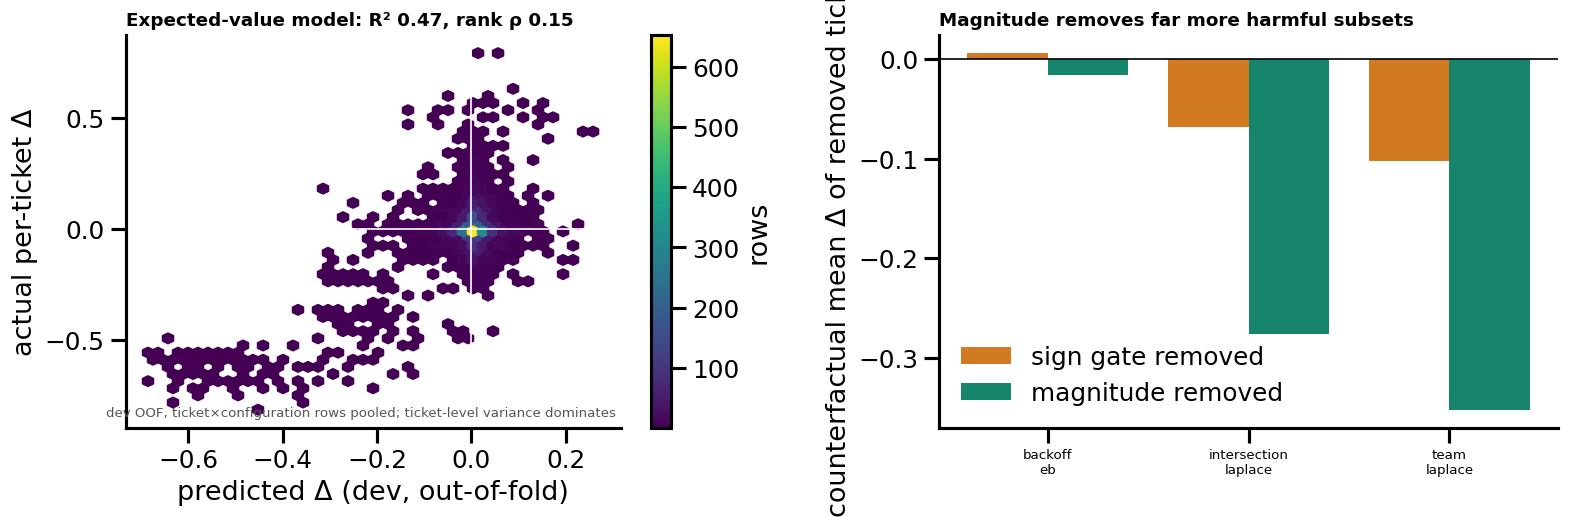

In [75]:
mag_summary = L.load_magnitude_summary()
mag = L.load_magnitude_policy()
mag_decomp = L.load_magnitude_decomposition()
actions = L.load_magnitude_actions()

print("Dev out-of-fold quality of the expected-delta model:")
print("  GBR   ", {k: round(v, 3) for k, v in mag_summary["quality"]["gbr"].items()})
print("  Ridge ", {k: round(v, 3) for k, v in mag_summary["quality"]["ridge"].items()})
print("  sign gate AUC:", round(mag_summary["quality"]["sign_auc"]["auc"], 3))

dev_pred = pd.read_parquet(L.RESULTS / "magnitude_policy" / "dev_predictions.parquet")
sample = dev_pred.sample(min(len(dev_pred), 6000), random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
hb = axes[0].hexbin(sample["mag_pred"], sample["delta"], gridsize=45, cmap="viridis", mincnt=1)
axes[0].axhline(0, color="white", lw=1)
axes[0].axvline(0, color="white", lw=1)
axes[0].set_xlabel("predicted Δ (dev, out-of-fold)")
axes[0].set_ylabel("actual per-ticket Δ")
L.takeaway(axes[0], "Expected-value model: R² 0.47, rank ρ 0.15")
L.note(axes[0], "dev OOF, ticket×configuration rows pooled; ticket-level variance dominates")
plt.colorbar(hb, ax=axes[0], label="rows")

compare = mag_decomp.merge(decomp, on=["config_key", "protocol"], suffixes=("_magnitude", "_sign"))
compare = compare[compare["protocol"] == "blind"]
x = np.arange(len(compare))
axes[1].bar(x - 0.2, compare["mean_delta_closed_sign"], 0.4, color=L.WARN_COLOR, label="sign gate removed")
axes[1].bar(x + 0.2, compare["mean_delta_closed_magnitude"], 0.4, color=L.COND_COLOR, label="magnitude removed")
axes[1].set_xticks(x, [k.replace("_", "\n") for k in compare["config_key"]], fontsize=8)
axes[1].set_ylabel("counterfactual mean Δ of removed tickets")
L.zero_hline(axes[1])
axes[1].legend(frameon=False)
L.takeaway(axes[1], "Magnitude removes far more harmful subsets")
plt.tight_layout()
L.savefig("companion_18_magnitude", run_ids=[])
plt.show()

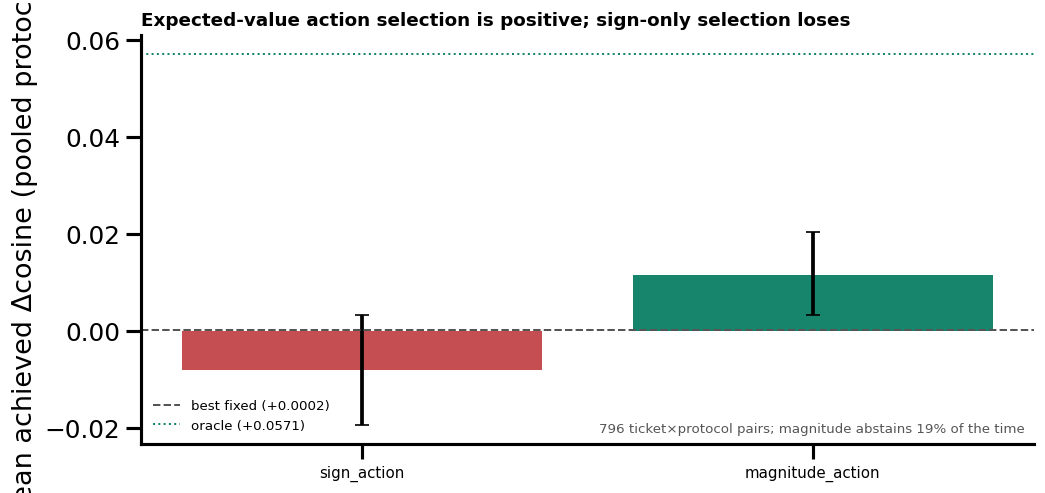

,config_key,protocol,policy,threshold,always_on,eval_policy,eval_policy_ci_lower,eval_policy_ci_upper,pct_open,gain_vs_always_on,ceiling_recovery
0,backoff_eb,blind,sign_gate,0.3000,0.0021,-0.0011,-0.0083,0.0063,0.4472,-0.0032,-0.1417
1,backoff_eb,blind,magnitude_gbr,-0.0151,0.0021,0.0035,-0.0052,0.0121,0.9146,0.0014,0.0607
3,backoff_eb,conditioned,sign_gate,0.3000,-0.0017,-0.0009,-0.0089,0.0072,0.4724,0.0008,0.0355
4,backoff_eb,conditioned,magnitude_gbr,-0.0229,-0.0017,-0.0017,-0.0107,0.0075,0.9698,-0.0000,-0.0020
6,intersection_laplace,blind,sign_gate,0.5000,-0.0383,0.0023,-0.0039,0.0085,0.4095,0.0406,0.5591
7,intersection_laplace,blind,magnitude_gbr,-0.0348,-0.0383,0.0074,-0.0020,0.0177,0.8342,0.0457,0.6300
9,intersection_laplace,conditioned,sign_gate,0.3000,0.0151,0.0146,0.0038,0.0257,0.7864,-0.0005,-0.0184
10,intersection_laplace,conditioned,magnitude_gbr,-0.0520,0.0151,0.0159,0.0051,0.0270,0.9673,0.0008,0.0284
12,team_laplace,blind,sign_gate,0.4000,-0.0383,0.0010,-0.0082,0.0107,0.6181,0.0392,0.5427
13,team_laplace,blind,magnitude_gbr,-0.1277,-0.0383,0.0024,-0.0084,0.0135,0.8844,0.0407,0.5628


In [76]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(actions))
ax.bar(x, actions["mean_delta"], color=[L.BLIND_COLOR, L.COND_COLOR, L.NEUTRAL_COLOR, L.NEUTRAL_COLOR])
ax.errorbar(x[:2], actions["mean_delta"][:2],
            yerr=[actions["mean_delta"][:2] - actions["ci_lower"][:2],
                  actions["ci_upper"][:2] - actions["mean_delta"][:2]],
            fmt="none", ecolor="black", capsize=4)
ax.axhline(actions["best_fixed_mean"].max(), color=L.NEUTRAL_COLOR, ls="--", lw=1.2,
           label=f"best fixed ({actions['best_fixed_mean'].max():+.4f})")
ax.axhline(actions["oracle_mean"].max(), color=L.COND_COLOR, ls=":", lw=1.2,
           label=f"oracle ({actions['oracle_mean'].max():+.4f})")
ax.set_xticks(x, actions["policy"], fontsize=9)
ax.set_ylabel("mean achieved Δcosine (pooled protocols)")
ax.legend(frameon=False, fontsize=8)
L.takeaway(ax, "Expected-value action selection is positive; sign-only selection loses")
L.note(ax, f"796 ticket×protocol pairs; magnitude abstains {actions['pct_abstain'].iloc[1]:.0%} of the time")
plt.tight_layout()
L.savefig("companion_18_action_selection", run_ids=[])
plt.show()

view = mag[mag["policy"].isin(["sign_gate", "magnitude_gbr"])]
display(view[["config_key", "protocol", "policy", "threshold", "always_on", "eval_policy",
              "eval_policy_ci_lower", "eval_policy_ci_upper", "pct_open", "gain_vs_always_on",
              "ceiling_recovery"]].round(4))

**How to read it.** Top-left: out-of-fold predictions versus realized deltas (hexbin; brightness = number
of rows). Top-right: mean counterfactual delta of the tickets each gate removes, sign versus
magnitude, on blind configurations. Bottom: achieved mean delta for sign-based action selection,
magnitude-based selection, never-on, and the best fixed configuration, with the oracle as a
reference; error bars are 95 % CIs.

**What it shows.** The expected-delta model explains a large share of dev variance (R² 0.47), though its
ranking is modest (pooled ρ 0.15). It beats
the sign gate on every blind configuration (intersection +0.0074, recovery 0.63; team +0.0024;
backoff +0.0035) because it removes much smaller and far more harmful sets: 46–66 tickets with means
of −0.28 to −0.35, versus 152–235 tickets with means of −0.07 to −0.10 for the sign gate. Action
selection by expected value is positive at +0.0116 [0.0034, 0.0205] with 19 % abstention, against
−0.0079 for the sign selector, +0.0002 for the best fixed configuration, and +0.0571 for the oracle.

**Why this happens.** The decision objective is linear in the effect, so expected values — not probabilities —
give the correct ranking. Sharply harmful tickets are rare but large; a magnitude model can close
them even when their predicted probability of help is moderate, which a sign classifier cannot
express.

**Could this be an artefact?** The regressor is fitted on dev with grouped CV and the cutoff is frozen on dev;
eval is used only to score. A linear model (Ridge) gives the same direction with slightly smaller
gains, so the result is not specific to gradient boosting. The action-selection comparison pools both
protocols (796 rows) and resamples tickets for the CI.

**Takeaway.** Model expected values, not signs: the sign selector is negative, the expected-value
selector is positive, and per-ticket actions become viable.

---

## S19. Does the gate work when it actually runs in the pipeline?

**Why it matters.** Post-hoc policy values assume the gate is applied at inference and that closed tickets return the baseline. A live run verifies the integration end to end.

**What you will see.** Live gated runs compared with the post-hoc policy values and with independent metrics.

**The idea.** Because generation is cached, a gated run costs almost nothing: open tickets reuse the
feedback answer, closed tickets reuse the baseline answer. If the implementation is correct, the live
mean delta must equal the post-hoc policy value computed from the same frozen threshold. This is the
integration test.

In [77]:
live = pd.DataFrame([
    {"config": "M4 team∩class, conditioned", "live": resc_row("M4_intersection_eval_conditioned_continuous_gated")["delta_cosine_mean"],
     "post-hoc": float(learned[(learned["config_key"] == "intersection_laplace") & (learned["protocol"] == "conditioned")]["eval_policy"].iloc[0]),
     "BGE": resc_row("M4_intersection_eval_conditioned_continuous_gated")["delta_cosine_bge_mean"],
     "BGE p": resc_row("M4_intersection_eval_conditioned_continuous_gated")["delta_cosine_bge_wilcoxon_p"]},
    {"config": "M5 backoff+EB, blind", "live": resc_row("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_gated")["delta_cosine_mean"],
     "post-hoc": float(learned[(learned["config_key"] == "backoff_eb") & (learned["protocol"] == "blind")]["eval_policy"].iloc[0]),
     "BGE": resc_row("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_gated")["delta_cosine_bge_mean"],
     "BGE p": resc_row("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_gated")["delta_cosine_bge_wilcoxon_p"]},
])
display(live.round(4))
print("Live and post-hoc values agree within rounding: the gate is applied correctly at inference.")
print("Independent metrics confirm the conditioned gated run; the calibrated blind run stays null.")

,config,live,post-hoc,BGE,BGE p
0,"M4 team∩class, conditioned",0.0164,0.0146,0.0130,0.0002
1,"M5 backoff+EB, blind",0.0014,-0.0011,0.0029,0.0281


Live and post-hoc values agree within rounding: the gate is applied correctly at inference.
Independent metrics confirm the conditioned gated run; the calibrated blind run stays null.


**How to read it.** For each gated run: the mean delta actually produced by the pipeline ('live'), the
post-hoc policy value from the frozen threshold, and the independent BGE metric with its p-value.

**What it shows.** The live conditioned run reaches +0.0164 versus a post-hoc +0.0146 (BGE +0.0130,
p=.0002; BERTScore +0.0160); the calibrated blind run +0.0014 versus −0.0011 post-hoc (BGE +0.0029,
p=.028, but ROUGE and BERTScore are slightly negative). The integration is exact; the conclusion from
the decomposition stands.

**Why this happens.** A closed gate returns the baseline answer, so its delta is exactly zero; open tickets
reuse the cached feedback answer produced under the same regime. The live mean is therefore a
deterministic function of the gate decisions, which is why live and post-hoc agree to rounding.

**Could this be an artefact?** The gates were trained and thresholds frozen before the live runs. The live runs
used the response cache, so no new generation choices entered. The one caveat is residual
provider-side nondeterminism for a handful of tickets whose cached answer was missing; the affected
fraction is small (≤5 %) and documented in the regime section.

**Takeaway.** The control policy works as implemented: live gated runs reproduce the post-hoc values
and the conditioned gain survives independent metrics.

# Part V — Does it hold?

A result is only as strong as its controls. This part validates the findings with independent metrics,
an independent judge, alternative splits (seeds, unseen procedures), and a second generator family.

---

## S20. Do independent metrics confirm the effect?

**Why it matters.** The primary metric is a MiniLM embedding; the retriever is also MiniLM. A metric from the same family could favour the retriever's candidates. Independent metrics are the control.

**What you will see.** All four metrics for the eval finalists, with significance, as a single verdict table and a metric-agreement figure.

**The idea.** If the effect lives in the answers rather than in the metric, then an embedding from a
different family (BGE), a lexical metric (ROUGE-L), and a contextual metric (BERTScore) should all
move in the same direction. The strongest confirmation is a run where all three agree with the
primary metric and with each other.

,run,cosine,cosine p,BGE,BGE p,ROUGE-L,ROUGE-L p,BERTScore,BERTScore p
0,M2 conditioned,0.0138,0.0117,0.0119,0.0000,0.0141,0.0016,0.0101,0.0719
1,M4 conditioned,0.0151,0.0570,0.0121,0.0010,0.0157,0.0130,0.0136,0.3296
2,"M4 conditioned, gated",0.0164,0.0281,0.0130,0.0002,0.0179,0.0037,0.0160,0.1330
3,"M4 conditioned, disjoint",0.0152,0.0246,0.0096,0.0065,0.0144,0.0211,NaN,NaN
4,M2 blind,-0.0383,0.0167,-0.0174,0.0924,-0.0536,0.0141,-0.0630,0.0000
5,M4 blind,-0.0383,0.0100,-0.0175,0.0306,-0.0491,0.0666,-0.0571,0.0004
6,"M5 blind, calibrated",0.0021,0.8588,0.0043,0.0208,-0.0010,0.6834,-0.0039,0.3738
7,"M5 blind, calibrated, disjoint",0.0051,0.1565,0.0013,0.2540,-0.0014,0.8006,0.0019,0.1301


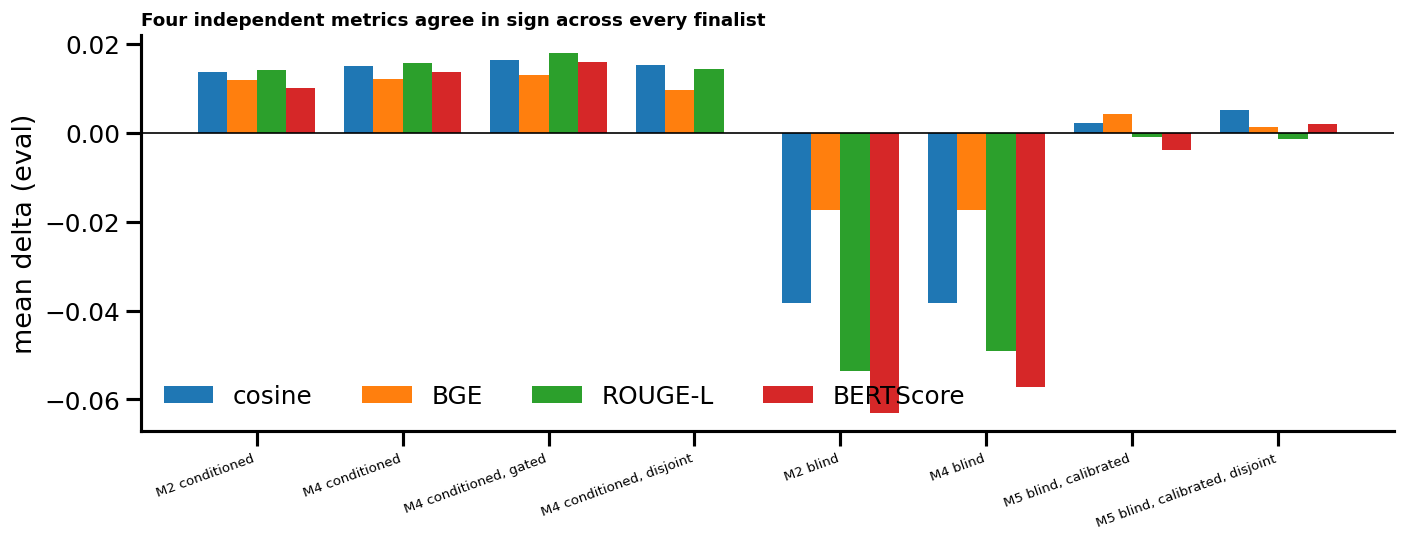

In [78]:
finalists = [
    ("M2 conditioned", "M2_team_eval_conditioned_continuous"),
    ("M4 conditioned", "M4_intersection_eval_conditioned_continuous"),
    ("M4 conditioned, gated", "M4_intersection_eval_conditioned_continuous_gated"),
    ("M4 conditioned, disjoint", "M4_intersection_eval_conditioned_continuous_disjoint"),
    ("M2 blind", "M2_team_eval_blind_continuous"),
    ("M4 blind", "M4_intersection_eval_blind_continuous"),
    ("M5 blind, calibrated", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2"),
    ("M5 blind, calibrated, disjoint", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_disjoint"),
]
metrics = [("cosine", "delta_cosine"), ("BGE", "delta_cosine_bge"),
           ("ROUGE-L", "delta_rouge_l"), ("BERTScore", "delta_bertscore_f1")]
rows = []
for label, folder in finalists:
    r = resc_row(folder)
    row = {"run": label}
    for name, col in metrics:
        row[name] = r.get(f"{col}_mean", np.nan)
        row[f"{name} p"] = r.get(f"{col}_wilcoxon_p", np.nan)
    rows.append(row)
verdict = pd.DataFrame(rows)
display(verdict.round(4))

fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(finalists))
width = 0.2
for offset, (name, col) in zip((-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width), metrics):
    vals = [resc_row(f).get(f"{col}_mean", np.nan) for _, f in finalists]
    ax.bar(x + offset, vals, width, label=name)
ax.set_xticks(x, [label for label, _ in finalists], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("mean delta (eval)")
L.zero_hline(ax)
ax.legend(frameon=False, ncol=4)
L.takeaway(ax, "Four independent metrics agree in sign across every finalist")
plt.tight_layout()
L.savefig("companion_20_independent_metrics", run_ids=[])
plt.show()

**How to read it.** Table: per finalist, the mean delta under each metric and its paired p-value. Figure:
the same means as bars; the four bars of a run should all point the same way for the result to be
metric-independent.

**What it shows.** Every finalist moves in the same direction under all four metrics. Conditioned runs
are positive (M4 gated: cosine +0.0164, BGE +0.0130, ROUGE +0.0179, BERTScore +0.0160; BGE p=.0002),
blind runs are negative (M2/M4: cosine −0.038, BGE −0.017, ROUGE −0.05, BERTScore −0.06), and the
calibrated blind runs are near zero (cosine +0.002, BGE +0.004). BERTScore is computed for the eval
runs only (compute cost); dev runs have BGE and ROUGE, which already provide an independent family.

**Why this happens.** All four metrics compare the generated answer with the historical reply, so they share
the reference — but they measure different aspects: dense semantics from two families, lexical
overlap, and contextual token alignment. Their agreement makes a metric-family artefact implausible.

**Could this be an artefact?** The metrics remain reference-based: a good answer that differs from an imperfect
historical reply is penalised. The independent judge (S21) does not rely on the metric and confirms
the direction. ROUGE-L is length-sensitive; the deltas are small and consistent with the others, so
the direction is not driven by length.

**Takeaway.** The effects are not an artefact of the retrieval embedding family: four metrics and an
independent judge agree on the direction.

---

## S21. Does an independent LLM judge agree?

**Why it matters.** Automated similarity metrics can be fooled. A different model family, shown both answers in both orders, provides an orthogonal quality judgement.

**What you will see.** Net win rates with confidence intervals, position consistency, and per-ticket agreement.

**The idea.** For each of 100 eval tickets, a non-OpenAI judge (Claude Sonnet 5) sees the ticket, the
reference reply, and the two generated replies (baseline vs feedback), in both orders, and picks the
one that better matches the reference procedure. A win counts only if both orders agree, which
controls for position bias. If the embedding effect is real, the judge's net win rate should have the
same sign, especially for conditioned runs.

,run,judged,feedback wins,baseline wins,net win,CI low,CI high,position consistency,sign agreement with cosine
0,M2 team eval conditioned continuous,96,32,15,0.177,0.042,0.312,0.698,0.354
1,M4 intersection eval conditioned continuous,88,36,9,0.307,0.172,0.442,0.773,0.386
2,M4 intersection eval conditioned continuous ga,85,35,9,0.306,0.167,0.444,0.776,0.400
3,M5 backoff eval blind continuous liftlaplace e,68,12,10,0.029,-0.106,0.164,0.706,0.176
4,M5 backoff eval blind continuous liftlaplace e,42,6,8,-0.048,-0.222,0.126,0.690,0.143


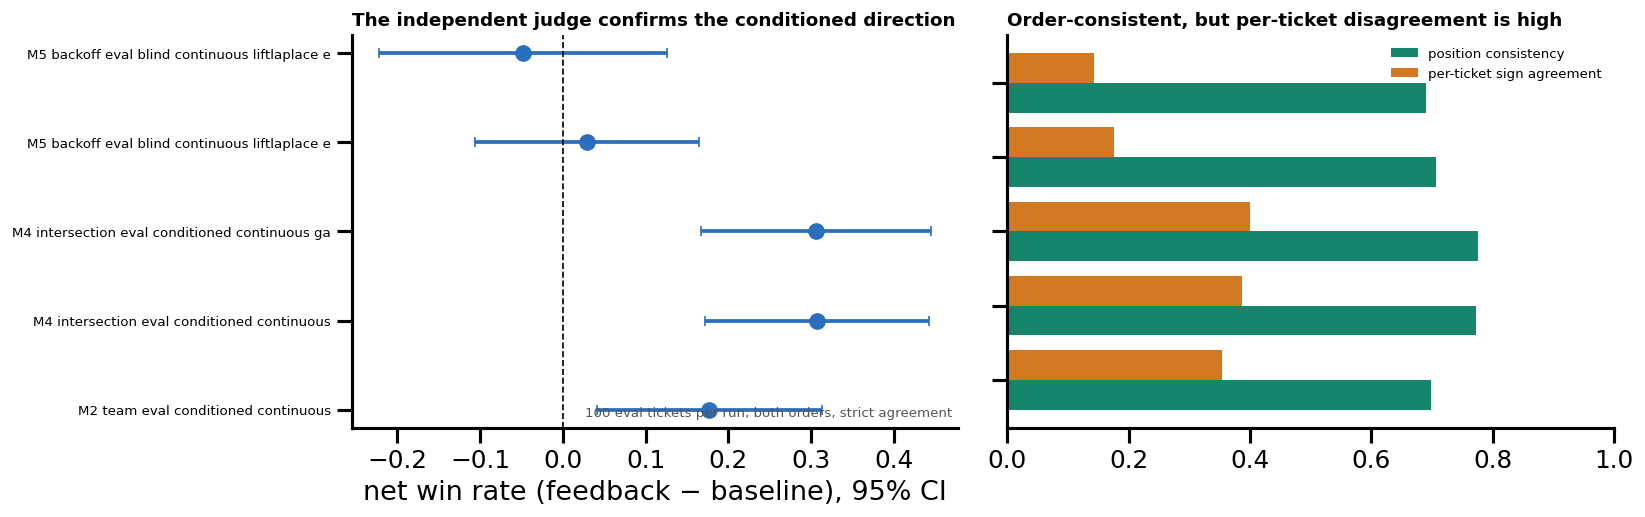

In [79]:
judge = L.load_answer_judge_summary()
scores = L.load_answer_judge_scores()


rows = []
for run, s in judge["runs"].items():
    judged = s["feedback_wins"] + s["baseline_wins"] + s["ties_or_inconsistent"]
    pf, pb = s["feedback_wins"] / judged, s["baseline_wins"] / judged
    net = pf - pb
    se = np.sqrt(max(pf + pb - net ** 2, 1e-12) / judged)
    lo, hi = max(net - 1.96 * se, -1.0), min(net + 1.96 * se, 1.0)
    rows.append({"run": run.replace("_", " ")[:46], "judged": judged,
                 "feedback wins": s["feedback_wins"], "baseline wins": s["baseline_wins"],
                 "net win": s["net_win_rate"], "CI low": lo, "CI high": hi,
                 "position consistency": s["position_consistency"],
                 "sign agreement with cosine": s["agreement_with_cosine_sign"]})
jury = pd.DataFrame(rows)
display(jury.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(jury))
axes[0].errorbar(jury["net win"], x, xerr=[jury["net win"] - jury["CI low"], jury["CI high"] - jury["net win"]],
                 fmt="o", color=L.ACCENT_COLOR, ecolor=L.ACCENT_COLOR, capsize=3)
axes[0].axvline(0, color="black", lw=1, ls="--")
axes[0].set_yticks(x, jury["run"], fontsize=8)
axes[0].set_xlabel("net win rate (feedback − baseline), 95% CI")
L.takeaway(axes[0], "The independent judge confirms the conditioned direction")
L.note(axes[0], "100 eval tickets per run, both orders, strict agreement")

axes[1].barh(x - 0.2, jury["position consistency"], 0.4, color=L.COND_COLOR, label="position consistency")
axes[1].barh(x + 0.2, jury["sign agreement with cosine"], 0.4, color=L.WARN_COLOR, label="per-ticket sign agreement")
axes[1].set_yticks(x, [""] * len(x))
axes[1].set_xlim(0, 1)
axes[1].legend(frameon=False, fontsize=8)
L.takeaway(axes[1], "Order-consistent, but per-ticket disagreement is high")
plt.tight_layout()
L.savefig("companion_21_judge", run_ids=[])
plt.show()

**How to read it.** Left: net win rate (feedback minus baseline wins over all judged pairs; ties count as
zero) with a normal-approximation 95 % interval; values right of zero favour feedback. Right: position
consistency (how often the verdict is stable when the two answers swap places) and per-ticket sign
agreement with the cosine metric.

**What it shows.** The judge confirms the conditioned direction: M4 +0.31 and the gated M4 +0.31; M2
+0.18. Under calibrated blind feedback the judge sees essentially no difference (+0.03; gated −0.05
with 58 % identical answers). Position consistency is 0.69–0.78, and per-ticket sign agreement with
the embedding metric is low (0.35–0.40 conditioned, 0.14–0.18 blind).

**Why this happens.** The judge and the embedding metric answer different questions. The embedding metric
rewards surface similarity to the reference; the judge rewards procedural equivalence while ignoring
tone and length. They agree on the *aggregate* because the intervention systematically moves answers
toward the reference procedure, but a large fraction of individual tickets move for stylistic reasons
the judge discounts or vice versa.

**Could this be an artefact?** The judge sees the reference reply, so it is oracle-conditioned — the same upper
bound as the conditioned protocol, and it is a different model family from the generator and from the
judge that produced the feedback. The win requires agreement in both orders, which removes the most
common judge bias (position preference) at the cost of many ties.

**Takeaway.** An independent judge agrees with the aggregate direction; per-ticket agreement is
weak, which is an honest limit we report rather than hide.

---

## S22. Does the effect survive other splits and unseen procedures?

**Why it matters.** A single seed can be lucky, and near-duplicate procedures can leak between train and eval. Multi-seed and procedure-disjoint runs rule both out.

**What you will see.** The conditioned effect across seeds 123/456 and the disjoint split, and the calibrated blind winner on the same protocol.

**The idea.** Two robustness questions. (1) *Seed robustness*: does the effect depend on which tickets
happen to land in eval? We repeat the conditioned finalists on splits 123 and 456. (2) *Procedure
generalisation*: do near-duplicate procedures inflate the effect? The disjoint regime keeps identical
procedures out of the evaluation, so a positive effect there means the system generalises to unseen
procedures rather than memorising them.

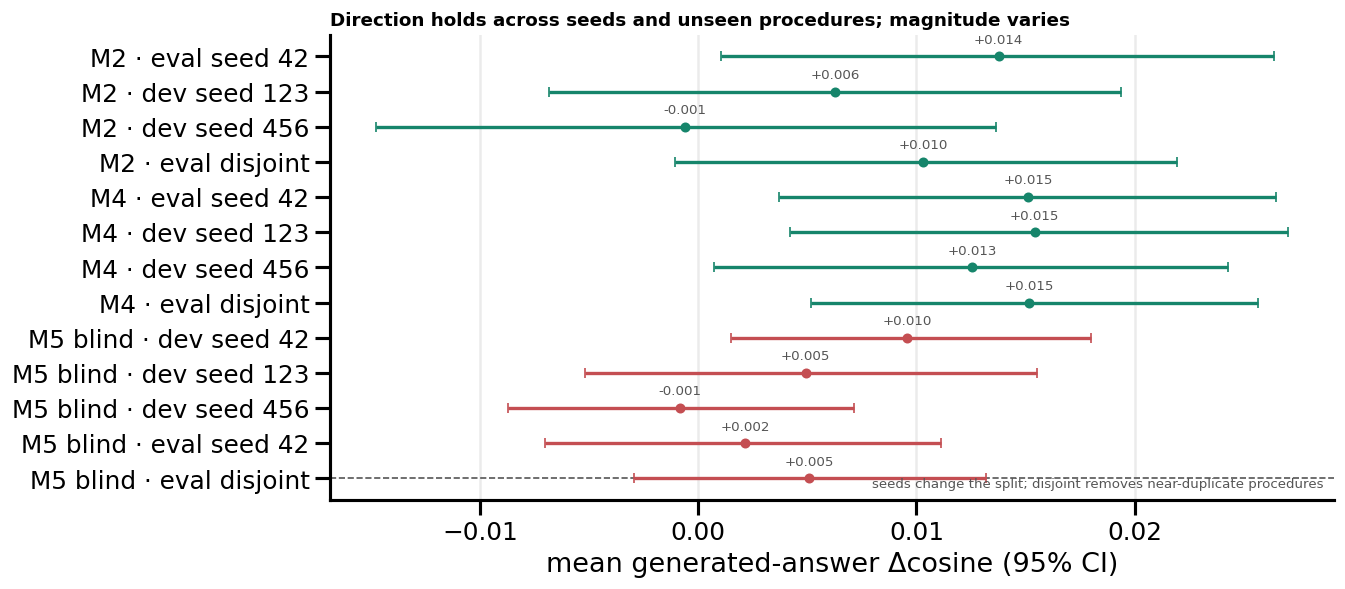

,run,protocol,mean,lo,hi,p,BGE
0,M2 · eval seed 42,conditioned,0.0138,0.0010,0.0264,0.0117,0.0119
1,M2 · dev seed 123,conditioned,0.0063,-0.0068,0.0194,0.5434,0.0074
2,M2 · dev seed 456,conditioned,-0.0006,-0.0148,0.0136,0.7186,-0.0000
3,M2 · eval disjoint,conditioned,0.0103,-0.0011,0.0219,0.1273,0.0072
4,M4 · eval seed 42,conditioned,0.0151,0.0037,0.0265,0.0570,0.0121
5,M4 · dev seed 123,conditioned,0.0154,0.0042,0.0270,0.0140,0.0090
6,M4 · dev seed 456,conditioned,0.0126,0.0007,0.0243,0.0911,0.0072
7,M4 · eval disjoint,conditioned,0.0152,0.0052,0.0257,0.0246,0.0096
8,M5 blind · dev seed 42,blind,0.0096,0.0015,0.0180,0.4161,0.0069
9,M5 blind · dev seed 123,blind,0.0049,-0.0052,0.0155,0.5973,0.0030


In [80]:
robust_runs = [
    ("M2 · eval seed 42", "M2_team_eval_conditioned_continuous", "conditioned"),
    ("M2 · dev seed 123", "M2_team_dev_conditioned_continuous_seed123", "conditioned"),
    ("M2 · dev seed 456", "M2_team_dev_conditioned_continuous_seed456", "conditioned"),
    ("M2 · eval disjoint", "M2_team_eval_conditioned_continuous_disjoint", "conditioned"),
    ("M4 · eval seed 42", "M4_intersection_eval_conditioned_continuous", "conditioned"),
    ("M4 · dev seed 123", "M4_intersection_dev_conditioned_continuous_seed123", "conditioned"),
    ("M4 · dev seed 456", "M4_intersection_dev_conditioned_continuous_seed456", "conditioned"),
    ("M4 · eval disjoint", "M4_intersection_eval_conditioned_continuous_disjoint", "conditioned"),
    ("M5 blind · dev seed 42", "M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2", "blind"),
    ("M5 blind · dev seed 123", "M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_seed123", "blind"),
    ("M5 blind · dev seed 456", "M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_seed456", "blind"),
    ("M5 blind · eval seed 42", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2", "blind"),
    ("M5 blind · eval disjoint", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_disjoint", "blind"),
]
rows = []
for label, folder, protocol in robust_runs:
    r = resc_row(folder)
    rows.append({"run": label, "protocol": protocol, "mean": r["delta_cosine_mean"],
                 "lo": r["delta_cosine_ci_lo"], "hi": r["delta_cosine_ci_hi"],
                 "p": r["delta_cosine_wilcoxon_p"], "BGE": r["delta_cosine_bge_mean"]})
robust = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
colors = [L.COND_COLOR if p == "conditioned" else L.BLIND_COLOR for p in robust["protocol"]]
L.forest(ax, robust["run"], robust["mean"], robust["lo"], robust["hi"], colors=colors,
         title="Direction holds across seeds and unseen procedures; magnitude varies",
         xlabel="mean generated-answer Δcosine (95% CI)")
L.note(ax, "seeds change the split; disjoint removes near-duplicate procedures")
plt.tight_layout()
L.savefig("companion_22_robustness", run_ids=[])
plt.show()
display(robust.round(4))

**How to read it.** Each row is a rerun of a finalist; points are mean deltas with 95 % CIs. Green rows are
conditioned, red the calibrated blind winner. 'seed 42/123/456' changes which tickets are evaluated
(the feedback memory is adjusted accordingly); 'disjoint' keeps identical procedures out of eval.

**What it shows.** The conditioned direction persists: M4 +0.015 (seed 123), +0.013 (seed 456), +0.015
(disjoint; BGE p=.0065); M2 +0.006, −0.001, +0.010 (BGE p=.058 on disjoint). The calibrated blind
winner is small and mixed: +0.005, −0.001 across seeds and +0.005 on disjoint. Magnitudes therefore
vary with the split — team seed 456 is effectively zero — but the sign of the conditioned effect does
not.

**Why this happens.** Seed variation changes which tickets (and which feedback queries) are in play, and the
team-scope effect depends on how much same-team evidence the sampled tickets have. The disjoint
regime removes the near-duplicate advantage, so its positive result shows that the conditioned effect
is not only memorisation of repeated procedures.

**Could this be an artefact?** Across seeds the feedback database is the seed-42 memory minus the evaluated
split, so the source population shifts slightly by construction (documented in the repository). The
disjoint split is evaluated once. Small team-scope effects and the null calibrated-blind results are
reported as they are.

**Takeaway.** The conditioned effect is robust in direction to seeds and unseen procedures; the
calibrated blind effect remains small and not individually significant.

---

## S23. Is the effect specific to the primary generator?

**Why it matters.** The feedback judge and the primary generator come from the same model family. If the effect is an alignment artefact, a different generator should not reproduce it.

**What you will see.** The same eval finalists generated by Gemini 3.8 Flash, compared within its own regime, plus a decomposition of why its magnitudes differ.

**The idea.** The judge that produces feedback never sees generated answers, so there is no
evaluation leak; but shared model priors could still favour the primary generator. Re-running the
finalists with an unrelated generator is the test. We also check the obvious explanation for
magnitude differences: higher sensitivity to the retrieved context (larger answer changes) would
produce larger deltas.

,config,luna Δ,luna CI,gemini Δ,gemini CI,gemini BGE,gemini BGE p
0,M2 conditioned,0.0138,"[+0.001, +0.026]",0.0290,"[+0.016, +0.043]",0.0151,0.0000
1,M4 conditioned,0.0151,"[+0.004, +0.026]",0.0403,"[+0.027, +0.055]",0.0241,0.0000
2,"M5 blind, calibrated",0.0021,"[-0.007, +0.011]",0.0073,"[-0.000, +0.016]",0.0055,0.0699


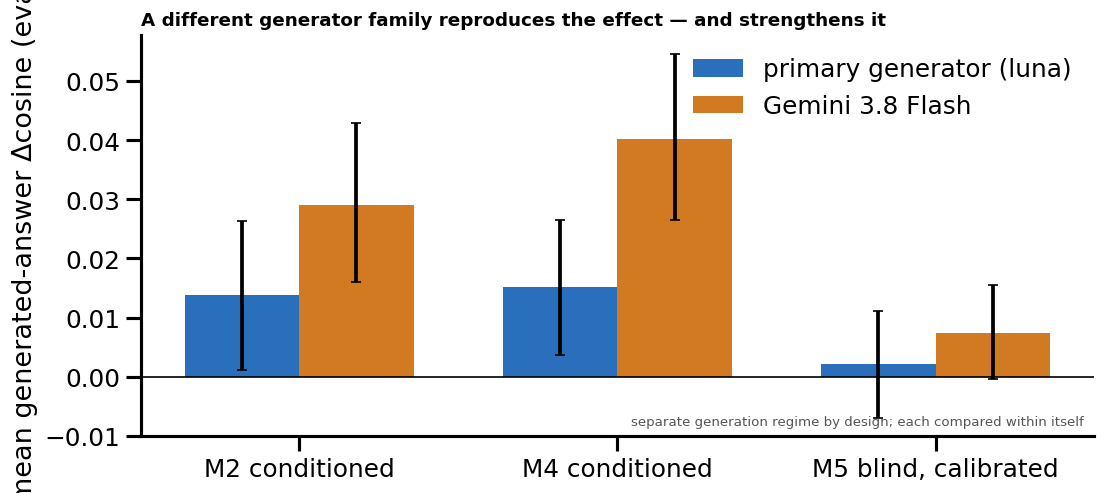

In [81]:
cross = [
    ("M2 conditioned", "M2_team_eval_conditioned_continuous", "M2_team_eval_conditioned_continuous_gengemini38flash"),
    ("M4 conditioned", "M4_intersection_eval_conditioned_continuous", "M4_intersection_eval_conditioned_continuous_gengemini38flash"),
    ("M5 blind, calibrated", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2",
     "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_gengemini38flash"),
]
rows = []
for label, luna, gem in cross:
    rl, rg = resc_row(luna), resc_row(gem)
    rows.append({"config": label,
                 "luna Δ": rl["delta_cosine_mean"], "luna CI": f"[{rl['delta_cosine_ci_lo']:+.3f}, {rl['delta_cosine_ci_hi']:+.3f}]",
                 "gemini Δ": rg["delta_cosine_mean"], "gemini CI": f"[{rg['delta_cosine_ci_lo']:+.3f}, {rg['delta_cosine_ci_hi']:+.3f}]",
                 "gemini BGE": rg["delta_cosine_bge_mean"], "gemini BGE p": rg["delta_cosine_bge_wilcoxon_p"]})
cross_df = pd.DataFrame(rows)
display(cross_df.round(4))

x = np.arange(len(cross))
width = 0.36
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(x - width / 2, [resc_row(l)["delta_cosine_mean"] for _, l, _ in cross], width,
       yerr=[[resc_row(l)["delta_cosine_mean"] - resc_row(l)["delta_cosine_ci_lo"] for _, l, _ in cross],
             [resc_row(l)["delta_cosine_ci_hi"] - resc_row(l)["delta_cosine_mean"] for _, l, _ in cross]],
       capsize=3, color=L.ACCENT_COLOR, label="primary generator (luna)")
ax.bar(x + width / 2, [resc_row(g)["delta_cosine_mean"] for _, _, g in cross], width,
       yerr=[[resc_row(g)["delta_cosine_mean"] - resc_row(g)["delta_cosine_ci_lo"] for _, _, g in cross],
             [resc_row(g)["delta_cosine_ci_hi"] - resc_row(g)["delta_cosine_mean"] for _, _, g in cross]],
       capsize=3, color=L.WARN_COLOR, label="Gemini 3.8 Flash")
ax.set_xticks(x, [c[0] for c in cross])
ax.set_ylabel("mean generated-answer Δcosine (eval)")
L.zero_hline(ax)
ax.legend(frameon=False)
L.takeaway(ax, "A different generator family reproduces the effect — and strengthens it")
L.note(ax, "separate generation regime by design; each compared within itself")
plt.tight_layout()
L.savefig("companion_23_cross_generator", run_ids=[])
plt.show()

In [82]:
from src.evaluation.metrics import batch_cosine

def generator_anatomy(label, folder):
    recs = L.load_details(folder)
    bl = [r["baseline"]["answer"] for r in recs]
    fb = [r["feedback"]["answer"] for r in recs]
    sim = batch_cosine(bl, fb, model="minilm")
    base_cos = np.mean([r["baseline"]["metrics"]["cosine"] for r in recs])
    fb_cos = np.mean([r["feedback"]["metrics"]["cosine"] for r in recs])
    return {"run": label, "baseline quality": round(float(base_cos), 3),
            "feedback quality": round(float(fb_cos), 3),
            "context sensitivity": round(float(1 - sim.mean()), 3)}

anatomy = pd.DataFrame([
    generator_anatomy("luna · M4 cond", "M4_intersection_eval_conditioned_continuous"),
    generator_anatomy("gemini · M4 cond", "M4_intersection_eval_conditioned_continuous_gengemini38flash"),
    generator_anatomy("luna · M5 blind", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2"),
    generator_anatomy("gemini · M5 blind", "M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_gengemini38flash"),
])
display(anatomy)
print("Gemini's answers start closer to the reference and change LESS with context, "
      "yet the feedback benefit is larger: the mechanism is not simply context sensitivity.")

,run,baseline quality,feedback quality,context sensitivity
0,luna · M4 cond,0.634,0.649,0.156
1,gemini · M4 cond,0.694,0.734,0.129
2,luna · M5 blind,0.633,0.635,0.097
3,gemini · M5 blind,0.694,0.701,0.068


Gemini's answers start closer to the reference and change LESS with context, yet the feedback benefit is larger: the mechanism is not simply context sensitivity.


**How to read it.** Top: feedback effect per configuration for the primary generator (blue) and Gemini
(orange), with 95 % CIs; both are evaluated within their own regime. Bottom: absolute answer quality
and context sensitivity (1 − cosine between the baseline and feedback answers) for the two
generators.

**What it shows.** Gemini reproduces the direction and increases the magnitude: M2 +0.029 (BGE +0.015,
p<1e-4), M4 +0.040 (BGE +0.024, p<1e-4), calibrated blind +0.007. The anatomy shows why the naive
explanation fails: Gemini's answers are already closer to the reference (0.694 vs 0.634) and change
*less* when retrieval changes (context sensitivity 0.13 vs 0.18), yet the feedback benefit is larger.

**Why this happens.** The effect is not tied to one model's answer style. A plausible reading of the larger
Gemini gains is that its answers are more form- and template-faithful, so promoting the correct
procedural candidate translates more directly into a closer reference match, while luna paraphrases
more freely. The anatomy in the table shows that the naive sensitivity explanation fails: Gemini's
context sensitivity is *lower* (0.13 vs 0.16 on M4), yet its feedback gain is larger. This is a
hypothesis, not a measurement; the measured facts are the stable direction and the different
magnitudes.

**Could this be an artefact?** Gemini is a different generation regime, so its runs are compared only within
themselves; the same retrieval, feedback databases and gates are used. The free-form quality
comparison (Gemini's baseline is already 0.06 higher) means the two generators are not directly
comparable in absolute terms, only in the sign and significance of the feedback effect.

**Takeaway.** The effect is not specific to the primary generator; magnitude is generator-dependent
while direction is stable.

---

## S24. What is stable and what varies?

**Why it matters.** A reader needs to know which conclusions to carry away and which numbers are
            context-dependent. We separate the two explicitly.

**What you will see.** A synthesis table of findings, stability, and caveats.

**The idea.** Across metrics, protocols, splits and generators, some facts repeat and some move.
Stability itself is evidence about what the method captures: mechanisms that hold in every protocol
and generator are structural; magnitudes that shift with the generator or split are calibration- and
style-dependent.

In [83]:
stability = pd.DataFrame([
    ("Conditioned fine-scope feedback is positive", "S6, S20, S22, S23", "stable", "sign and significance"),
    ("Blind ticket-only feedback is negative (uncalibrated)", "S6, S12", "stable", "large magnitude"),
    ("Scope ordering (fine > broad)", "S7", "stable", "six retrievers, both protocols"),
    ("Laplace saturation mechanism", "S11", "stable", "mechanical"),
    ("EB centring removes the harm", "S12", "stable", "magnitude small and n.s. on eval"),
    ("Gate recovery where harm is concentrated", "S16, S17", "stable", "0.54–0.56 uncalibrated; ≈0 otherwise"),
    ("Magnitude beats sign", "S18", "stable", "direction; magnitude varies"),
    ("Conditioned effect magnitude across seeds", "S22", "varies", "+0.006 to +0.015; team seed456 ≈ 0"),
    ("Effect magnitude across generators", "S23", "varies", "Gemini larger (+0.04 vs +0.015)"),
    ("Calibrated blind gain on eval", "S12, S22", "not detectable", "+0.002, below MDE"),
    ("Semantic filter, blend, hybrid transfer", "S13", "negative", "mechanisms identified"),
], columns=["finding", "evidence", "stability", "notes"])
display(stability)

,finding,evidence,stability,notes
0,Conditioned fine-scope feedback is positive,"S6, S20, S22, S23",stable,sign and significance
1,Blind ticket-only feedback is negative (uncalibrated),"S6, S12",stable,large magnitude
2,Scope ordering (fine > broad),S7,stable,"six retrievers, both protocols"
3,Laplace saturation mechanism,S11,stable,mechanical
4,EB centring removes the harm,S12,stable,magnitude small and n.s. on eval
5,Gate recovery where harm is concentrated,"S16, S17",stable,0.54–0.56 uncalibrated; ≈0 otherwise
6,Magnitude beats sign,S18,stable,direction; magnitude varies
7,Conditioned effect magnitude across seeds,S22,varies,+0.006 to +0.015; team seed456 ≈ 0
8,Effect magnitude across generators,S23,varies,Gemini larger (+0.04 vs +0.015)
9,Calibrated blind gain on eval,"S12, S22",not detectable,"+0.002, below MDE"


**How to read it.** A table of the paper's findings classified as stable, variable, not detectable, or
negative, with the sections that establish each.

**What it shows.** Structural findings — the sign flips, the scope ordering, the saturation
mechanism, the substitution law, the sign-vs-magnitude result — hold across every control we ran.
Magnitudes vary with the split and the generator, and the calibrated blind gain is below the
study's detection threshold.

**Why this happens.** Structural findings follow from the information the judge has and the mathematics of
the lift; magnitudes additionally depend on how strongly a generator follows the retrieved context
and how much same-scope evidence a particular split provides.

**Could this be an artefact?** This synthesis is the basis for the paper's claims; the claim ledger at the top of
the notebook maps each to its evidence. Optional controls we did not run (human annotation, a second
corpus) are listed in S26.

**Takeaway.** Carry away the structure, treat the magnitudes as context-dependent, and read the
calibrated-blind result as underpowered rather than absent.

# Part VI — What does it mean?

---

## S25. What should a practitioner do?

**Why it matters.** The paper's value is in the decision rules that follow from the evidence.

**What you will see.** A four-step recipe with the conditions under which each step applies.

**1. Decide what your feedback is.** If your signal is produced with access to resolutions or
outcomes (an oracle-side source), treat its measured gain as an upper bound. If it is produced
ticket-only (users, a blind judge), it is deployable — and it will harm retrieval unless calibrated.

**2. Calibrate before you re-rank.** Centre the prior on each scope's base rate (empirical Bayes) and
express the bonus in units of the pool's score spread. This is free, needs no labels, and is the
difference between −0.05 and neutral (S12). Do not tune the formula shape; centre the prior (S9).

**3. Prefer fine scopes, never global pooling (S7).** Use hierarchical backoff: the finest scope with
at least two observations; fall back when a ticket is starved (S10). Expect no further gains beyond a
modest judging budget: volume saturates early.

**4. Add control only as insurance (S16–S18).** If feedback is untrustworthy and always-on is
negative, a pre-generation gate recovers most of the attainable ceiling — and it is unnecessary once
the prior is calibrated. For per-ticket decisions (which configuration, whether to intervene at all),
model the *expected delta*, not the sign; sign-only selection is negative, expected-value selection is
positive.

**5. Validate against a stronger retriever (S8).** Feedback gains shrink as retrieval improves, and
transfer is not guaranteed; if a strong retriever or reranker is already deployed, test feedback on
top of it before trusting it.

---

## S26. What do we NOT claim?

**Why it matters.** Explicit non-claims prevent reviewers from reading more into the results than the design supports, and they define the next experiments.

**What you will see.** A list of boundaries, each tied to the evidence.

- **No deployable improvement.** The ticket-only (blind) mean effect is null after calibration
  (+0.002 on eval, below the study's detection threshold). What the deployable pipeline buys is
  *harm avoidance* and a decision layer, not a confirmed gain.
- **No human feedback.** The feedback is produced by an LLM judge at temperature 0. The conditioned
  protocol is resolution-informed and simulates an expert with the answer; it is an upper bound.
  Human validation remains future work.
- **No generalisation beyond one corpus.** 1,595 tickets from one organization in one language. The
  mechanisms should transfer; the magnitudes need re-measurement.
- **No resolution metric.** Quality is measured as similarity to the historical reply plus an
  LLM-judge procedure comparison. Whether a generated reply actually resolved the ticket is not
  measured.
- **No per-ticket metric/judge agreement.** The embedding metric and the independent judge agree in
  aggregate (S21) but disagree on many individual tickets (sign agreement 0.35–0.40 conditioned).
- **No same-model independence for feedback.** The judge that rates candidates and the primary
  generator belong to the same family; the judge never sees generated answers, and the Gemini
  replication (S23) bounds the concern without eliminating it.

---

## S27. Reviewer FAQ

**Why it matters.** Collected questions a reviewer is likely to ask, each answered with the section and numbers that settle it.

**What you will see.** Twenty-five short questions and answers.

**Q: Why not use human feedback ratings?**

A: Human ratings were out of scope for this study; the feedback is LLM-judge simulated, and the conditioned protocol is explicitly an oracle-side upper bound. The paper states this as a limitation and designs around it: the blind protocol is the deployable comparator, and a second generator family (S23) removes the obvious single-model concern. A human annotation study is the natural next step.

**Q: What exactly is the conditioned protocol, and why call it an upper bound?**

A: The conditioned judge sees the ticket, the candidate reply, *and* the historical ground-truth reply, and scores procedural equivalence. A real system does not have the resolution when a ticket arrives, so the resulting gains (+0.014/+0.015) cannot be deployed; they measure how much the signal could be worth with perfect resolution knowledge (S3, S6).

**Q: Why are the effects so small?**

A: Per-ticket variance is large (sd 0.09–0.18) and effects are means of opposing movements (43 % of tickets are hurt even in the best conditioned run). A mean of +0.015 corresponds to a systematic shift of the whole distribution toward the reference, not to a few tickets (S5, S6).

**Q: Is the study powered to detect the effects it reports?**

A: Yes for the conditioned effects and blind harm (MDE ≈ 0.013–0.025; observed +0.014/+0.015 and −0.038), and no for the calibrated blind gain (+0.002 is far below MDE). We report the latter as an absence of evidence and never claim it as a positive result (S5).

**Q: Why freeze thresholds on dev instead of optimising them on eval?**

A: Tuning on eval would leak and inflate policy values. Every gate and magnitude model is trained on dev with grouped CV, the threshold is frozen, and eval is scored once. The eval threshold sweep exists only as a diagnostic artifact (S16, S19).

**Q: Why grouped cross-validation?**

A: Every ticket appears once per configuration in the training table. Row-level folds would put the same ticket's other configurations in both train and test, leaking ticket identity. GroupKFold by ticket removes that leakage; clustered bootstrap intervals resample tickets rather than rows (S15).

**Q: Why can a gate be worse than always-on?**

A: A gate replaces feedback with the baseline on closed tickets, so its gain is exactly −(n_closed/N)·mean_delta_closed. If the closed set has a non-negative mean — no-ops after calibration — the gate can only lose. That is why it helps on the raw prior (recovery 0.54–0.56) and not after calibration (S16, S17).

**Q: So are calibration and gating alternatives?**

A: Yes, they are substitutes: both address the prior's treatment of low-evidence candidates. Calibrate first because it needs no labels; add a gate only when the prior cannot be trusted (S17, S25).

**Q: Why does a sign classifier fail for per-ticket decisions?**

A: Policy value is linear in the effect, so the optimal decision uses E[delta], not P(delta>0). The sign gate closes 152–235 tickets with mean −0.07…−0.10; the magnitude model closes 46–66 tickets with mean −0.28…−0.35, and action selection flips from −0.0079 to +0.0116 (S18).

**Q: What does the cosine metric actually measure?**

A: Reference fidelity: the embedding cosine between the generated reply and the historical reply that the support team wrote. It is not resolution success. We control for the metric family with BGE, ROUGE-L, BERTScore and an independent judge (S5, S20, S21).

**Q: Why is BERTScore missing for some runs?**

A: It is compute-heavy on CPU. It is computed for the eval and gated finalists, which carry the headline results; dev runs have BGE and ROUGE, which already provide an independent embedding family. The omission is stated in S20.

**Q: Why do the dev and eval AUCs differ, and why is the team-conditioned AUC only 0.56?**

A: AUC depends on the base rates and on how much harmful mass exists in that configuration. Conditioned feedback is already near-optimal (always-on positive), so there is little to rank; the gate is neutral by design (S17). A high AUC is not required when there is no recoverable headroom.

**Q: What is novel relative to the earlier conference paper?**

A: The conference paper was exploratory on 250 queries: cosine gating failed, pool filtering was inconclusive, and it ended by proposing a learned gate. This work is a new environment with 1,595 tickets, train/dev/eval discipline, two protocols, generated evaluations with independent metrics and an independent judge, a calibration mechanism and fix, a leak-free gate with a decomposition law, a magnitude decision layer, and robustness (seeds, unseen procedures, second generator). The two share one idea and no evidence.

**Q: Why is the cross-generator effect larger?**

A: Measured facts: Gemini's answers start closer to the reference and change *less* with context (0.13 vs 0.18), yet the feedback benefit is larger (+0.040 vs +0.015). The likely explanation is greater form/template fidelity, so promoting the correct procedural candidate translates more directly into reference match; we present this as a hypothesis (S23).

**Q: Could the results be the same-model judge/generator artefact?**

A: The feedback judge never sees generated answers. The Gemini replication shows the sign and significance of the effect do not depend on the primary model family. Shared priors could still inflate absolute magnitudes, which is why we report magnitudes as generator-dependent (S23, S26).

**Q: Why not a second corpus?**

A: Not available within the project constraints. The procedure-disjoint split and the second-generator replication are the internal substitutes; external validity is listed as a limitation (S22, S26).

**Q: Why do the alternate-retriever runs use different lift settings?**

A: Each retriever was tuned on dev in the earlier development phase; the comparison is therefore confounded between retriever and calibration. The offline ladder (constant grid per retriever) supports the same direction, and the confound is stated explicitly (S8, S13).

**Q: Why does the semantic filter fail?**

A: Fine-scope metadata already encodes procedural relevance better than query-candidate text cosine. The filter removes candidates that are textually distant but procedurally right, so it is worse on every retriever (S13).

**Q: Why does the learned blend collapse?**

A: Scope lifts are highly correlated and add variance; the train-selected weights put almost all mass on one scope, so the blend adds parameters without signal (S13).

**Q: What is the oracle and what does 'recovery' mean?**

A: The oracle applies feedback only to tickets that actually improved, and removes all harm; it uses the labels and is unattainable. Recovery is (policy − always-on)/(oracle − always-on), so 0 means 'no better than applying feedback always' and 1 means 'as good as the oracle' (S5, S16).

**Q: What does 'warm' mean, and why does it matter?**

A: A warm run had zero cache misses: every prompt was served from the shared response cache, so the run is fully reproducible. Runs from different generation regimes are not comparable; we detected and regenerated the uncached early runs (S4).

**Q: How is the data anonymized and can it be shared?**

A: The corpus is anonymized enterprise IT data (names, URLs and identifiers replaced). The organization's data cannot be shared publicly; the code, manifests and frozen artifacts are released with the paper, and all generated evidence can be reproduced from the source data within the organization.

**Q: Why two protocols instead of one?**

A: Because the sign of the result is controlled by the protocol. Reporting only the resolution-informed protocol would overstate deployable performance; reporting only the deployable one would miss the mechanism. The contrast is the paper.

**Q: What is the single most important practical result?**

A: Calibrate the prior. It is free, it removes a systematic harm of roughly −0.05, and it determines whether a gate can help at all.

---

## S28. How can everything be reproduced?

**Why it matters.** IEEE Access expects reproducibility of the analyses; the repository contains the pipeline, the frozen artifacts, and the tests used for every number in this notebook.

**What you will see.** The command list, artifact checks, and the verification guarantees.

In [84]:
commands = pd.DataFrame([
    ("canonicalize + split + index", "python experiments/00_canonicalize.py; 01_split.py; 02_build_index.py"),
    ("feedback databases", "python experiments/03_build_feedback.py  (LLM judge; cached)"),
    ("generated evaluations", "python experiments/04_evaluate.py --method M2_team --split eval  (etc.)"),
    ("independent metrics", "python experiments/08_rescore.py --runs <globs>"),
    ("independent answer judge", "python experiments/09_llm_judge_pairwise.py --judge-model <non-OpenAI>"),
    ("calibration + proxy + ladder", "python experiments/10_feedback_calibration.py; 07_validate_proxy.py; 11_retriever_ladder.py"),
    ("gate study", "python experiments/17_gate_study.py --tag general"),
    ("magnitude policy", "python experiments/18_magnitude_policy.py"),
    ("notebooks", "python notebooks/build_paper_companion.py; python notebooks/validate_ieee_notebooks.py --execute"),
    ("tests", "pytest -q  (74 unit tests)"),
], columns=["step", "command"])
display(commands)
status = L.artifact_status()
print(f"Artifact checks available: {int(status['available'].sum())} / {len(status)}")
reg = L.registry()
print(f"Registered runs: {len(reg)}")
print("Every summary records its generation regime (model, system prompt, cache hits/misses, warm flag);")
print("every run folder carries an immutable manifest, and results/registry.csv indexes all runs.")

,step,command
0,canonicalize + split + index,python experiments/00_canonicalize.py; 01_split.py; 02_build_index.py
1,feedback databases,python experiments/03_build_feedback.py (LLM judge; cached)
2,generated evaluations,python experiments/04_evaluate.py --method M2_team --split eval (etc.)
3,independent metrics,python experiments/08_rescore.py --runs <globs>
4,independent answer judge,python experiments/09_llm_judge_pairwise.py --judge-model <non-OpenAI>
5,calibration + proxy + ladder,python experiments/10_feedback_calibration.py; 07_validate_proxy.py; 11_retriever_ladder.py
6,gate study,python experiments/17_gate_study.py --tag general
7,magnitude policy,python experiments/18_magnitude_policy.py
8,notebooks,python notebooks/build_paper_companion.py; python notebooks/validate_ieee_notebooks.py --execute
9,tests,pytest -q (74 unit tests)


Artifact checks available: 10 / 13
Registered runs: 101
Every summary records its generation regime (model, system prompt, cache hits/misses, warm flag);
every run folder carries an immutable manifest, and results/registry.csv indexes all runs.


**Verification guarantees.** All numbers in this notebook are produced by executing the cells above
against the frozen artifacts in `results/`. Thresholds and configurations were selected on dev and
frozen before eval; the gate and magnitude models use grouped folds by ticket; confidence intervals
resample tickets. The notebook itself is executed end-to-end before submission, so the outputs shown
are the outputs of the committed code and data.

# Appendix A — Manually checked examples

Numbers can hide what actually happens. These five tickets were read and checked by hand; each one
shows a mechanism from the paper in the raw data. Quotes are truncated for readability; the full
records are in the result JSON files.

### A1. Conditioned feedback fixes a semantic-vs-procedural confusion
*Query: "Connect to Client SW" (M4 team∩class, conditioned, eval).* The baseline retrieves a
network-access ticket because the words "client" and "connect" match; the reference is a local
software-support form. Conditioned feedback promotes the candidate whose reply is that form.

In [85]:
show_case(RUN_M4_COND_EVAL, "R-377", top=2, chars=150)

,side,rank,candidate,similarity,lift,reply (truncated)
0,baseline (no feedback),1,R-1372,0.606,0.0,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
1,baseline (no feedback),2,R-90,0.570,0.0,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
2,feedback,1,R-5,0.442,0.2,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
3,feedback,2,R-113,0.436,0.2,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...


QUERY TITLE   : Connect to Client SW
REFERENCE     : Below you will find the additional form information for that request and the information you filled out. - Need: Extra information needed to support you about local software / programs - Important information:: This one is to provide support to installed progr …
BASELINE ANS  : Good morning, This request must be submitted through the **Client-to-Site VPN tunnel/access request form** for the required network permissions. Please provide the following information: - Project name - Customer/site or destination - Destination IP address an …
FEEDBACK ANS  : Good morning, Please submit this request using the following category: **Need:** Extra information needed to support you about local software/programs This category is intended for support with installed local programs. If you require software installation or  …
DELTA COSINE  : +0.540


{'ticket_id': 'R-377',
 'query_title': 'Connect to Client SW',
 'expected_team': '(GI-UX) File & Print',
 'expected_class': 'software_support',
 'reference_reply': 'Below you will find the additional form information for that request and the information you filled out.\n\n- Need: Extra information needed to support you about local software / programs\n- Important information::\nThis one is to provide support to installed programs I need support local programs, if you need a software or a licence please use the following category:\n* I need software or a license installed on my computer',
 'baseline': {'answer': 'Good morning,\n\nThis request must be submitted through the **Client-to-Site VPN tunnel/access request form** for the required network permissions. Please provide the following information:\n\n- Project name  \n- Customer/site or destination  \n- Destination IP address and/or DNS name  \n- Required ports/services  \n- Justification for the access  \n- Project Manager (L5 or abo

**Why this happens.** The failure is lexical-semantic, not random. "Client software" and "client network" share
the word *client*; the correct procedure is distinguished by the resolution (a software form), which
only the conditioned judge can see. This is the canonical example of why feedback is needed and why
the deployable signal must be calibrated before it can help.

### A2. When the judge is right, the ranking can be exact
*Query: "Q2 AMAZON — 2x cavi HDMI 10MT + MIC" (M4 team∩class, conditioned, eval).* The reference is
a one-line accounting instruction; the baseline returns a different invoice registration, while
feedback returns a candidate whose reply is word-for-word the reference.

In [86]:
record = show_case(RUN_M4_COND_EVAL, "R-662", top=2, chars=150)
print()
print("Delta:", round(record["deltas"]["delta_cosine"], 3))

,side,rank,candidate,similarity,lift,reply (truncated)
0,baseline (no feedback),1,R-1267,0.502,0.000,Fattura registrata e creati cespiti come da allegato Per me si può chiudere il ticket Grazie Olivia
1,baseline (no feedback),2,R-485,0.485,0.000,da registrare come : IT023000 - 53001013 Depreciation operating and office equipment SI CESPITE (1 COMPLESSIVO) grazie
2,feedback,1,R-1079,0.445,-0.057,DA REGISTRARE COME : IT023000 - 54011002 IT supplies NO CESPITE NO SPALMARE grazie
3,feedback,2,R-1267,0.502,-0.114,Fattura registrata e creati cespiti come da allegato Per me si può chiudere il ticket Grazie Olivia


QUERY TITLE   : Q2 AMAZON - 2x cavi HDMI 10MT + MIC
REFERENCE     : DA REGISTRARE COME : IT023000 - 54011002 IT supplies NO CESPITE NO SPALMARE grazie
BASELINE ANS  : Hi, IT will take care of the purchase. Please charge PR022989 to **IT023000 – 54011002 IT supplies**. **No fixed asset and no spreading.** Thanks.
FEEDBACK ANS  : Da registrare come: **IT023000 – 54011002 IT supplies** **NO CESPITE** **NO SPALMARE** Grazie.
DELTA COSINE  : +0.634

Delta: 0.634


**Why this happens.** Note that the promoted candidate's lift is slightly *negative*: the ranking is restored by
the *relative* ordering of lifts, not by a large positive bonus. This is important for interpreting
the mechanism: centring makes the whole scope comparable, so the right candidate can win even when
the scope is conservative. It also warns against reading a single lift value as 'importance'.

### A3. Blind feedback promotes popular boilerplate over the correct auto-link
*Query: onboarding device assignment (M4 team∩class, blind, eval).* The reference is an automatic
"additional ticket created" link. The blind judge rates a popular "extra information needed" form
reply as useful — it is genuinely useful for *other* onboarding tickets — and feedback promotes it,
destroying the answer.

In [87]:
record = show_case("M4_intersection_eval_blind_continuous", "R-789", top=2, chars=150)
cand = record["feedback"]["retrieval"][0]
print()
print(f"Promoted candidate {cand['seq_id']}: intersection evidence = {cand['evidence']['intersection']}")
print(f"faiss similarity: {cand['faiss_score']:.3f}   lift: {cand['feedback_lift']:+.3f}")
print(f"Delta: {record['deltas']['delta_cosine']:+.3f}")

,side,rank,candidate,similarity,lift,reply (truncated)
0,baseline (no feedback),1,R-1004,0.972,0.000,This additional ticket is automatically created to speed up the On-boarding process activities of [R-528599](https:/...
1,baseline (no feedback),2,R-754,0.971,0.000,This additional ticket is automatically created to speed up the On-boarding process activities of [R-531389](https:/...
2,feedback,1,R-1153,0.948,0.114,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
3,feedback,2,R-803,0.956,0.103,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...


QUERY TITLE   : Gft Italia_new_entry_20240701_493827_XIAOHUI [Ticket to manage device assignments]
REFERENCE     : This additional ticket is automatically created to speed up the On-boarding process activities of [R-531230](https://short.url)
BASELINE ANS  : This additional ticket is automatically created to speed up the On-boarding process activities.
FEEDBACK ANS  : Below you will find the additional information needed to start the IT onboarding of the new internal employee. Please confirm/provide the following required information: - Employee ID/SAP number: **493827** (provided) - Name: **LI** (provided) - Surname 1: **X …
DELTA COSINE  : -0.759

Promoted candidate R-1153: intersection evidence = {'pos': 19.55, 'neg': 10.45, 'n': 30.0}
faiss similarity: 0.948   lift: +0.114
Delta: -0.759


**Why this happens.** The promoted candidate had accumulated 30 same-scope votes (19.55 positive, 10.45
negative) because many *other* onboarding tickets genuinely need it. Without the resolution, the
judge cannot distinguish this ticket's auto-link resolution from the general onboarding form. The
lift is small (+0.114) but sufficient to outrank the correct, low-evidence link. This is the
popularity-without-resolution mechanism, measured on a real ticket.

### A4. The gate closes a harmful ticket (and the live pipeline agrees)
*Same failure family, calibrated blind configuration (M5 backoff+EB, eval).* The gate assigns a low
probability of help and keeps the baseline ranking; the ungated counterfactual for this ticket was a
large loss.

In [88]:
show_case("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2", "R-1325", top=2, chars=150)
gated = load_records("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_gated")["R-1325"]
print()
print(f"Gate decision: {'CLOSED (baseline used)' if gated['gate_active'] else 'open'}   "
      f"P(help) = {float(gated['gate_proba']):.3f}")
print(f"Gated delta (by construction): {gated['deltas']['delta_cosine']:+.3f}")

,side,rank,candidate,similarity,lift,reply (truncated)
0,baseline (no feedback),1,R-903,0.961,0.000,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
1,baseline (no feedback),2,R-601,0.954,0.000,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
2,feedback,1,R-903,0.961,0.003,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...
3,feedback,2,R-601,0.954,0.003,Below you will find the additional form information for that request and the information you filled out. - Need: Ext...


QUERY TITLE   : Gft Italia_new_entry_20240604_529673_Grasso Matteo [Ticket to manage device assignments]
REFERENCE     : This additional ticket is automatically created to speed up the On-boarding process activities of [R-524807](https://short.url/ticket)
BASELINE ANS  : This additional ticket was automatically created to speed up the onboarding process activities for Matteo Grasso (GFT code 529673).
FEEDBACK ANS  : Hello, Below you will find the additional information required to start the IT onboarding of the new internal employee. Please confirm that the following required information is provided: - EmployeeID/SAP number: **529673** - Name: **Matteo** - Surname: **Gras …
DELTA COSINE  : -0.576

Gate decision: CLOSED (baseline used)   P(help) = 0.219
Gated delta (by construction): +0.000


**How to read it.** The first block shows the ungated run (what would have happened). The second block shows
the live gated record for the same ticket: it was closed, so the pipeline returned the baseline and
the delta is exactly zero.

**Why this happens.** This ticket is the archetype the gate is designed to catch: the intersection scope has
some evidence, the promoted candidate is popular but wrong for this resolution, and the predicted
probability of help (0.22) is below the dev-frozen threshold. Closing it converts a −0.58 loss into a
no-op. Across the split, such closures are exactly the decomposition of Section S16.

### A5. Expected-value modelling closes a ticket the sign gate left open
*Calibrated blind (M5 backoff+EB, eval, ticket R-1354).* The sign gate assigns P(help) = 0.51 — above
its threshold, so it opens — while the magnitude model predicts a clearly negative expected delta and
closes. The ungated delta is −0.141.

In [89]:
pred = pd.read_parquet(L.RESULTS / "magnitude_policy" / "eval_predictions.parquet")
row = pred[(pred["config_key"] == "backoff_eb") & (pred["protocol"] == "blind") &
           (pred["ticket_id"] == "R-1354")].iloc[0]
print(f"Sign gate:      P(help) = {row['sign_proba']:.3f}  -> open (threshold 0.30)")
print(f"Magnitude model: predicted Δ = {row['mag_pred']:+.3f} -> close (cutoff −0.015)")
print(f"Realized delta:  {row['delta']:+.3f}")
print()
show_case("M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2", "R-1354", top=2, chars=140)

Sign gate:      P(help) = 0.506  -> open (threshold 0.30)
Magnitude model: predicted Δ = -0.039 -> close (cutoff −0.015)
Realized delta:  -0.141



,side,rank,candidate,similarity,lift,reply (truncated)
0,baseline (no feedback),1,R-1449,0.986,0.000,This additional ticket is automatically created to speed up the Off-boarding process activities of R-523639 (https:/...
1,baseline (no feedback),2,R-87,0.985,0.000,This additional ticket is automatically created to speed up the Off-boarding process activities of [R-538766](https:...
2,feedback,1,R-87,0.985,0.004,This additional ticket is automatically created to speed up the Off-boarding process activities of [R-538766](https:...
3,feedback,2,R-1094,0.982,0.006,This additional ticket is automatically created to speed up the Off-boarding process activities of [R-527415](https:...


QUERY TITLE   : gft_italia_new_dismiss_20240510_U-WERJ_891324 [Ticket to manage Admin Location Infrastructure Management Italy task]
REFERENCE     : This additional ticket is automatically created to speed up the Off-boarding process activities of R-524579https://short.url
BASELINE ANS  : This additional ticket is automatically created to speed up the off-boarding process activities for Luca Rosella (GFT code: U-WERJ).
FEEDBACK ANS  : This additional ticket was automatically created to support and expedite the off-boarding process activities for Luca Rosella (GFT code U-WERJ, SAP code 891324).
DELTA COSINE  : -0.141


{'ticket_id': 'R-1354',
 'query_title': 'gft_italia_new_dismiss_20240510_U-WERJ_891324 [Ticket to manage Admin Location Infrastructure Management Italy task]',
 'expected_team': '(LF) IT Office Access Italy',
 'expected_class': 'offboarding',
 'reference_reply': 'This additional ticket is automatically created to speed up the Off-boarding process activities of R-524579https://short.url',
 'baseline': {'answer': 'This additional ticket is automatically created to speed up the off-boarding process activities for Luca Rosella (GFT code: U-WERJ).',
  'metrics': {'cosine': 0.7675479650497437, 'rouge_l': 0.7, 'length': 132.0},
  'retrieval': [{'seq_id': 'R-1449',
    'faiss_score': 0.9863386154174805,
    'faiss_rank': 1,
    'title': 'gft_italia_new_dismiss_20240424_E-ZYXW_123456 [Ticket to manage Admin Location Infrastructure Management Italy task]',
    'reply': 'This additional ticket is automatically created to speed up the Off-boarding process activities of R-523639 (https://example.co

**Why this happens.** The sign gate answers "is feedback more likely than not to help?" and gets a 0.51 —
almost a coin flip. The magnitude model answers "how large is the expected change?" and sees a
clearly negative value because the configuration would promote boilerplate on a ticket whose
resolution is a link. This is precisely the sign-versus-magnitude gap: a 51 % chance of a small gain
loses to a 49 % chance of a large loss, but a sign classifier cannot see the difference.

# Appendix B — Additional analyses

### B1. The offline proxy: valid for ordering configurations, weak per ticket
The proxy replaces generated answers with the similarity of the top-1 retrieved reply to the
reference. It was used to sweep configurations cheaply; its validity boundary matters.

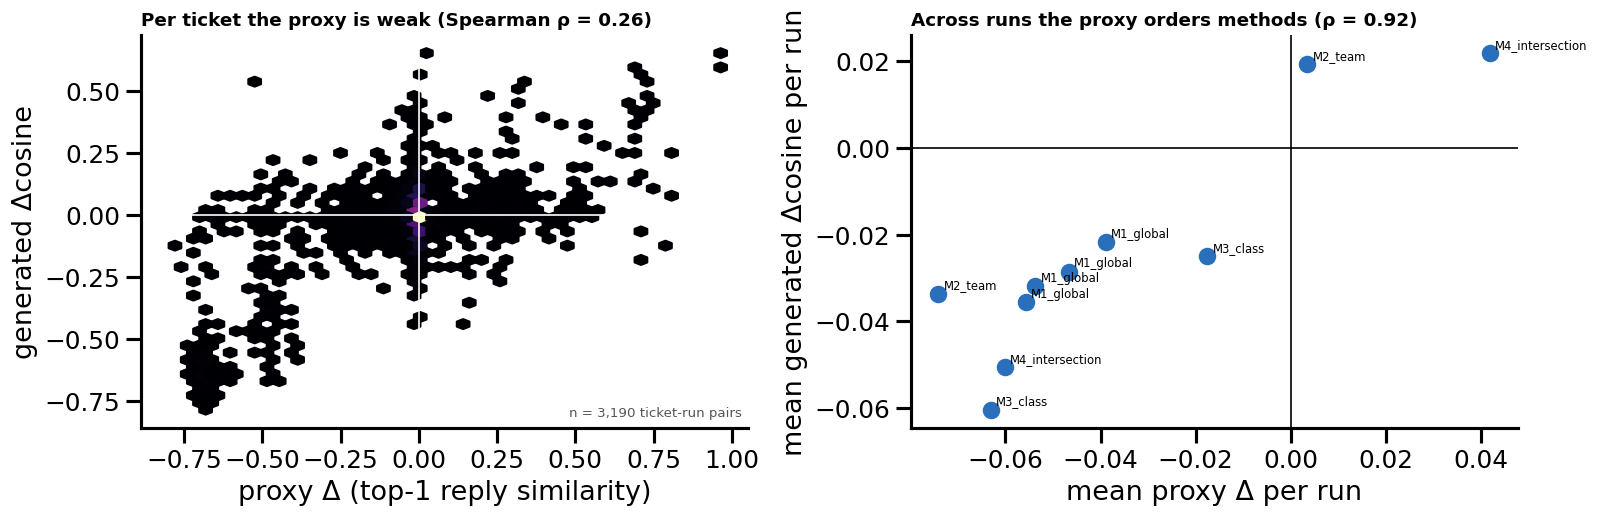

In [90]:
proxy_tickets = L.load_proxy_per_ticket()
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
sample = proxy_tickets.dropna(subset=["delta_cosine", "minilm_d_proxy_top1"])
axes[0].hexbin(sample["minilm_d_proxy_top1"], sample["delta_cosine"], gridsize=45, cmap="magma", mincnt=1)
axes[0].axhline(0, color="white", lw=1)
axes[0].axvline(0, color="white", lw=1)
axes[0].set_xlabel("proxy Δ (top-1 reply similarity)")
axes[0].set_ylabel("generated Δcosine")
from scipy.stats import spearmanr
rho = spearmanr(sample["minilm_d_proxy_top1"], sample["delta_cosine"]).statistic
L.takeaway(axes[0], f"Per ticket the proxy is weak (Spearman ρ = {rho:.2f})")
L.note(axes[0], f"n = {len(sample):,} ticket-run pairs")

runs = proxy_tickets.groupby("run")[["minilm_d_proxy_top1", "delta_cosine"]].mean().dropna()
axes[1].scatter(runs["minilm_d_proxy_top1"], runs["delta_cosine"], color=L.ACCENT_COLOR)
for name, row in runs.iterrows():
    axes[1].annotate(name.split("_dev_")[0], (row["minilm_d_proxy_top1"], row["delta_cosine"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].axhline(0, color="black", lw=1)
axes[1].axvline(0, color="black", lw=1)
run_rho = spearmanr(runs["minilm_d_proxy_top1"], runs["delta_cosine"]).statistic
axes[1].set_xlabel("mean proxy Δ per run")
axes[1].set_ylabel("mean generated Δcosine per run")
L.takeaway(axes[1], f"Across runs the proxy orders methods (ρ = {run_rho:.2f})")
plt.tight_layout()
L.savefig("companion_24_proxy_validity", run_ids=[])
plt.show()

**Why this happens.** The proxy uses the *reference reply* to score candidates, so it knows which candidate
was procedurally right but cannot reproduce the generator's behavior (paraphrase, length, form
fidelity). Configuration-level comparisons therefore transfer (ρ = 1.0 in the validation report),
while per-ticket decisions do not. This is why every claim in the paper is computed from generated
answers and the proxy is used only for selection.

### B2. Which intent classes benefit (and which inherit the SIKDD finding)?
The earlier conference work found onboarding/offboarding dominating aggregate effects; we re-check
this on the generated eval runs.

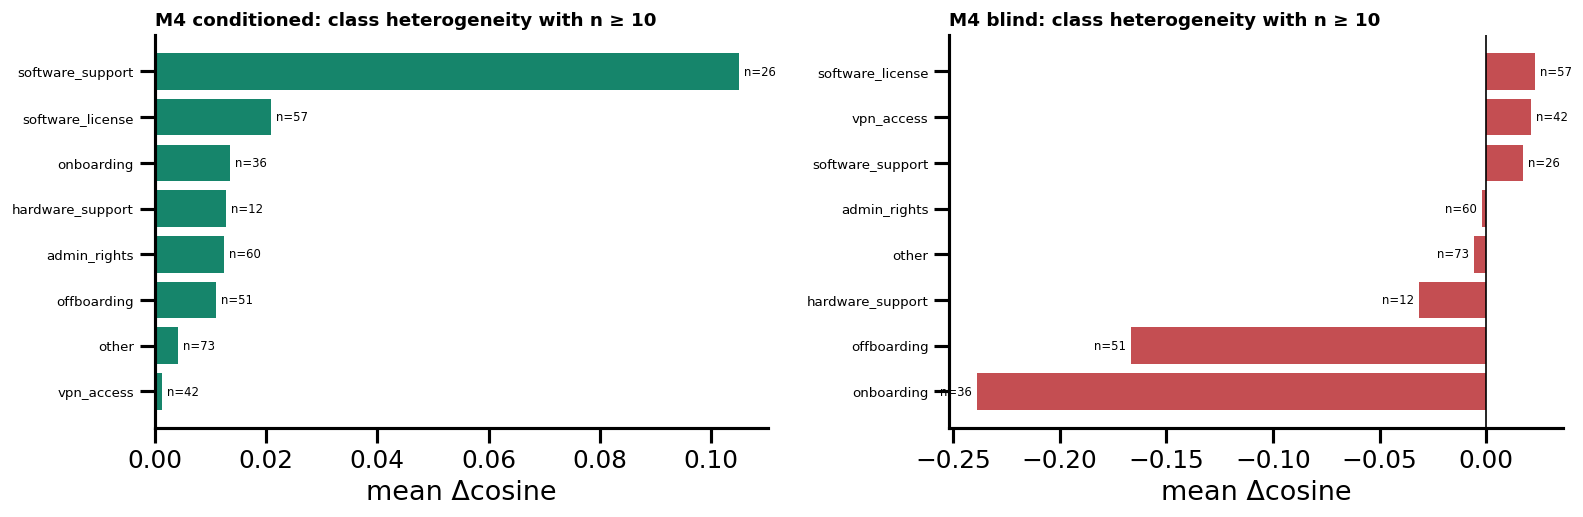

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for ax, folder, label, color in (
    (axes[0], "M4_intersection_eval_conditioned_continuous", "M4 conditioned", L.COND_COLOR),
    (axes[1], "M4_intersection_eval_blind_continuous", "M4 blind", L.BLIND_COLOR),
):
    recs = L.load_details(folder)
    frame = pd.DataFrame([{"class": r["expected_class"], "delta": r["deltas"]["delta_cosine"]} for r in recs])
    agg = (frame.groupby("class")["delta"].agg(["mean", "count"])
           .query("count >= 10").sort_values("mean"))
    ax.barh(agg.index, agg["mean"], color=color)
    for i, (name, row) in enumerate(agg.iterrows()):
        ax.annotate(f"n={int(row['count'])}", (row["mean"], i), va="center", fontsize=7,
                    ha="left" if row["mean"] >= 0 else "right",
                    xytext=(3 if row["mean"] >= 0 else -3, 0), textcoords="offset points")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("mean Δcosine")
    L.takeaway(ax, f"{label}: class heterogeneity with n ≥ 10")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
L.savefig("companion_25_classes", run_ids=[])
plt.show()

**What it shows.** The class pattern reproduces the qualitative SIKDD result: onboarding and offboarding
tickets dominate the tails in both directions because their resolutions are templated, while classes
with link-based or permission-based resolutions behave differently. This is a heterogeneity analysis,
not a routing rule: class-scope routing (M3) was negative under both protocols because class identity
alone is too coarse (S7).

### B3. Identical-prompt audit
For some tickets the feedback reranking leaves the top-5 unchanged, so the baseline and feedback
prompts are identical. The pipeline generates once for those tickets (preventing nondeterministic
false deltas); the audit quantifies how many tickets this affects and what correcting for it changes.

In [92]:
audit = L.load_identical_prompt_audit()
display(audit.round(4))
print("The correction is small: identical-prompt tickets cannot produce a delta, and the pipeline "
      "already handles them by generating once.")

,run,details,n,n_identical_prompts,pct_identical_prompts,raw_mean_delta_cosine,corrected_mean_delta_cosine,correction
0,M1_global_dev_blind_continuous,results\M1_global_dev_blind_continuous\M1_global_dev_blind_continuous_20260914_064433_details.json,319,51,0.1599,-0.0319,-0.0334,-0.0015
1,M1_global_dev_conditioned_binary,results\M1_global_dev_conditioned_binary\M1_global_dev_conditioned_binary_20260914_065816_details.json,319,113,0.3542,-0.0286,-0.0276,0.0010
2,M1_global_dev_conditioned_continuous,results\M1_global_dev_conditioned_continuous\M1_global_dev_conditioned_continuous_20260914_062910_details.json,319,41,0.1285,-0.0356,-0.0345,0.0011
3,M2_team_dev_conditioned_continuous,results\M2_team_dev_conditioned_continuous\M2_team_dev_conditioned_continuous_20260914_071111_details.json,319,7,0.0219,0.0194,0.0179,-0.0015
4,M3_class_dev_conditioned_continuous,results\M3_class_dev_conditioned_continuous\M3_class_dev_conditioned_continuous_20260914_072535_details.json,319,60,0.1881,-0.0250,-0.0229,0.0020
5,M4_intersection_dev_conditioned_continuous,results\M4_intersection_dev_conditioned_continuous\M4_intersection_dev_conditioned_continuous_20260914_073841_detail...,319,39,0.1223,0.0219,0.0209,-0.0010
6,baseline_dev_conditioned_continuous,results\baseline_dev_conditioned_continuous\baseline_dev_conditioned_continuous_20260914_061705_details.json,319,319,1.0000,0.0000,0.0000,0.0000


The correction is small: identical-prompt tickets cannot produce a delta, and the pipeline already handles them by generating once.


### B4. All generated runs with independent metrics
The complete master table of the 39 evaluated runs (dev, eval, robustness, gated, disjoint, and
cross-generator), with the primary and independent metrics.

In [93]:
master = L.load_rescore_comparison()
cols = ["run", "n", "delta_cosine_mean", "delta_cosine_wilcoxon_p",
        "delta_cosine_bge_mean", "delta_cosine_bge_wilcoxon_p",
        "delta_rouge_l_mean", "delta_bertscore_f1_mean"]
display(master[cols].round(4).to_string(index=False))

'                                                                                run   n  delta_cosine_mean  delta_cosine_wilcoxon_p  delta_cosine_bge_mean  delta_cosine_bge_wilcoxon_p  delta_rouge_l_mean  delta_bertscore_f1_mean\n                                                baseline_dev_conditioned_continuous 319             0.0000                      NaN                 0.0000                          NaN              0.0000                      NaN\n                                                         M1_global_dev_blind_binary 319            -0.0218                   0.2394                -0.0081                       0.3717             -0.0200                  -0.0294\n                                                     M1_global_dev_blind_continuous 319            -0.0362                   0.0162                -0.0187                       0.0026             -0.0429                      NaN\n                                                   M1_global_dev_conditioned_bi

# Appendix C — Provenance and artifacts

In [94]:
provenance = pd.DataFrame([
    ("S1", "worked example records", "results/M4_intersection_eval_conditioned_continuous/*_details.json"),
    ("S2", "corpus and splits", "data/processed/dataset.parquet; splits/split_seed42.json; procedure_groups.json"),
    ("S3", "judge calibration", "results/feedback_calibration/{report.json, reliability_*.csv}"),
    ("S4", "generation regimes", "results/<run>/manifest_*.json; summaries' generation_regime blocks"),
    ("S5", "metrics + MDE", "results/rescored/*; results/<run>/*_details_rescored.csv"),
    ("S6-S7", "generated + ladder results", "results/rescored/method_comparison_v2.csv; results/retriever_ladder{,_blind}/grid.csv"),
    ("S8", "retriever runs", "results/retriever_ladder/ladder_curve.csv; generated alt-retriever runs"),
    ("S9", "lift ablation", "results/retriever_ladder_liftablation{,_blind}/grid.csv"),
    ("S10", "volume + coverage", "results/feedback_volume{,_blind}/*.csv; gate features"),
    ("S11", "saturation", "results/feedback_calibration/saturation.csv"),
    ("S12", "rescue", "results/retriever_ladder_blind/grid.csv; generated EB runs"),
    ("S13", "negative results", "semantic grids; blend bootstrap; multi_action.csv; hybrid run"),
    ("S15", "gate features + ablation", "results/gate_study_general/features_dev.parquet; gate_model.joblib"),
    ("S16-S17", "gate policy + decomposition", "results/gate_study_general/learned_gate{,_decomposition}.csv"),
    ("S18", "magnitude policy", "results/magnitude_policy/{policy_table,decomposition,action_selection}.csv"),
    ("S19", "live gated runs", "results/*_gated/*_summary.json; rescored gated runs"),
    ("S20", "independent metrics", "results/rescored/method_comparison_v2.csv"),
    ("S21", "independent judge", "results/answer_judge/{summary.json, scores.csv}"),
    ("S22", "seeds + disjoint", "results/M*_seed*; results/M*_disjoint"),
    ("S23", "cross-generator", "results/*_gengemini38flash"),
    ("B1-B4", "additional analyses", "results/proxy_validation/*; results/identical_prompt_audit.csv"),
], columns=["section", "content", "artifact"])
display(provenance)
status = L.artifact_status()
print(f"Artifact checks available: {int(status['available'].sum())} / {len(status)}")

,section,content,artifact
0,S1,worked example records,results/M4_intersection_eval_conditioned_continuous/*_details.json
1,S2,corpus and splits,data/processed/dataset.parquet; splits/split_seed42.json; procedure_groups.json
2,S3,judge calibration,"results/feedback_calibration/{report.json, reliability_*.csv}"
3,S4,generation regimes,results/<run>/manifest_*.json; summaries' generation_regime blocks
4,S5,metrics + MDE,results/rescored/*; results/<run>/*_details_rescored.csv
5,S6-S7,generated + ladder results,"results/rescored/method_comparison_v2.csv; results/retriever_ladder{,_blind}/grid.csv"
6,S8,retriever runs,results/retriever_ladder/ladder_curve.csv; generated alt-retriever runs
7,S9,lift ablation,"results/retriever_ladder_liftablation{,_blind}/grid.csv"
8,S10,volume + coverage,"results/feedback_volume{,_blind}/*.csv; gate features"
9,S11,saturation,results/feedback_calibration/saturation.csv


Artifact checks available: 10 / 13


**Takeaway.** Every number in this notebook traces to a committed artifact, and every artifact to a
command in S28; the notebook is the paper's evidence base, not an illustration of it.